In [1]:
import os
import h5py
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras import backend as K
print("num GPUs available:", len(tf.config.experimental.list_physical_devices("GPU")))
print('tensorflow version: ' + str(tf.__version__))
from datetime import datetime
import matplotlib.pyplot as plt
import json
%matplotlib notebook
%load_ext tensorboard

2022-04-18 01:11:55.310068: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcudart.so.11.0
2022-04-18 01:11:56.092001: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcuda.so.1
2022-04-18 01:11:56.234276: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1733] Found device 0 with properties: 
pciBusID: 0000:0f:00.0 name: A100-SXM4-40GB computeCapability: 8.0
coreClock: 1.41GHz coreCount: 108 deviceMemorySize: 39.59GiB deviceMemoryBandwidth: 1.41TiB/s
2022-04-18 01:11:56.236449: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1733] Found device 1 with properties: 
pciBusID: 0000:15:00.0 name: A100-SXM4-40GB computeCapability: 8.0
coreClock: 1.41GHz coreCount: 108 deviceMemorySize: 39.59GiB deviceMemoryBandwidth: 1.41TiB/s
2022-04-18 01:11:56.238618: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1733] Found device 2 with properties: 
pciBusID: 0000:51:00.0 name: A100-SXM

num GPUs available: 8
tensorflow version: 2.5.2


In [2]:
ORGAN = 'cardiac'
THRESH = 0.05

In [3]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')


INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPUs will likely run quickly with dtype policy mixed_float16 as they all have compute capability of at least 7.0


In [4]:
startTime = datetime.now()
now = datetime.now()
DIMS = 64
batch_size = 16*2
n_epochs = 300

modelname = '{}_ECC-Net_3component'.format(ORGAN)
modelpath = MODELPATH = '/home/ubuntu/Cardiac-ECC/' + modelname + '.hdf5'

data = h5py.File('/home/ubuntu/Cardiac-ECC/{}_volumetric_training_{}pct_thresh.hdf5'.format(ORGAN,int(THRESH*100)), 'r')
KEYPATH = '/home/ubuntu/Cardiac-ECC/{}_partition_key.pkl'.format(ORGAN)

n_training = data['training_inputs'].shape[0]
n_validation = data['validation_inputs'].shape[0]
steps_per_epoch = int(np.floor(n_training / batch_size))
validation_steps = int(np.floor(n_validation / batch_size))
print('steps per epoch: ' + str(steps_per_epoch))
print('validation steps: ' + str(validation_steps))

steps per epoch: 190
validation steps: 26


In [5]:
def _training_input():
    training_input = data['training_inputs']
    training_diff = data['training_labels']
    training_input_shape = tf.TensorShape((DIMS, DIMS, DIMS, 4))
    training_diff_shape = tf.TensorShape((DIMS, DIMS, DIMS, 3))
#     training_coeffs_shape = tf.TensorShape((60,))
    def _train_generator():
        for i in range(len(training_input)):
            yield ({'inputs_images':training_input[i,...]}, 
                   {'output_diff':training_diff[i,...]})
    train_dataset = tf.data.Dataset.from_generator(_train_generator, 
                                                   output_types=({'inputs_images':tf.float32}, {'output_diff':tf.float32}), 
                                                   output_shapes=({'inputs_images':training_input_shape}, {'output_diff':training_diff_shape})).repeat()
    train_dataset = train_dataset.batch(batch_size)
    train_dataset = train_dataset.prefetch(tf.data.experimental.AUTOTUNE)
    return train_dataset

def _validation_input():    
    validation_input = data['validation_inputs']
    validation_diff = data['validation_labels']
    validation_input_shape = tf.TensorShape((DIMS, DIMS, DIMS, 4))
    validation_diff_shape = tf.TensorShape((DIMS, DIMS, DIMS, 3))
    validation_coeffs_shape = tf.TensorShape((20,))
    def _val_generator():
        for i in range(len(validation_input)):
            yield ({'inputs_images':validation_input[i,...]}, 
                   {'output_diff':validation_diff[i,...]})
    val_dataset = tf.data.Dataset.from_generator(_val_generator, 
                                                 output_types=({'inputs_images':tf.float32}, {'output_diff':tf.float32}),
                                                 output_shapes=({'inputs_images':validation_input_shape}, {'output_diff':validation_diff_shape})).repeat()
    val_dataset = val_dataset.batch(batch_size)
    val_dataset = val_dataset.prefetch(tf.data.experimental.AUTOTUNE)
    return val_dataset


In [6]:
""" CUSTOM LOSSES """
def corrected_mse_reg(y_true, y_pred):
    y_true = tf.cast(y_true, dtype=tf.float32)
    y_pred = tf.cast(y_pred, dtype=tf.float32)
    coeff_mse = tf.math.reduce_mean(K.square(y_true - y_pred),axis=-1)
    loss = tf.cast(coeff_mse, dtype=tf.float16 )
    return loss

def corrected_mse_vol(y_true, y_pred):
    y_true = tf.cast(y_true, dtype=tf.float32)
    y_pred = tf.cast(y_pred, dtype=tf.float32)
    coeff_mse = tf.math.reduce_mean(K.square(y_true - y_pred))
    loss = tf.cast(coeff_mse, dtype=tf.float16 )
    return loss

In [7]:
pool_K = (2,2,2)
Kernel = (3,3,3)
inputs_images = Input(shape=(DIMS,DIMS,DIMS,4), name = 'inputs_images')
conv1 = Conv3D(64, Kernel, activation = 'tanh', padding = 'same', kernel_initializer = 'he_normal')(inputs_images)
conv1 = Conv3D(64, Kernel, activation = 'tanh', padding = 'same', kernel_initializer = 'he_normal')(conv1)
pool1 = MaxPooling3D(pool_size=pool_K)(conv1)
conv2 = Conv3D(128, Kernel, activation = 'tanh', padding = 'same', kernel_initializer = 'he_normal')(pool1)
conv2 = Conv3D(128, Kernel, activation = 'tanh', padding = 'same', kernel_initializer = 'he_normal')(conv2)
pool2 = MaxPooling3D(pool_size=pool_K)(conv2)
conv3 = Conv3D(256, Kernel, activation = 'tanh', padding = 'same', kernel_initializer = 'he_normal')(pool2)
conv3 = Conv3D(256, Kernel, activation = 'tanh', padding = 'same', kernel_initializer = 'he_normal')(conv3)
pool3 = MaxPooling3D(pool_size=pool_K)(conv3)
conv4 = Conv3D(512, Kernel, activation = 'tanh', padding = 'same', kernel_initializer = 'he_normal')(pool3)
conv4 = Conv3D(512, Kernel, activation = 'tanh', padding = 'same', kernel_initializer = 'he_normal')(conv4)
pool4 = MaxPooling3D(pool_size=pool_K)(conv4)
conv5 = Conv3D(1024, Kernel, activation = 'tanh', padding = 'same', kernel_initializer = 'he_normal')(pool4)
conv5 = Conv3D(1024, Kernel, activation = 'tanh', padding = 'same', kernel_initializer = 'he_normal')(conv5)
up6 = Conv3D(512, 2, activation = 'tanh', padding = 'same', kernel_initializer = 'he_normal')(UpSampling3D(size = pool_K)(conv5))
merge6 = Concatenate(axis = -1)([conv4,up6])
conv6 = Conv3D(512, Kernel, activation = 'tanh', padding = 'same', kernel_initializer = 'he_normal')(merge6)
conv6 = Conv3D(512, Kernel, activation = 'tanh', padding = 'same', kernel_initializer = 'he_normal')(conv6)
up7 = Conv3D(256, 2, activation = 'tanh', padding = 'same', kernel_initializer = 'he_normal')(UpSampling3D(size = pool_K)(conv6))
merge7 = Concatenate(axis = -1)([conv3,up7])
conv7 = Conv3D(256, Kernel, activation = 'tanh', padding = 'same', kernel_initializer = 'he_normal')(merge7)
conv7 = Conv3D(256, Kernel, activation = 'tanh', padding = 'same', kernel_initializer = 'he_normal')(conv7)
up8 = Conv3D(128, 2, activation = 'tanh', padding = 'same', kernel_initializer = 'he_normal')(UpSampling3D(size = pool_K)(conv7))
merge8 = Concatenate(axis = -1)([conv2,up8])
conv8 = Conv3D(128, Kernel, activation = 'tanh', padding = 'same', kernel_initializer = 'he_normal')(merge8)
conv8 = Conv3D(128, Kernel, activation = 'tanh', padding = 'same', kernel_initializer = 'he_normal')(conv8)
up9 = Conv3D(64, 2, activation = 'tanh', padding = 'same', kernel_initializer = 'he_normal')(UpSampling3D(size = pool_K)(conv8))
merge9 = Concatenate(axis = -1)([conv1,up9])
conv9 = Conv3D(64, Kernel, activation = 'tanh', padding = 'same', kernel_initializer = 'he_normal')(merge9)
conv9 = Conv3D(64, Kernel, activation = 'tanh', padding = 'same', kernel_initializer = 'he_normal')(conv9)
# Removed skip connection after realizing it only helps if we are predicting the ECC data, not the delta!
output_diff = Conv3D(3, (1,1,1), activation = 'tanh', padding = 'same', kernel_initializer = 'he_normal', name = 'output_diff')(conv9)

ecc_model = tf.keras.Model(inputs={'inputs_images':inputs_images}, 
                           outputs={'output_diff':output_diff})
ecc_model.compile(optimizer=Adam(lr = 1e-4), 
                  loss={'output_diff':corrected_mse_vol},
                 )
ecc_model.summary()

# Make a dir for our tensorboard
try:
    os.mkdir('tensorboard')
except:
    print('directory exists')

try:
    shutil.rmtree('/tmp/.tensorboard-info/')
    print("REMOVED TENSORBOARD INFO TREE")
except:
    pass

logdir = os.path.join("logs", datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_callback = tf.keras.callbacks.TensorBoard(logdir, histogram_freq=1)

callbacks = [EarlyStopping(monitor='val_loss', patience=40),
             ModelCheckpoint(filepath=modelpath, monitor='val_loss', save_best_only=True),
             tensorboard_callback]

%tensorboard --logdir logs --port=8778

ecc_model.fit(
    _training_input(),
    epochs=n_epochs,
    steps_per_epoch=steps_per_epoch,
    shuffle=True,
    validation_data=_validation_input(),
    validation_steps=validation_steps,
    callbacks=callbacks)

2022-04-18 01:11:56.960102: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2022-04-18 01:11:57.956205: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1733] Found device 0 with properties: 
pciBusID: 0000:0f:00.0 name: A100-SXM4-40GB computeCapability: 8.0
coreClock: 1.41GHz coreCount: 108 deviceMemorySize: 39.59GiB deviceMemoryBandwidth: 1.41TiB/s
2022-04-18 01:11:57.958329: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1733] Found device 1 with properties: 
pciBusID: 0000:15:00.0 name: A100-SXM4-40GB computeCapability: 8.0
coreClock: 1.41GHz coreCount: 108 deviceMemorySize: 39.59GiB deviceMemoryBandwidth: 1.41TiB/s
2022-04-18 01:11:57.960448: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1733] Found device 2 

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
inputs_images (InputLayer)      [(None, 64, 64, 64,  0                                            
__________________________________________________________________________________________________
conv3d (Conv3D)                 (None, 64, 64, 64, 6 6976        inputs_images[0][0]              
__________________________________________________________________________________________________
conv3d_1 (Conv3D)               (None, 64, 64, 64, 6 110656      conv3d[0][0]                     
__________________________________________________________________________________________________
max_pooling3d (MaxPooling3D)    (None, 32, 32, 32, 6 0           conv3d_1[0][0]                   
______________________________________________________________________________________________

/home/ubuntu/miniconda3/envs/aida/lib/python3.7/site-packages/tensorflow/python/keras/optimizer_v2/optimizer_v2.py:375: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  "The `lr` argument is deprecated, use `learning_rate` instead.")
2022-04-18 01:12:01.079917: I tensorflow/core/profiler/lib/profiler_session.cc:126] Profiler session initializing.
2022-04-18 01:12:01.079950: I tensorflow/core/profiler/lib/profiler_session.cc:141] Profiler session started.
2022-04-18 01:12:01.079983: I tensorflow/core/profiler/internal/gpu/cupti_tracer.cc:1611] Profiler found 8 GPUs
2022-04-18 01:12:01.080279: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcupti.so.11.2'; dlerror: libcupti.so.11.2: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: :/usr/local/cuda-11.2/lib64/:/usr/local/cuda-11.2/lib64/
2022-04-18 01:12:01.080343: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could 

2022-04-18 01:12:03.481656: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:176] None of the MLIR Optimization Passes are enabled (registered 2)
2022-04-18 01:12:03.498890: I tensorflow/core/platform/profile_utils/cpu_utils.cc:114] CPU Frequency: 2900060000 Hz


Epoch 1/300


...

  2/190 [..............................] - ETA: 2:03 - loss: 0.5259 

2022-04-18 01:12:14.259503: I tensorflow/core/profiler/lib/profiler_session.cc:66] Profiler session collecting data.
2022-04-18 01:12:14.259802: E tensorflow/core/profiler/internal/gpu/cupti_tracer.cc:1752] function cupti_interface_->Finalize()failed with error CUPTI could not be loaded or symbol could not be found.
2022-04-18 01:12:14.275877: I tensorflow/core/profiler/internal/gpu/cupti_collector.cc:673]  GpuTracer has collected 0 callback api events and 0 activity events. 
2022-04-18 01:12:14.293974: I tensorflow/core/profiler/lib/profiler_session.cc:159] Profiler session tear down.
2022-04-18 01:12:14.297612: I tensorflow/core/profiler/rpc/client/save_profile.cc:137] Creating directory: logs/20220418-011201/train/plugins/profile/2022_04_18_01_12_14
2022-04-18 01:12:14.299450: I tensorflow/core/profiler/rpc/client/save_profile.cc:143] Dumped gzipped tool data for trace.json.gz to logs/20220418-011201/train/plugins/profile/2022_04_18_01_12_14/a100bm000.trace.json.gz
2022-04-18 01:12:

190/190 [==============================] - 112s 538ms/step - loss: 0.0149 - val_loss: 0.0011
Epoch 2/300
190/190 [==============================] - 101s 533ms/step - loss: 9.1921e-04 - val_loss: 6.7174e-04
Epoch 3/300
190/190 [==============================] - 101s 533ms/step - loss: 6.3921e-04 - val_loss: 4.9547e-04
Epoch 4/300
190/190 [==============================] - 102s 535ms/step - loss: 5.2989e-04 - val_loss: 4.2063e-04
Epoch 5/300
190/190 [==============================] - 102s 534ms/step - loss: 4.6210e-04 - val_loss: 4.3236e-04
Epoch 6/300
190/190 [==============================] - 102s 534ms/step - loss: 4.1256e-04 - val_loss: 4.3039e-04
Epoch 7/300
190/190 [==============================] - 101s 534ms/step - loss: 3.6826e-04 - val_loss: 3.5087e-04
Epoch 8/300
190/190 [==============================] - 101s 534ms/step - loss: 3.4009e-04 - val_loss: 3.0761e-04
Epoch 9/300
190/190 [==============================] - 102s 534ms/step - loss: 3.1489e-04 - val_loss: 2.5242e-04
Epo

190/190 [==============================] - 101s 531ms/step - loss: 1.2624e-04 - val_loss: 1.0539e-04
Epoch 74/300
190/190 [==============================] - 101s 529ms/step - loss: 1.2477e-04 - val_loss: 1.0380e-04
Epoch 75/300
190/190 [==============================] - 101s 530ms/step - loss: 1.3478e-04 - val_loss: 9.7761e-05
Epoch 76/300
190/190 [==============================] - 101s 529ms/step - loss: 1.1751e-04 - val_loss: 8.2720e-05
Epoch 77/300
190/190 [==============================] - 101s 530ms/step - loss: 1.2145e-04 - val_loss: 8.3809e-05
Epoch 78/300
190/190 [==============================] - 101s 529ms/step - loss: 1.2925e-04 - val_loss: 8.1496e-05
Epoch 79/300
190/190 [==============================] - 101s 530ms/step - loss: 1.1334e-04 - val_loss: 9.1204e-05
Epoch 80/300
190/190 [==============================] - 101s 531ms/step - loss: 1.2200e-04 - val_loss: 9.8554e-05
Epoch 81/300
190/190 [==============================] - 101s 529ms/step - loss: 1.2201e-04 - val_loss

190/190 [==============================] - 101s 530ms/step - loss: 8.3277e-05 - val_loss: 7.6523e-05
Epoch 145/300
190/190 [==============================] - 100s 529ms/step - loss: 8.2603e-05 - val_loss: 7.0455e-05
Epoch 146/300
190/190 [==============================] - 101s 531ms/step - loss: 8.4215e-05 - val_loss: 7.7156e-05
Epoch 147/300
190/190 [==============================] - 101s 529ms/step - loss: 8.4653e-05 - val_loss: 9.4902e-05
Epoch 148/300
190/190 [==============================] - 101s 530ms/step - loss: 8.6137e-05 - val_loss: 8.6298e-05
Epoch 149/300
190/190 [==============================] - 101s 529ms/step - loss: 8.5599e-05 - val_loss: 7.1390e-05
Epoch 150/300
190/190 [==============================] - 101s 530ms/step - loss: 8.5908e-05 - val_loss: 7.5333e-05
Epoch 151/300
190/190 [==============================] - 100s 528ms/step - loss: 8.0851e-05 - val_loss: 7.5070e-05
Epoch 152/300
190/190 [==============================] - 101s 529ms/step - loss: 8.3971e-05 - 

In [8]:
""" GENERATE PREDICTIONS ON TEST SET """
savedmodel = modelpath
test_images = data['testing_inputs']
test_labels = data['testing_labels']

ecc_model = tf.keras.models.load_model(savedmodel, custom_objects={'corrected_mse_reg':corrected_mse_reg,'corrected_mse_vol':corrected_mse_vol})
test_predictions = ecc_model.predict(test_images)

In [10]:
""" LOAD UNCORRECTED DATA """
import pickle
KEYPATH = '/home/ubuntu/Cardiac-ECC/{}_partition_key.pkl'.format(ORGAN)
test_labels_arr = test_labels[...]
test_images_arr = test_images[...]
print(test_predictions.keys())
test_vol_arr = test_predictions['output_diff'][...]

with open(KEYPATH, "rb") as keyfile: 
    partition = pickle.load(keyfile)

allpids = list(partition['testing'])

dict_keys(['output_diff'])


Jaranaze


<IPython.core.display.Javascript object>


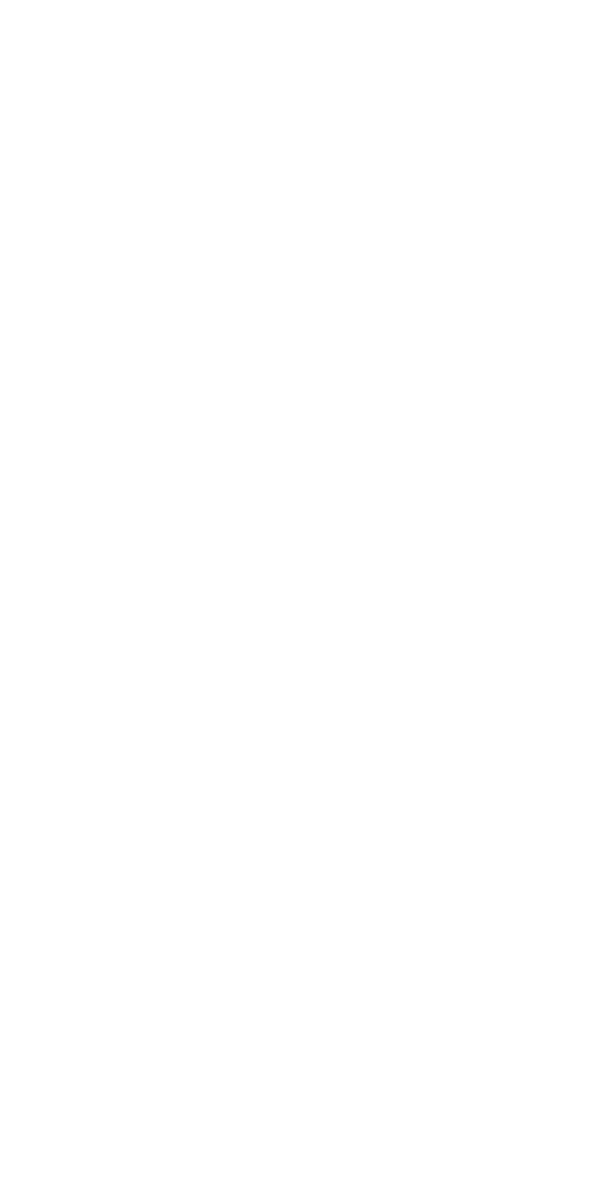

Strusnekliln


<IPython.core.display.Javascript object>


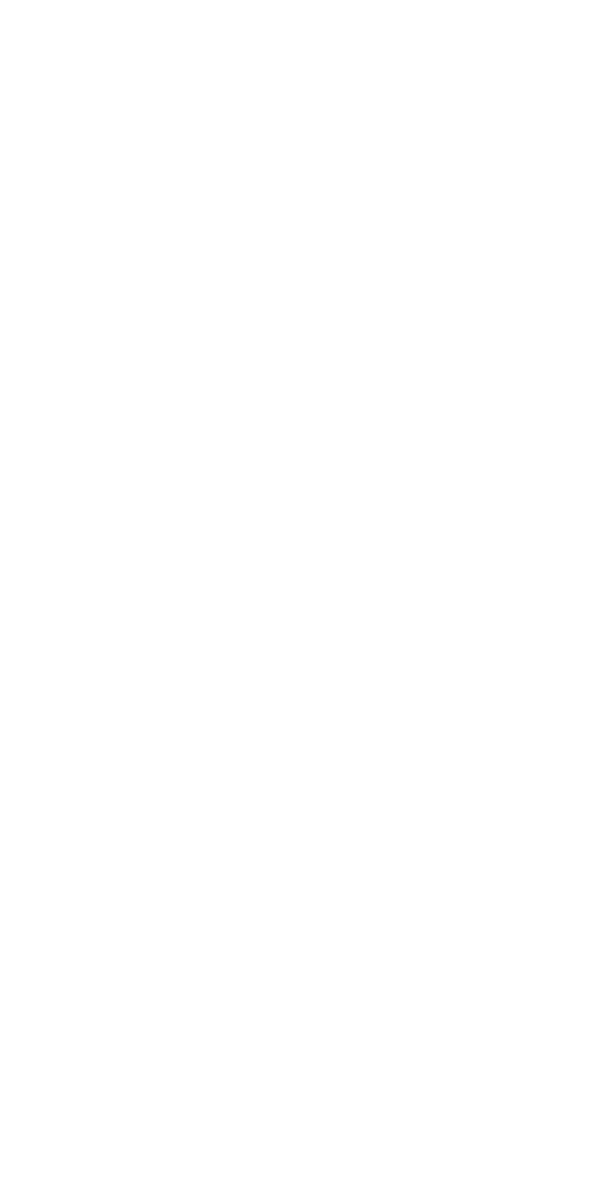

Woduree


<IPython.core.display.Javascript object>


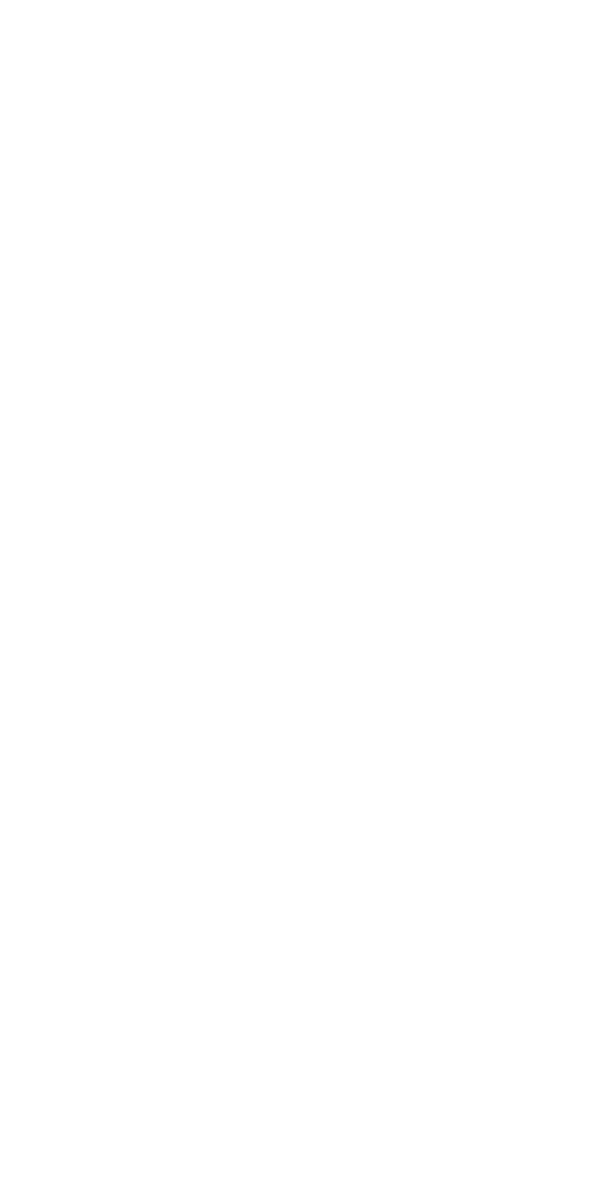

Baluedoog


<IPython.core.display.Javascript object>


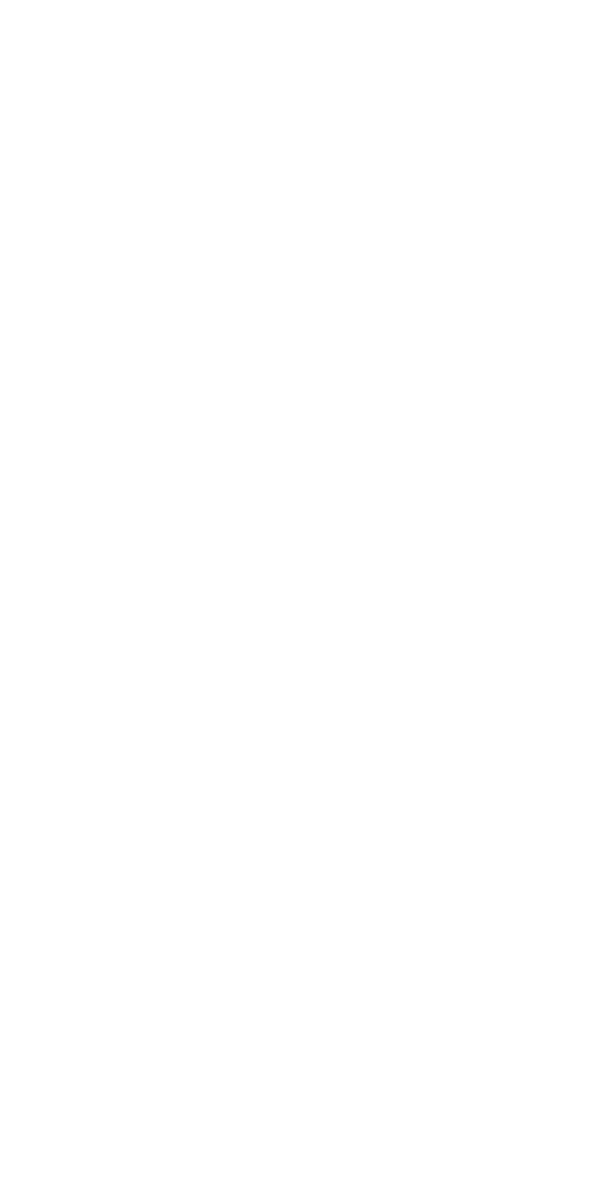

Batamom


<IPython.core.display.Javascript object>


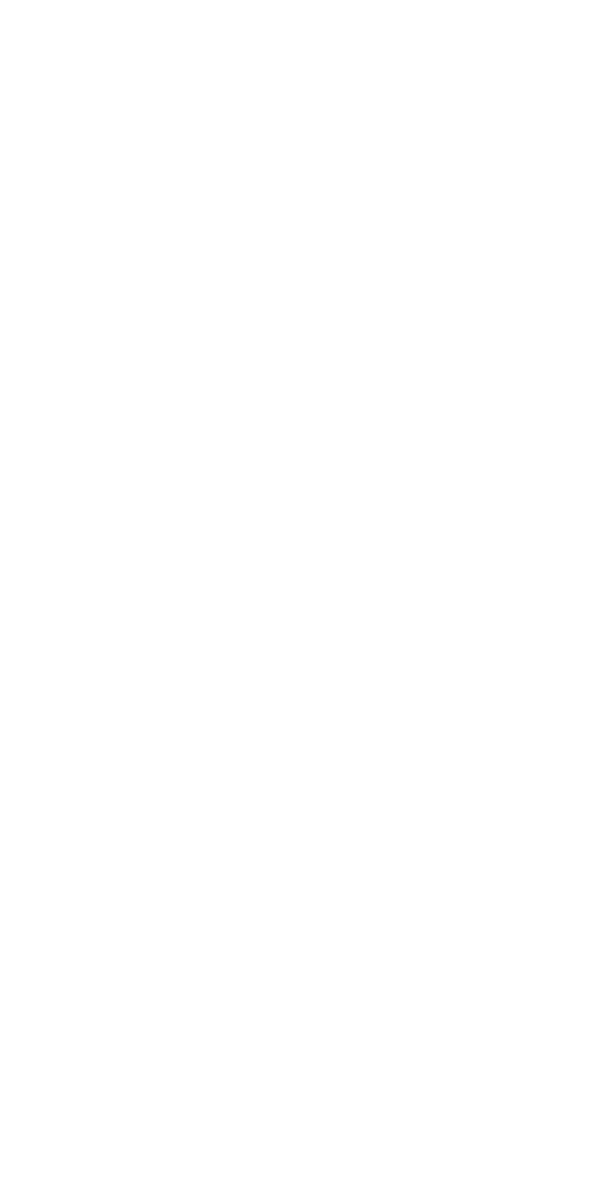

Quekemor


<IPython.core.display.Javascript object>


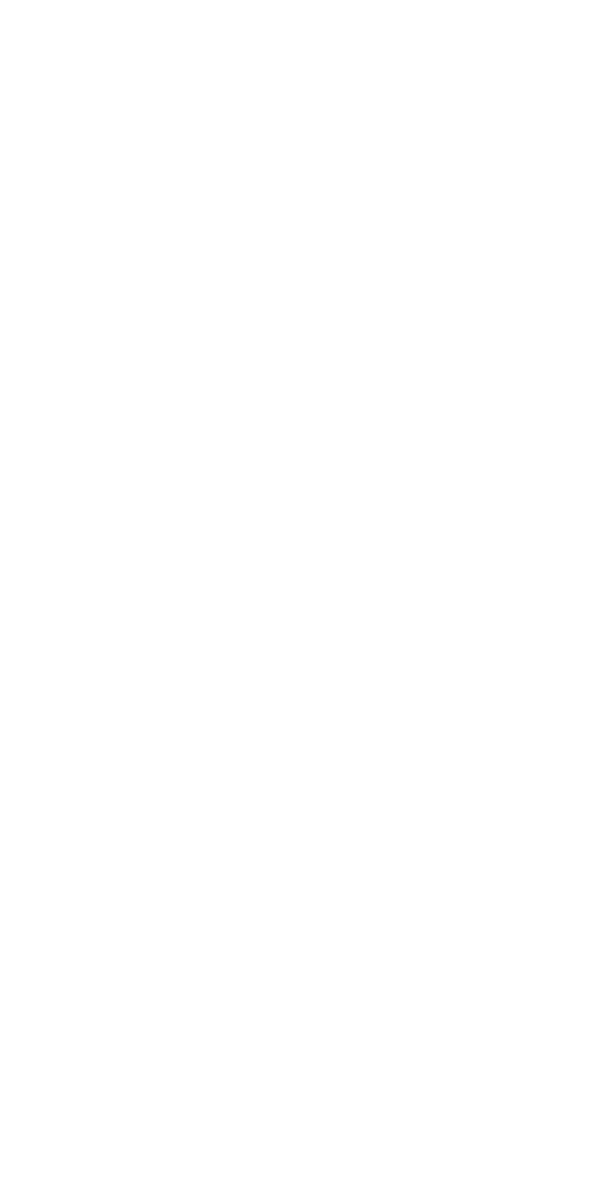

Necegeb


<IPython.core.display.Javascript object>


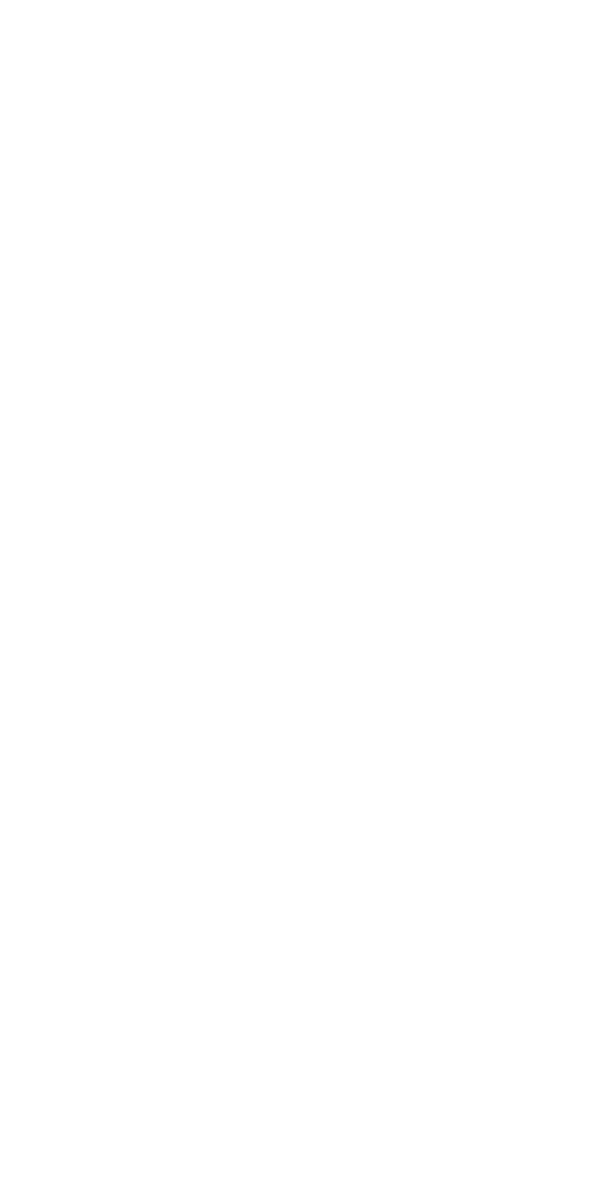

Scekoogar


<IPython.core.display.Javascript object>


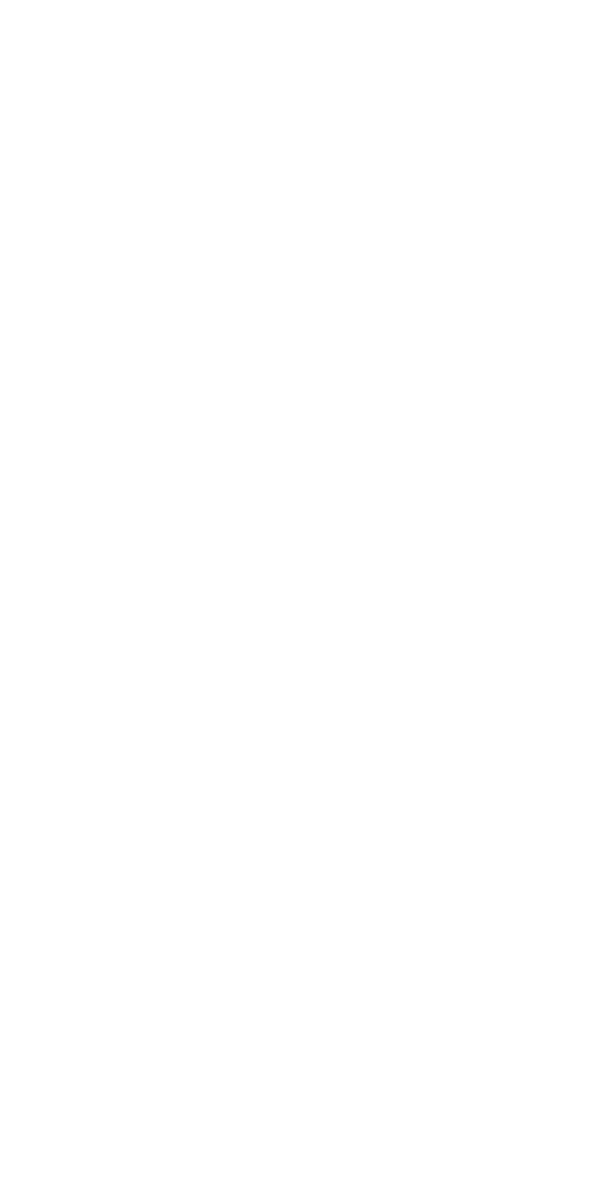

Itoyip


<IPython.core.display.Javascript object>


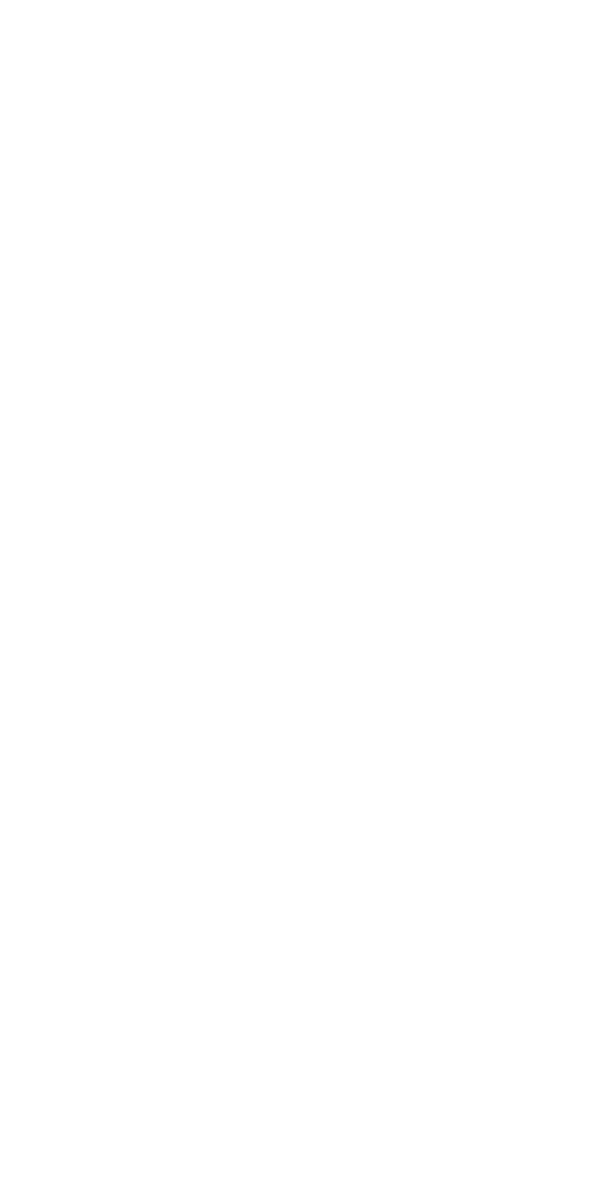

Jisena


<IPython.core.display.Javascript object>


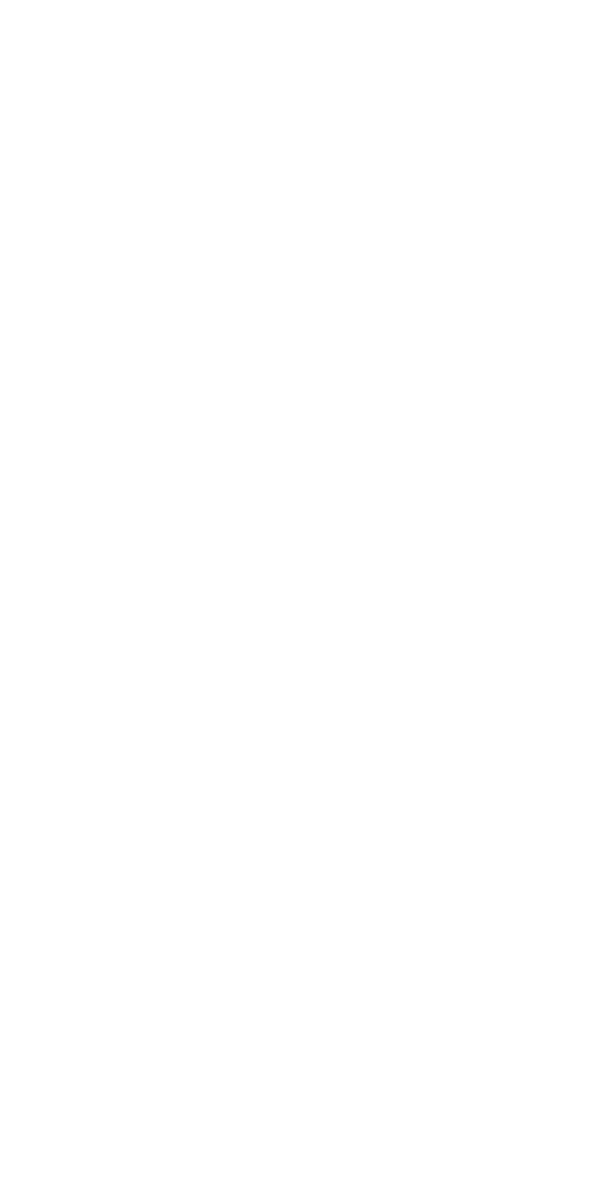

Edyeck


<IPython.core.display.Javascript object>


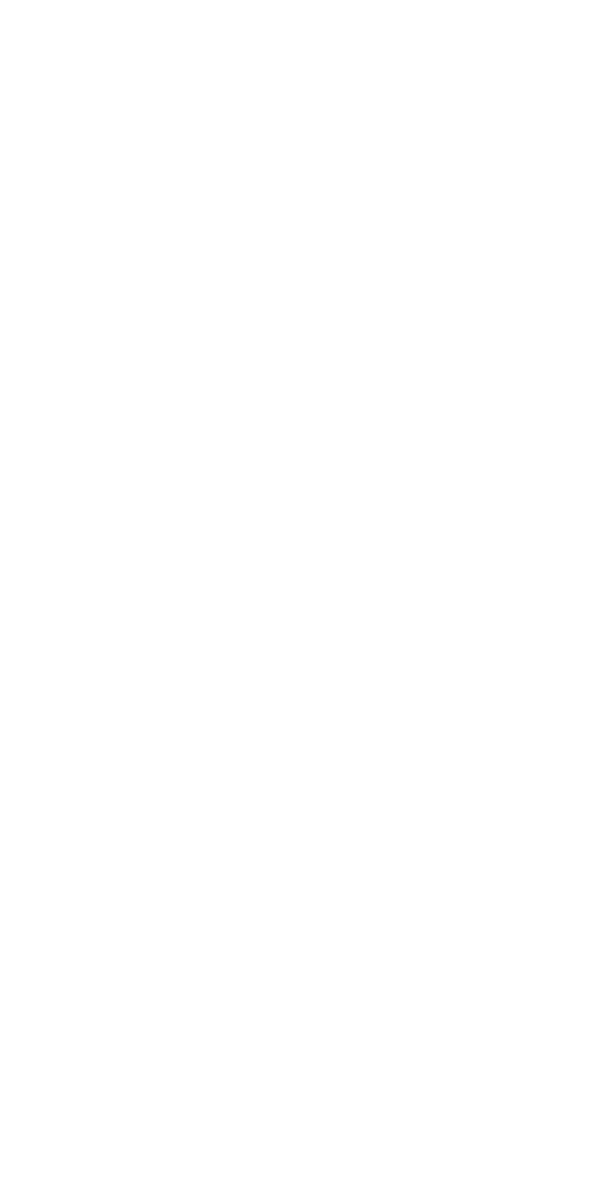

Naquodas


<IPython.core.display.Javascript object>


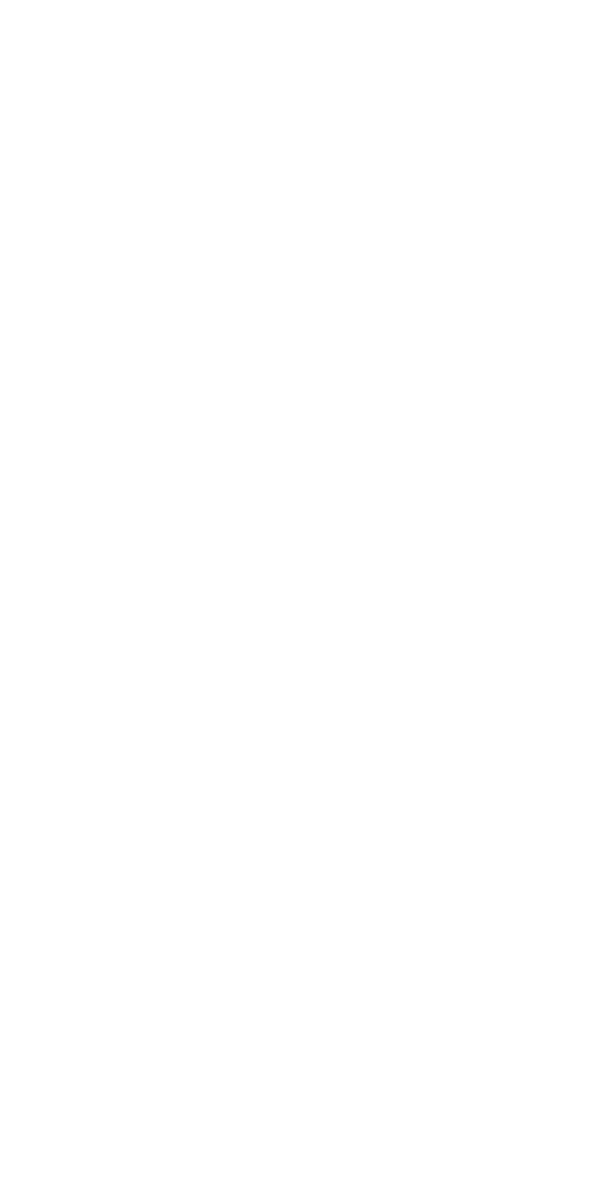

Salabo


<IPython.core.display.Javascript object>


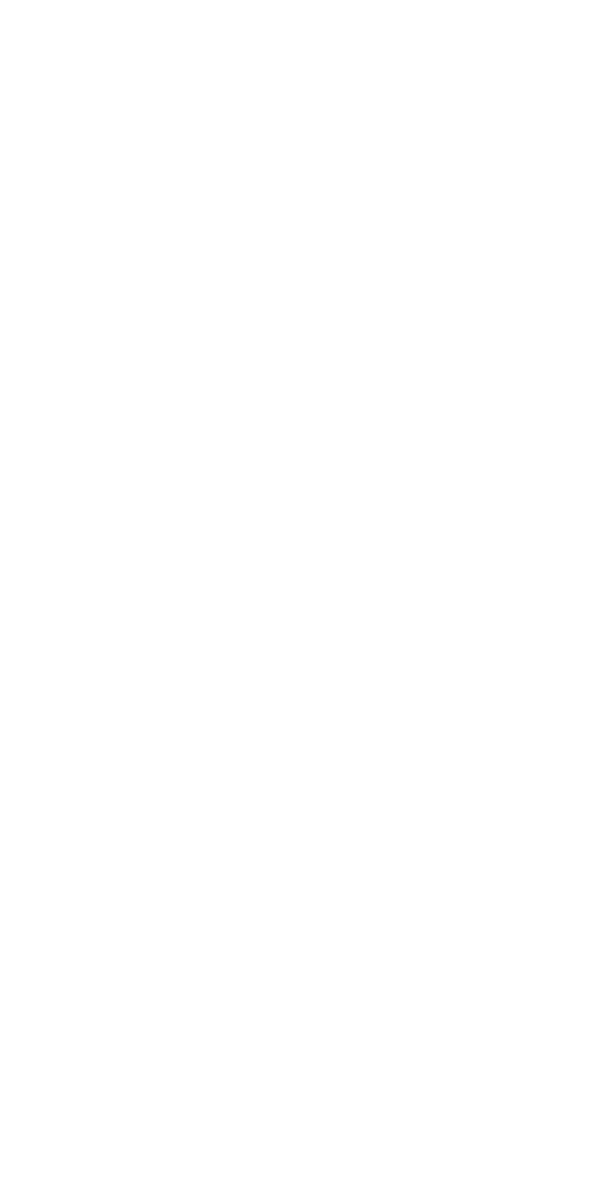

Soogamed


<IPython.core.display.Javascript object>


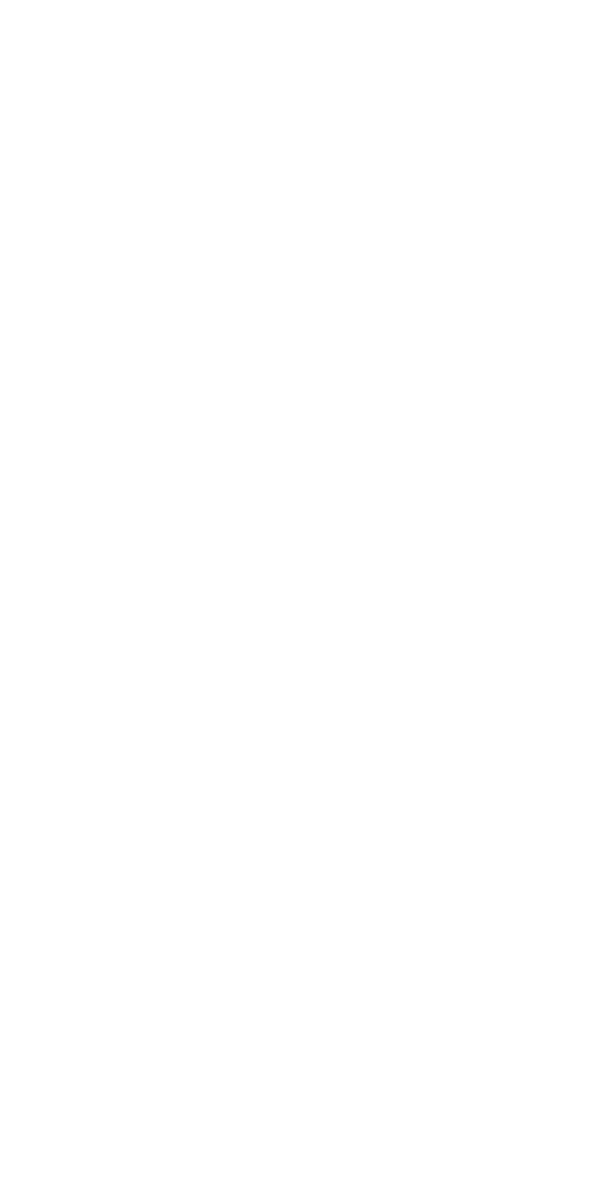

Kotookot


<IPython.core.display.Javascript object>


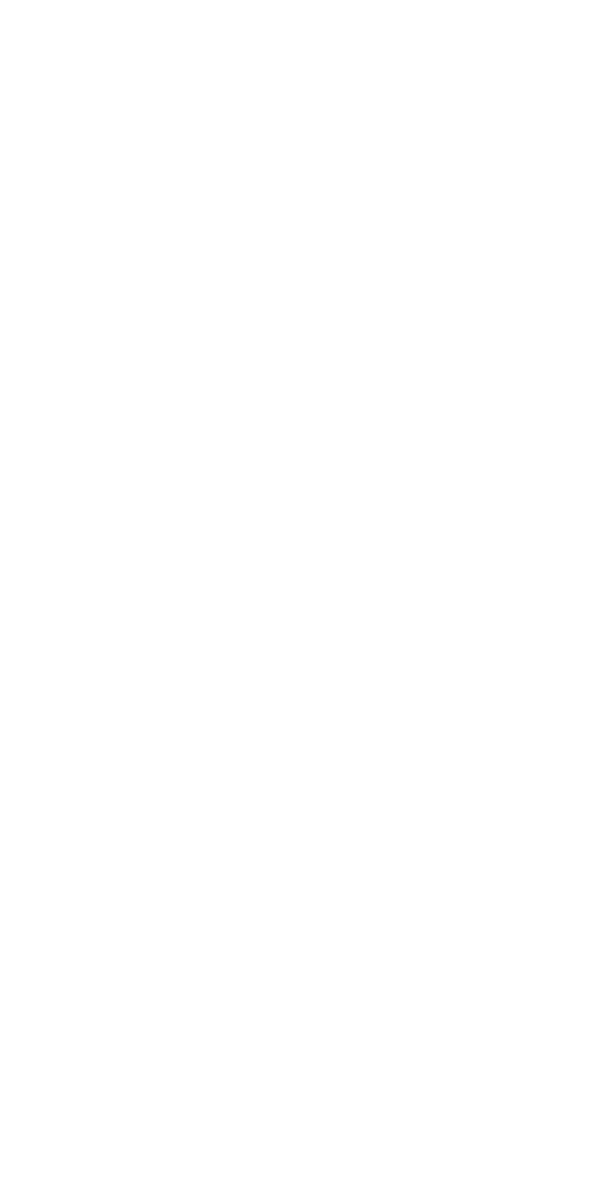

Niepuger


<IPython.core.display.Javascript object>


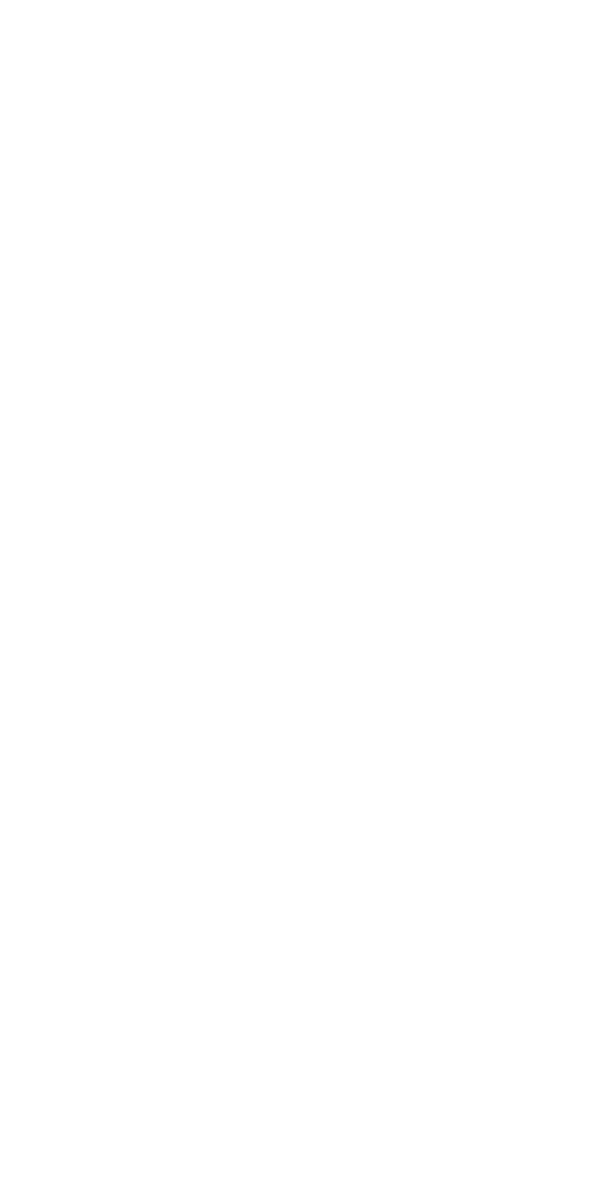

Cuesatree


<IPython.core.display.Javascript object>


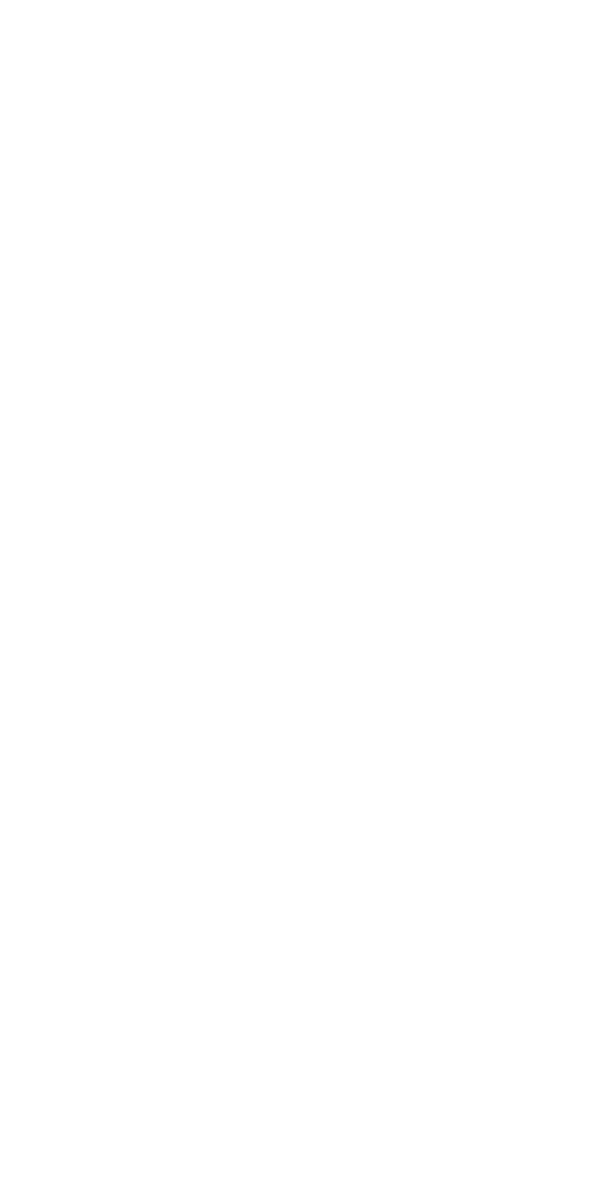

Sijohir


<IPython.core.display.Javascript object>


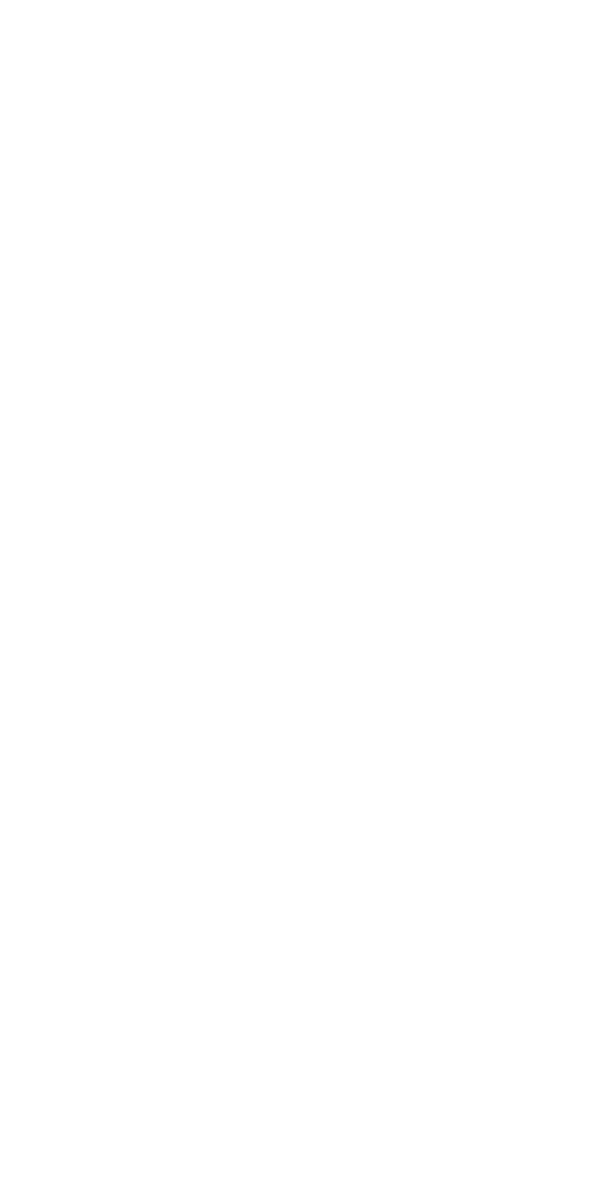

Dokali


<IPython.core.display.Javascript object>


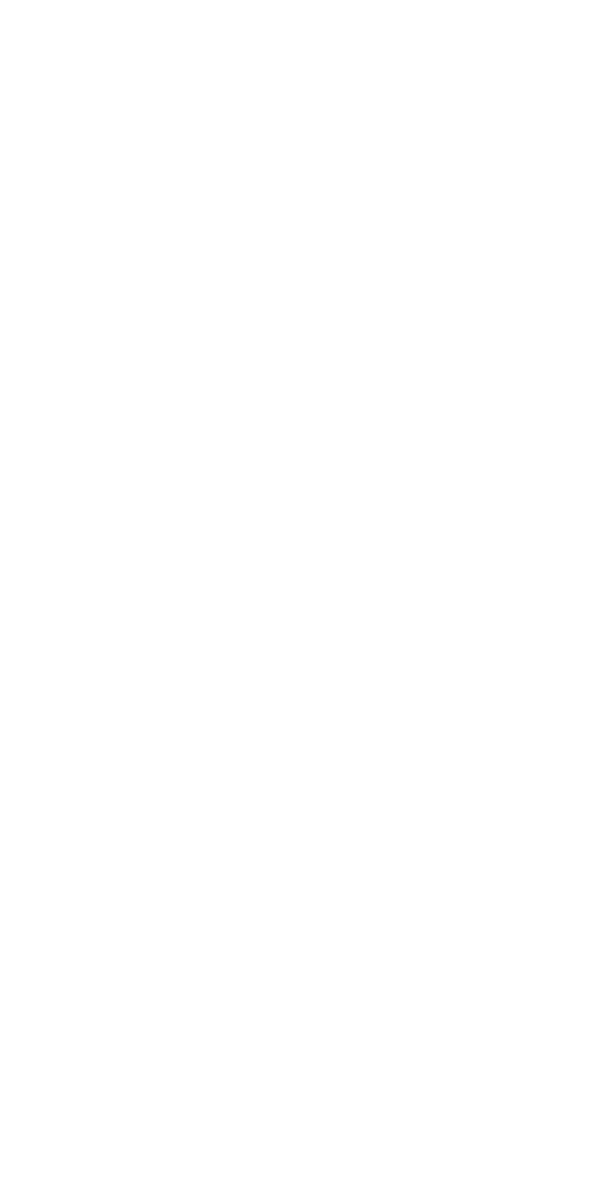

Gatuesam


<IPython.core.display.Javascript object>


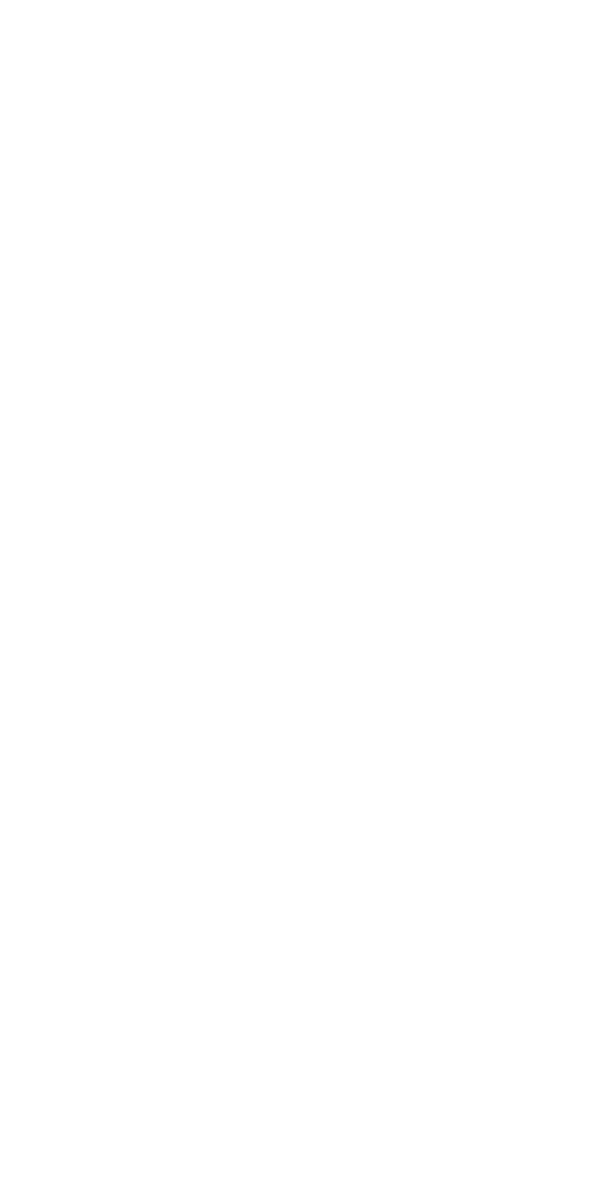

Rouresad


<IPython.core.display.Javascript object>


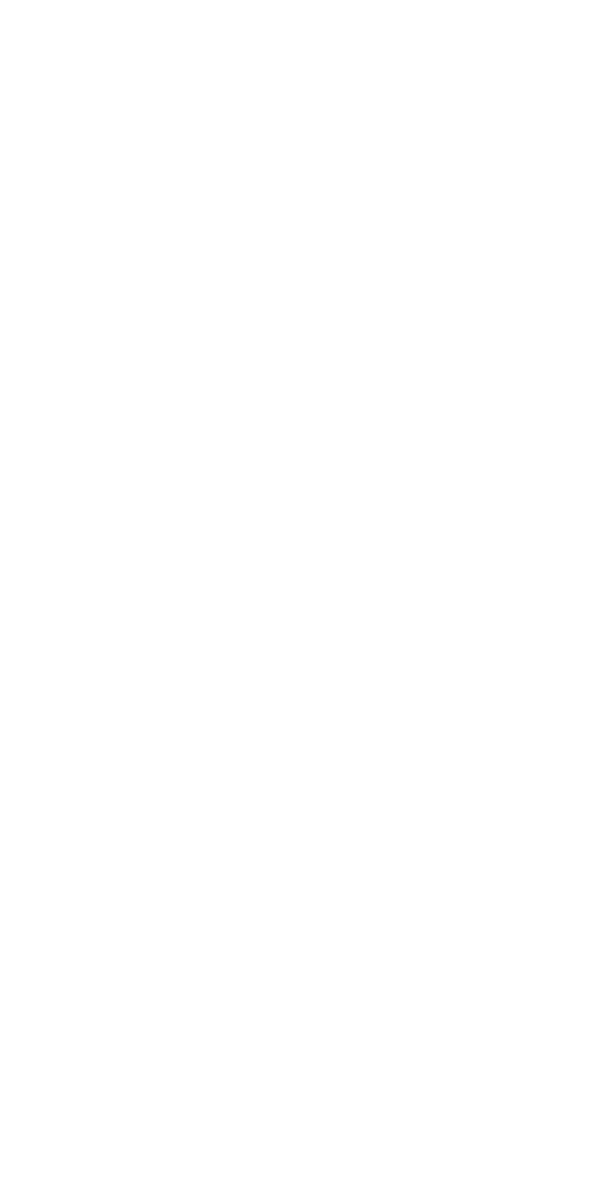

Berite


<IPython.core.display.Javascript object>


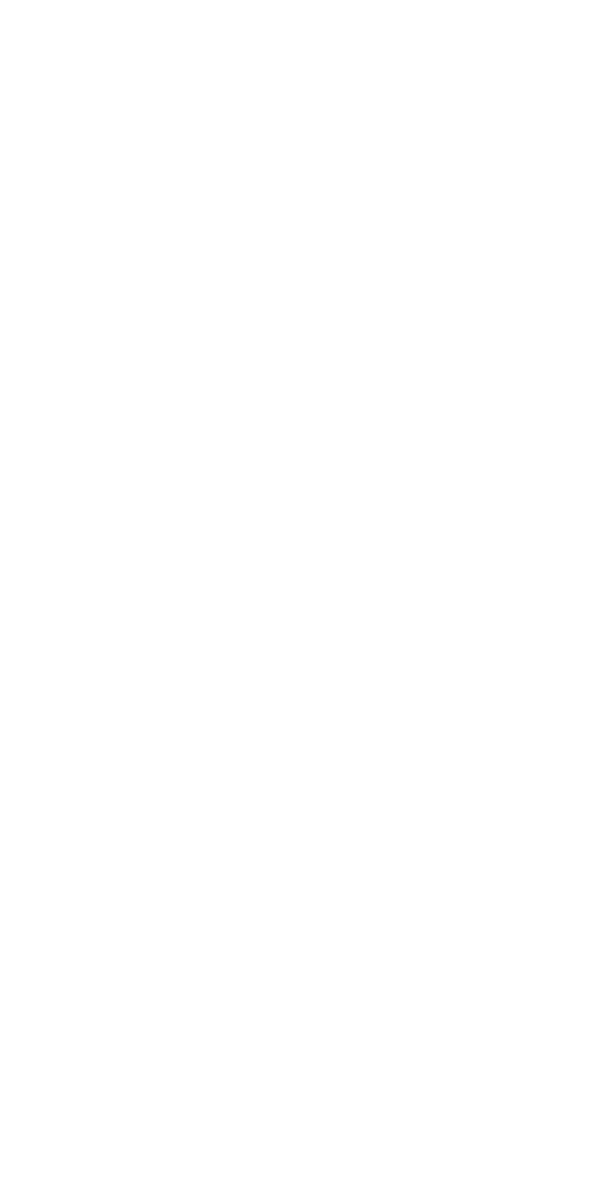

Hupinoo


<IPython.core.display.Javascript object>


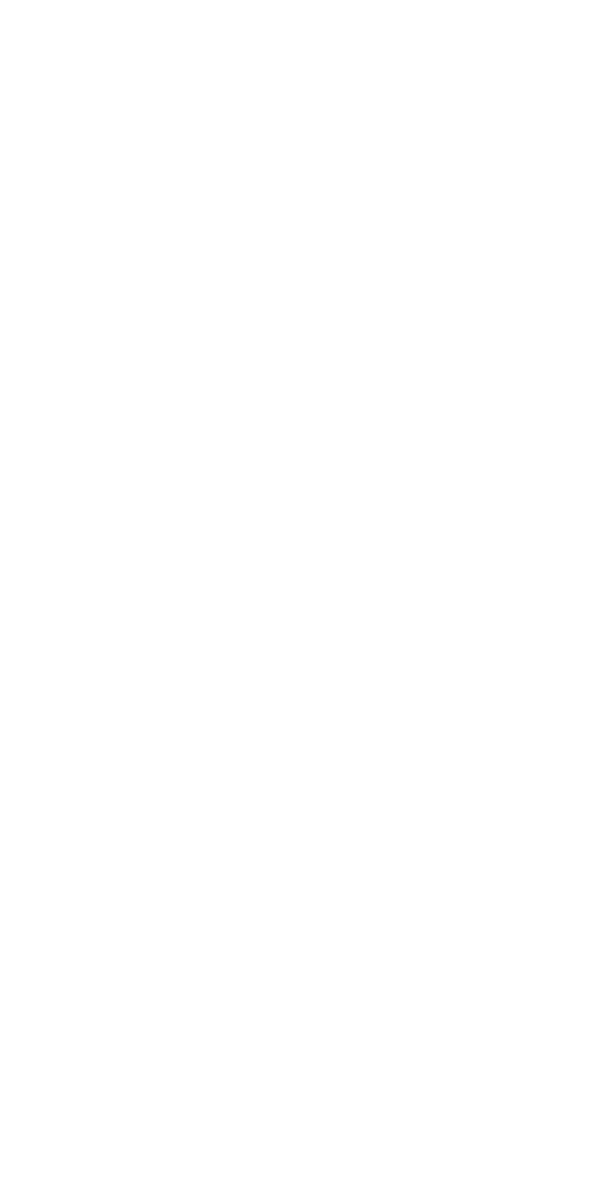

Bojiho


<IPython.core.display.Javascript object>


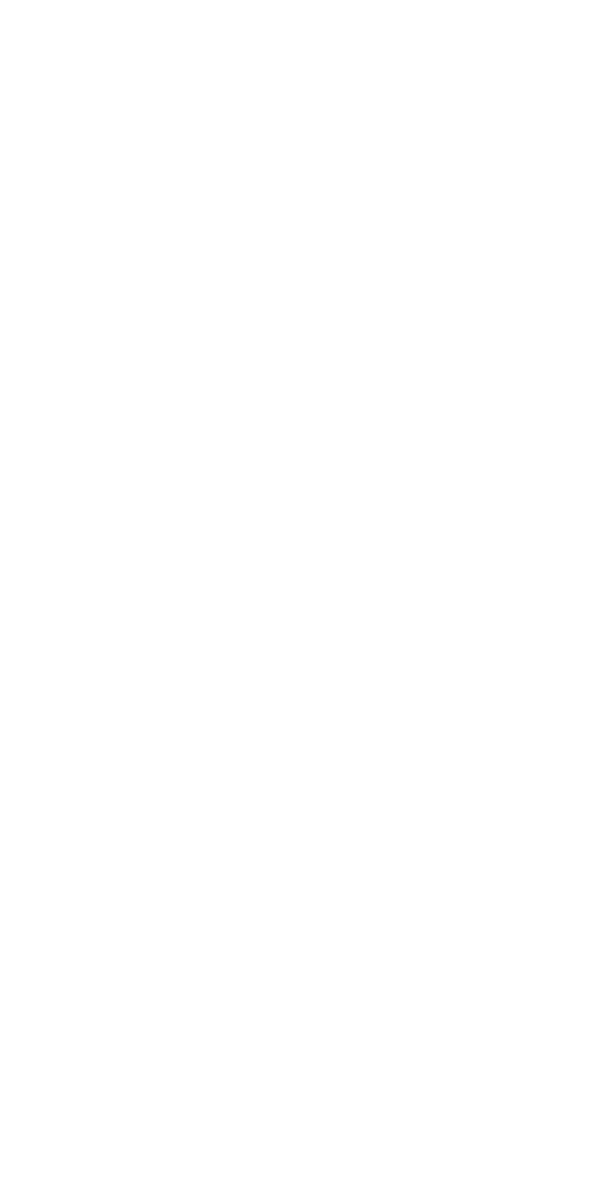

Gitackas


<IPython.core.display.Javascript object>


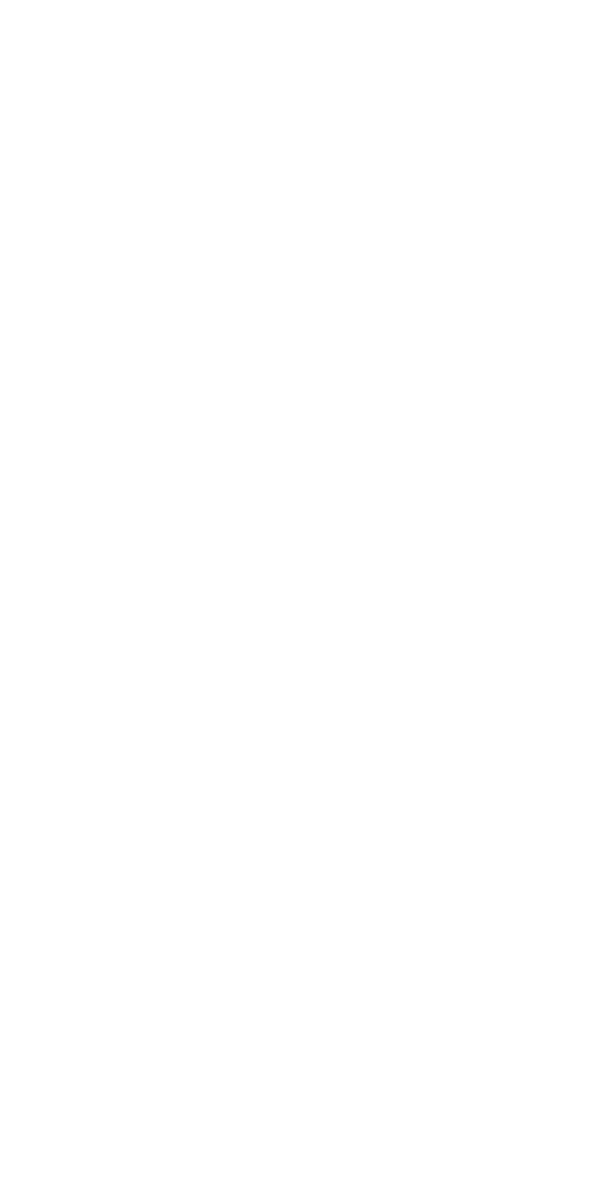

Kaluqua


<IPython.core.display.Javascript object>


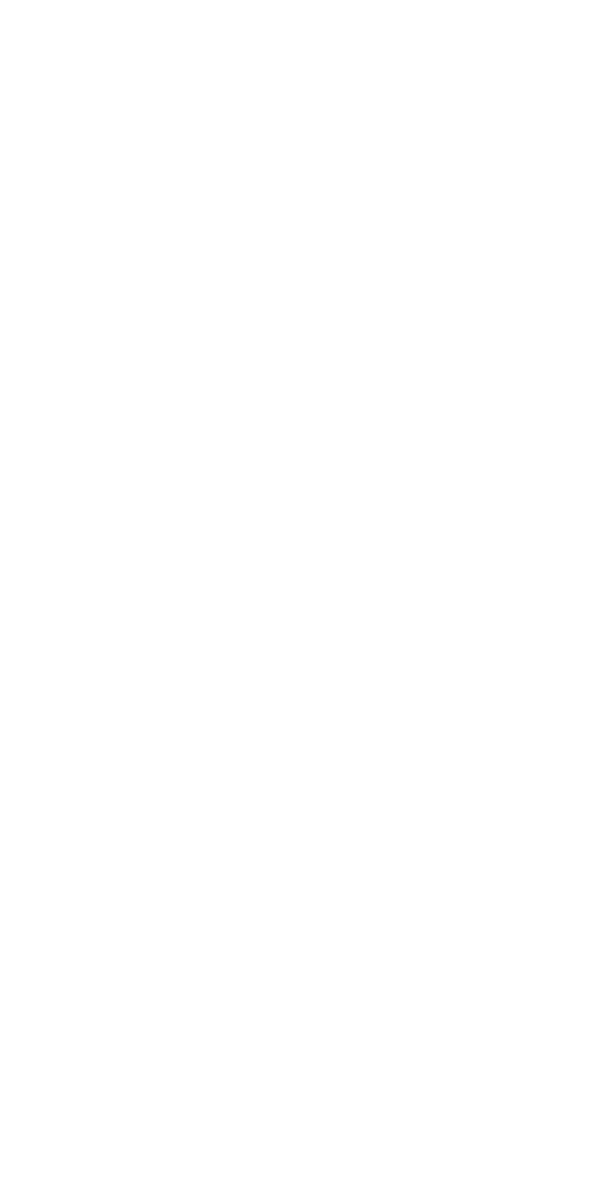

Rofuzor


<IPython.core.display.Javascript object>


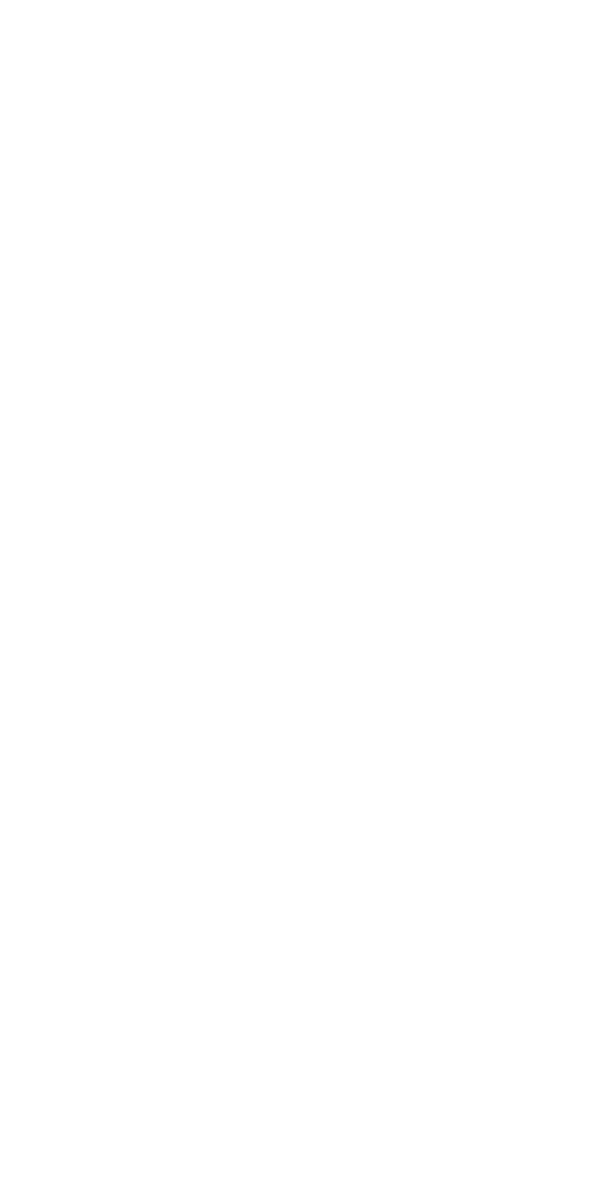

Haboutoth


<IPython.core.display.Javascript object>


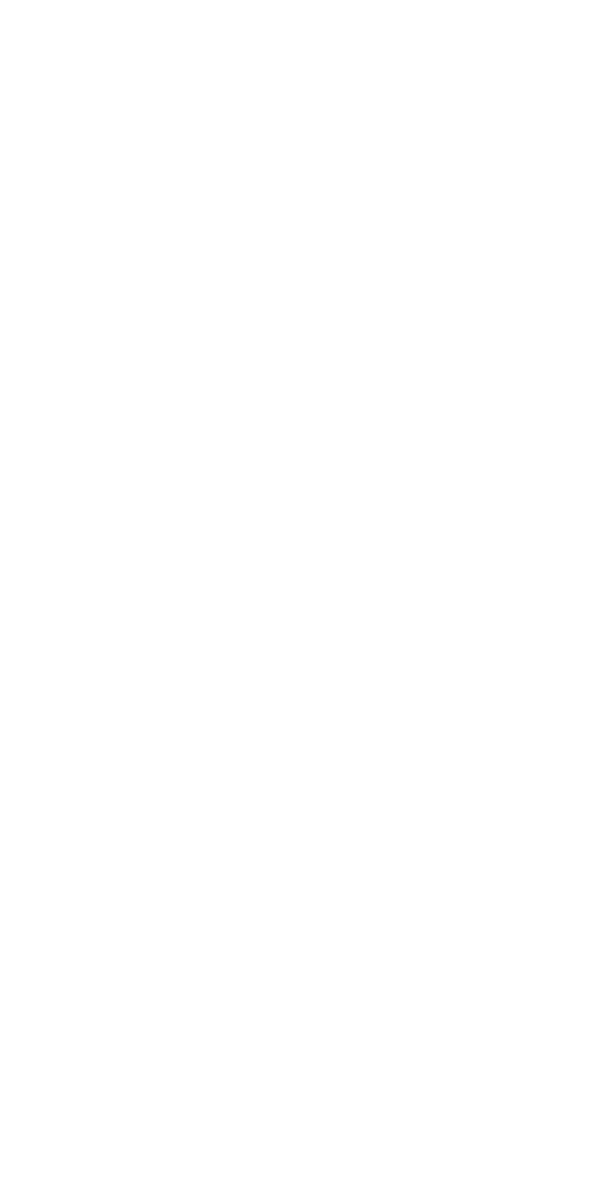

Kosoukob


<IPython.core.display.Javascript object>


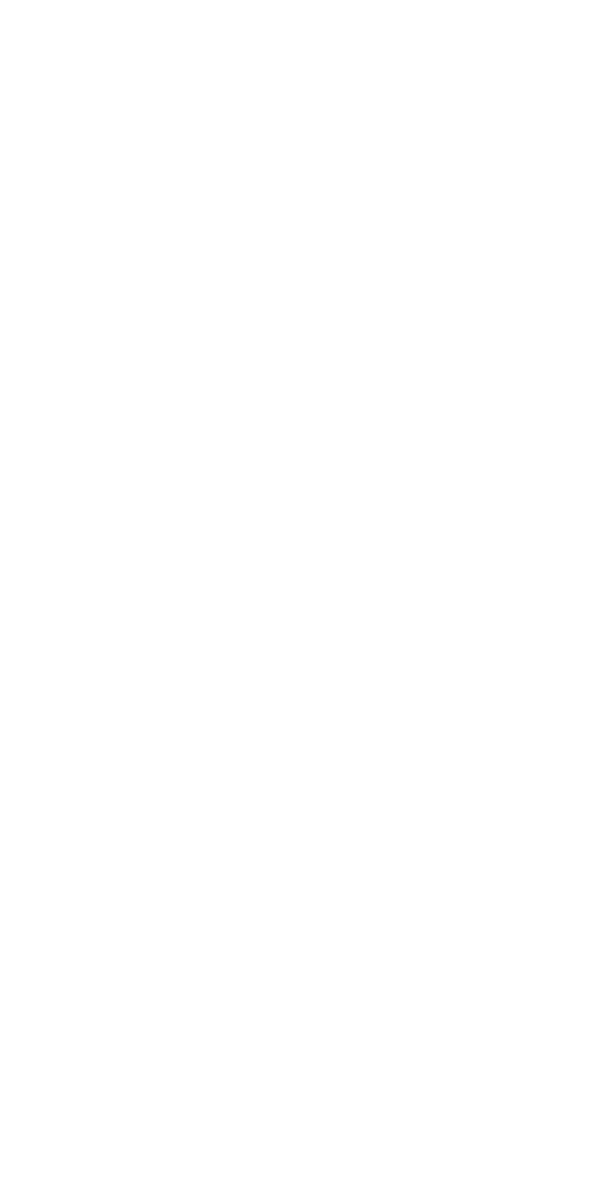

Quapuefi


<IPython.core.display.Javascript object>


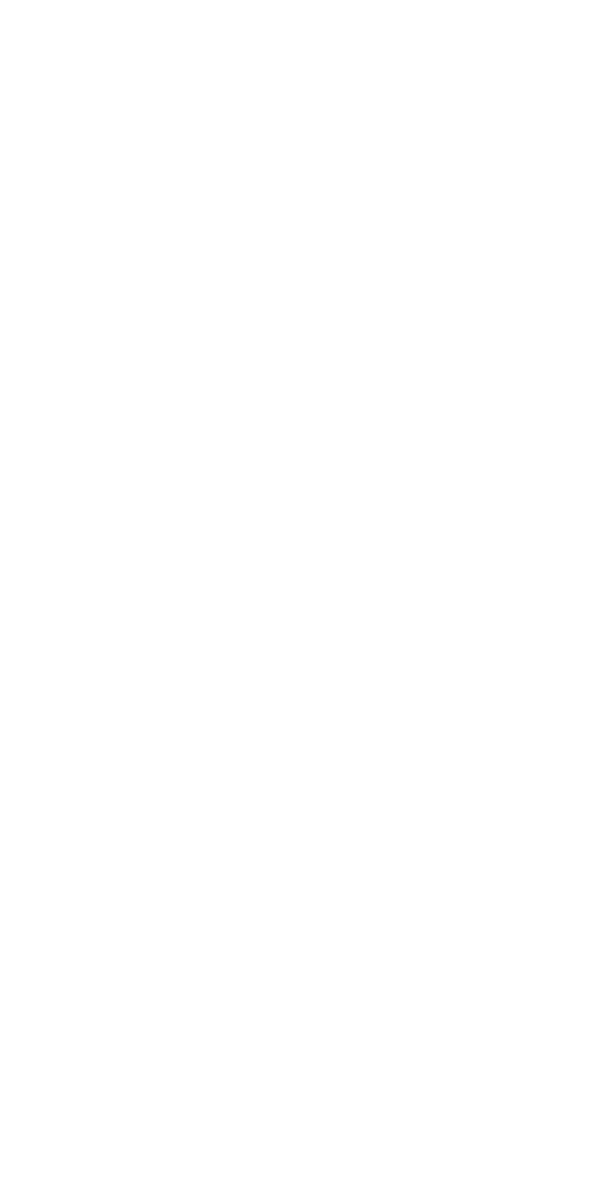

Onkumam


<IPython.core.display.Javascript object>


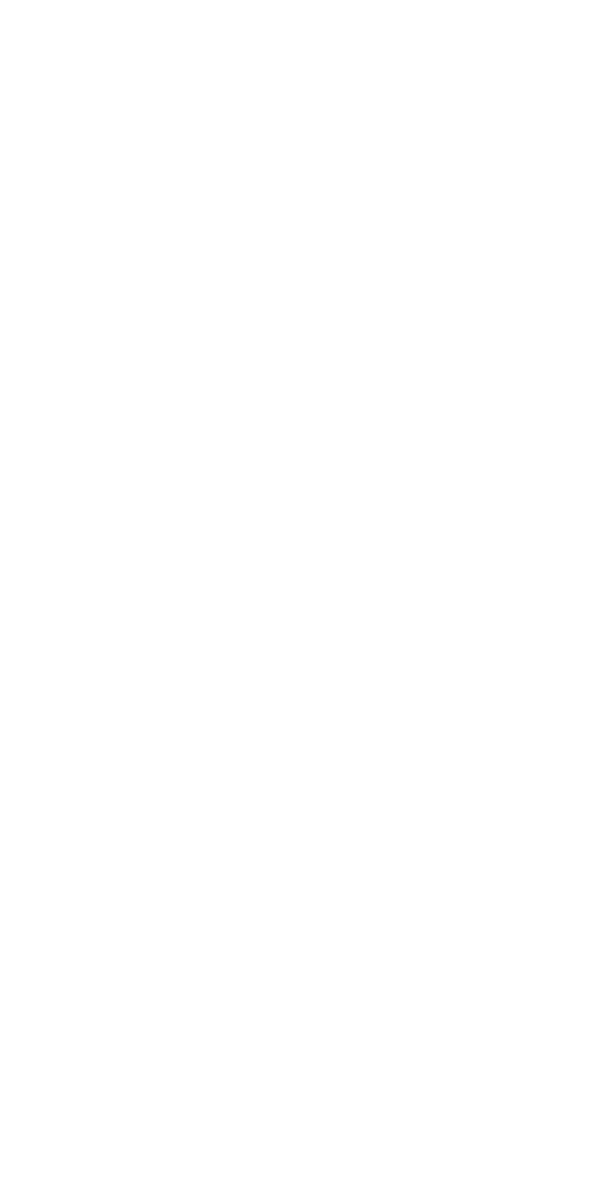

Olulob


<IPython.core.display.Javascript object>


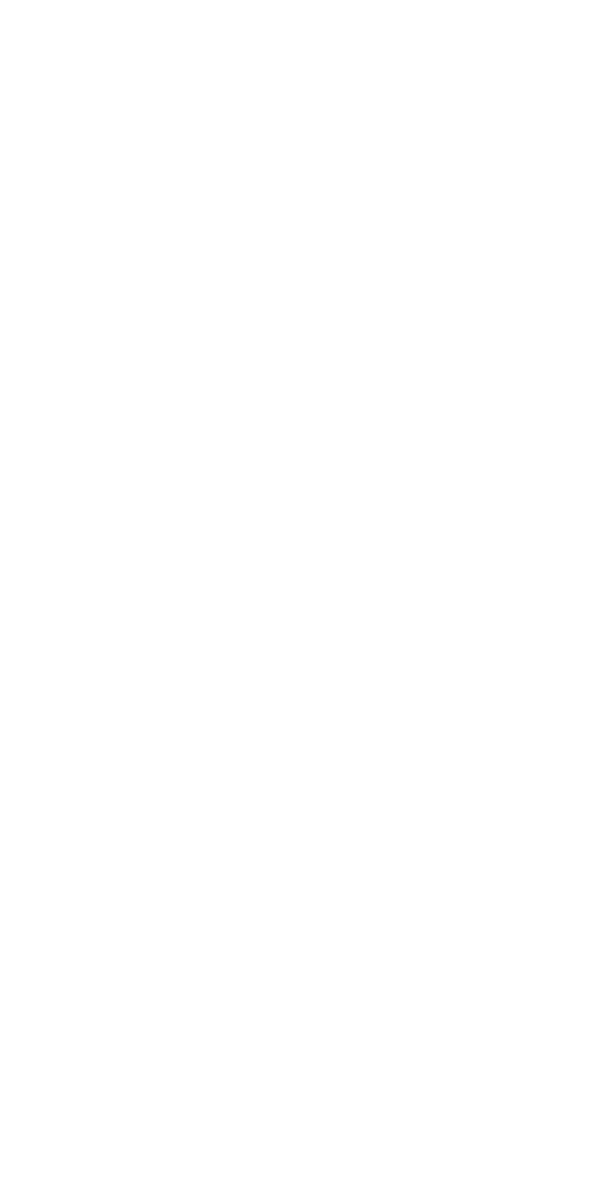

Fakeyak


<IPython.core.display.Javascript object>


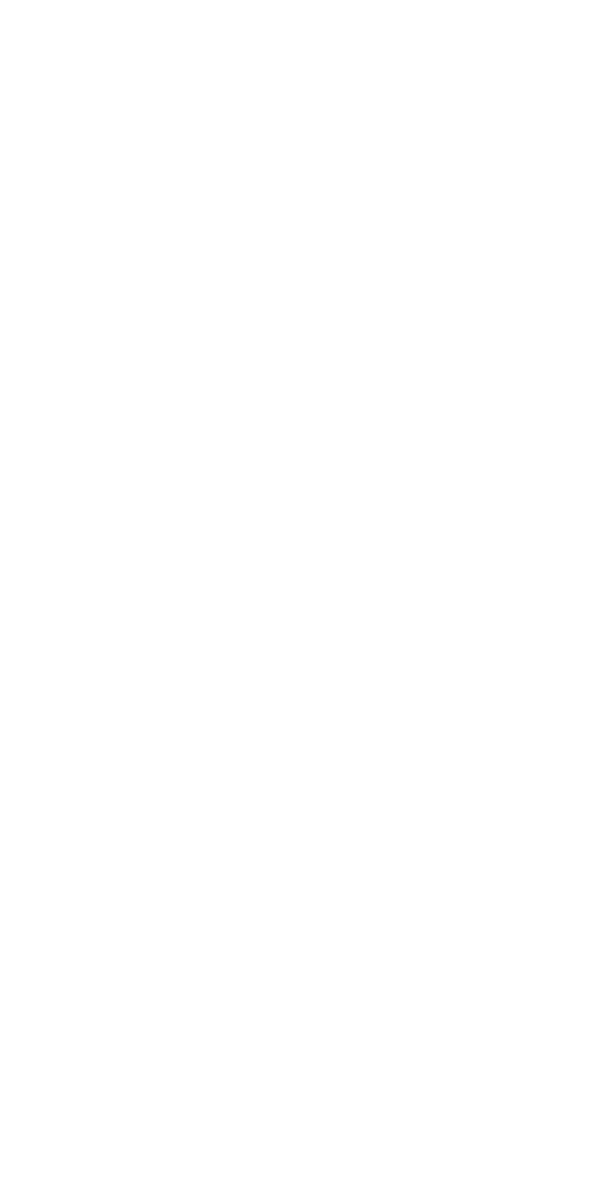

Mibago


<IPython.core.display.Javascript object>


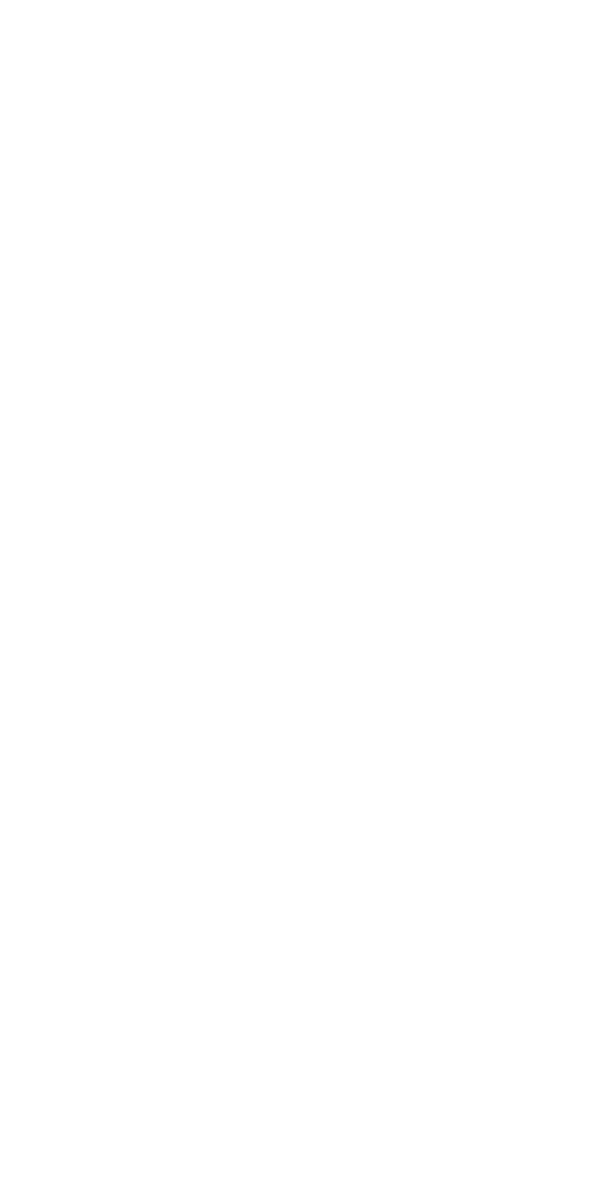

Pogheken


<IPython.core.display.Javascript object>


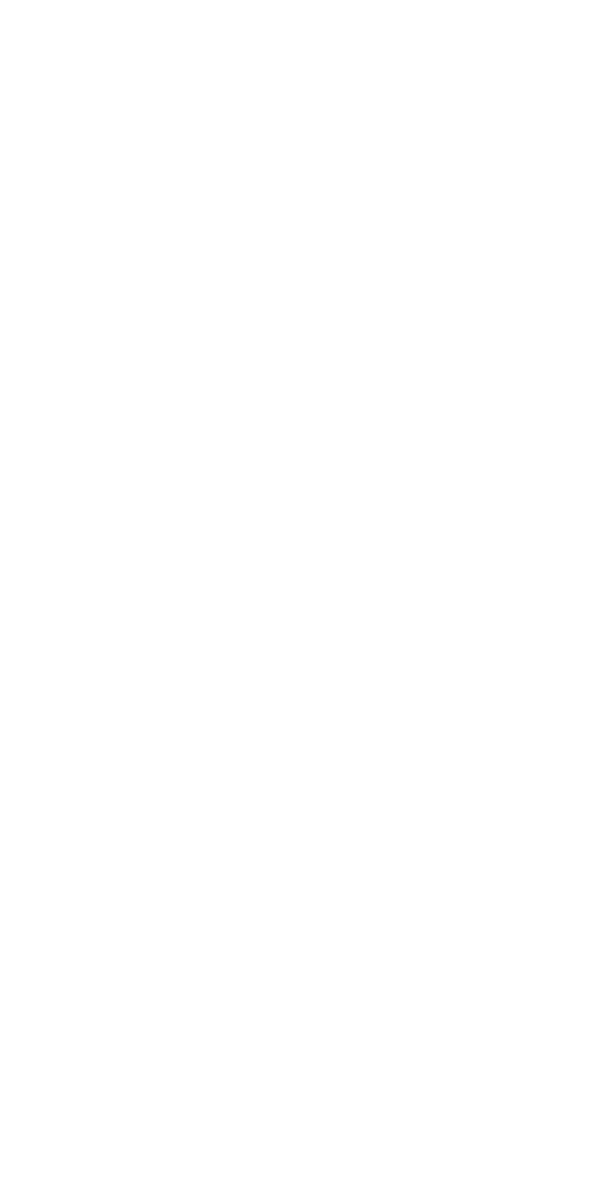

Nacufor


<IPython.core.display.Javascript object>


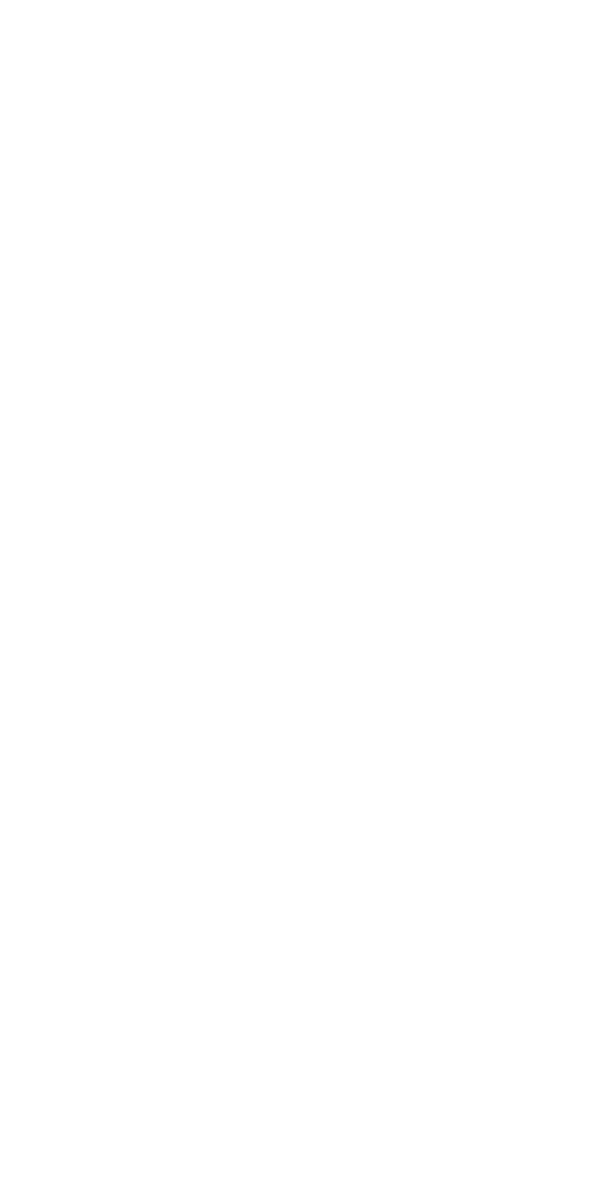

Ornakash


<IPython.core.display.Javascript object>


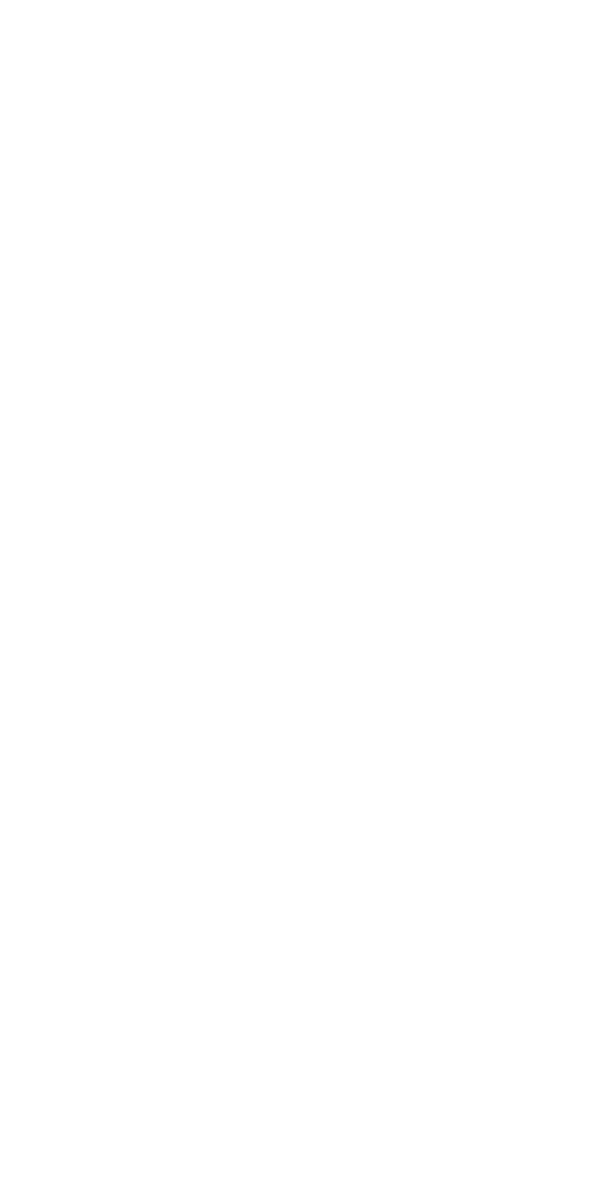

Tijupro


<IPython.core.display.Javascript object>


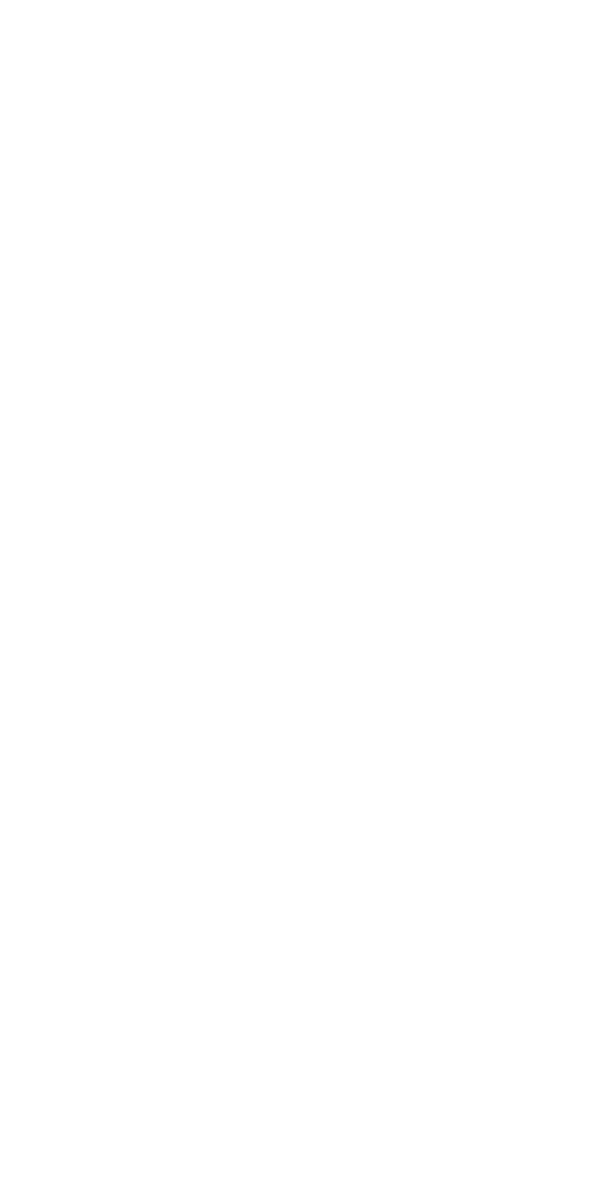

Quotooyuk


<IPython.core.display.Javascript object>


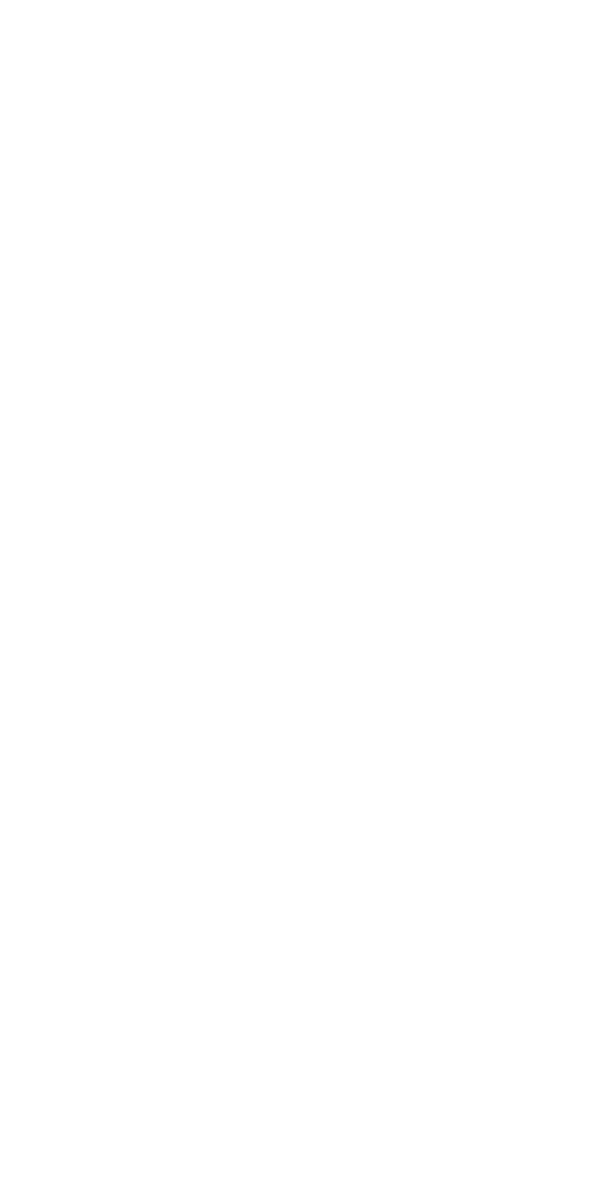

Okibech


<IPython.core.display.Javascript object>


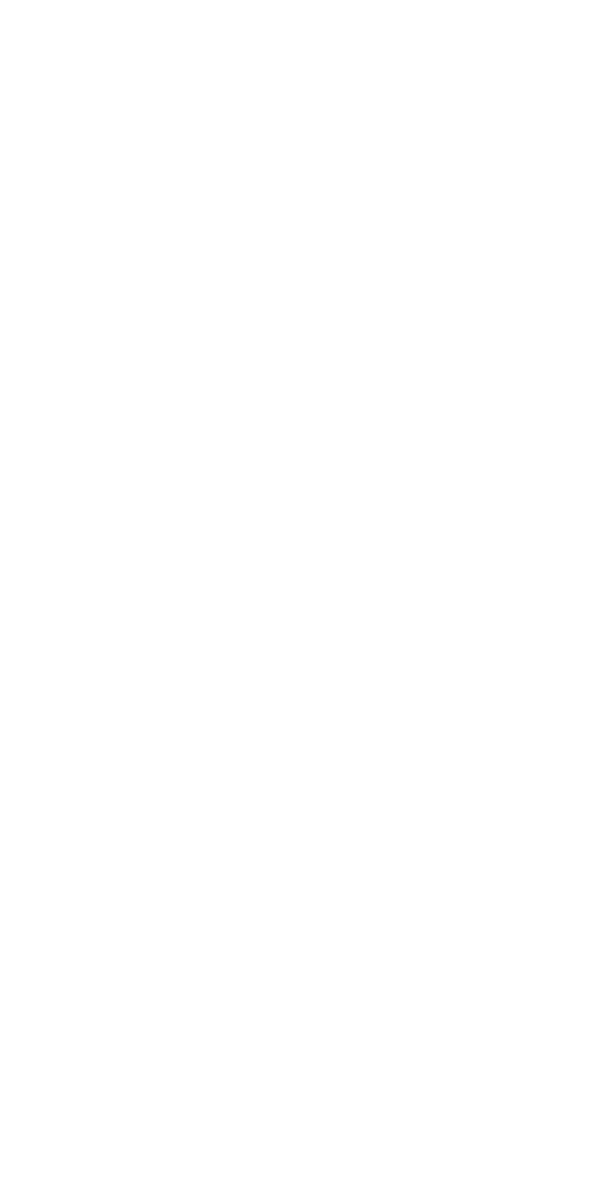

Sleyolof


<IPython.core.display.Javascript object>


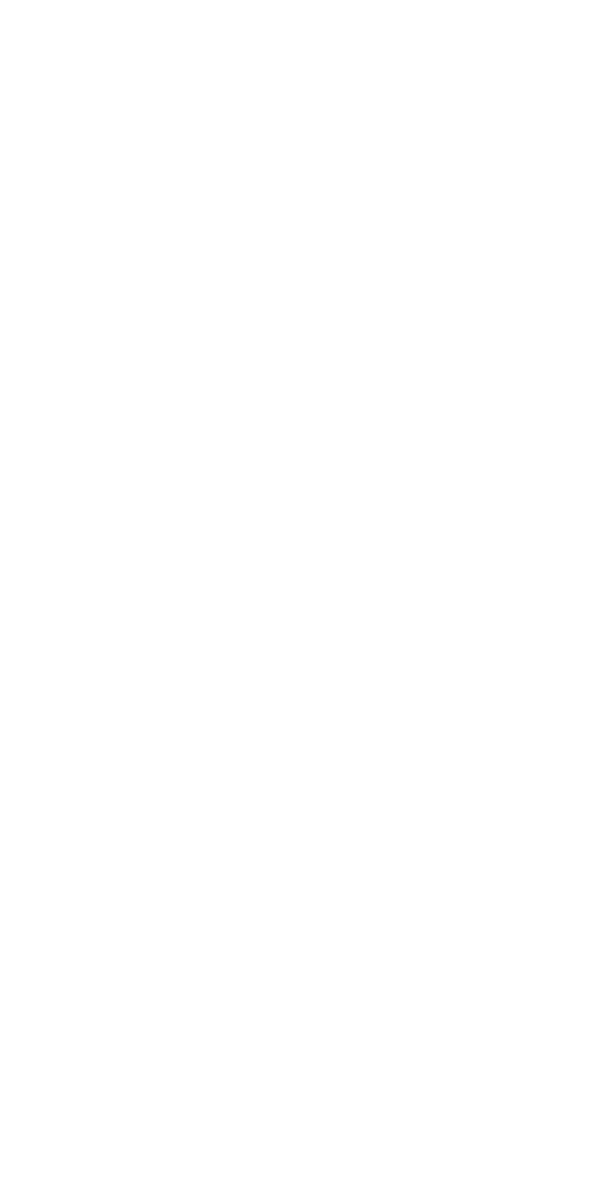

Mudroren


<IPython.core.display.Javascript object>


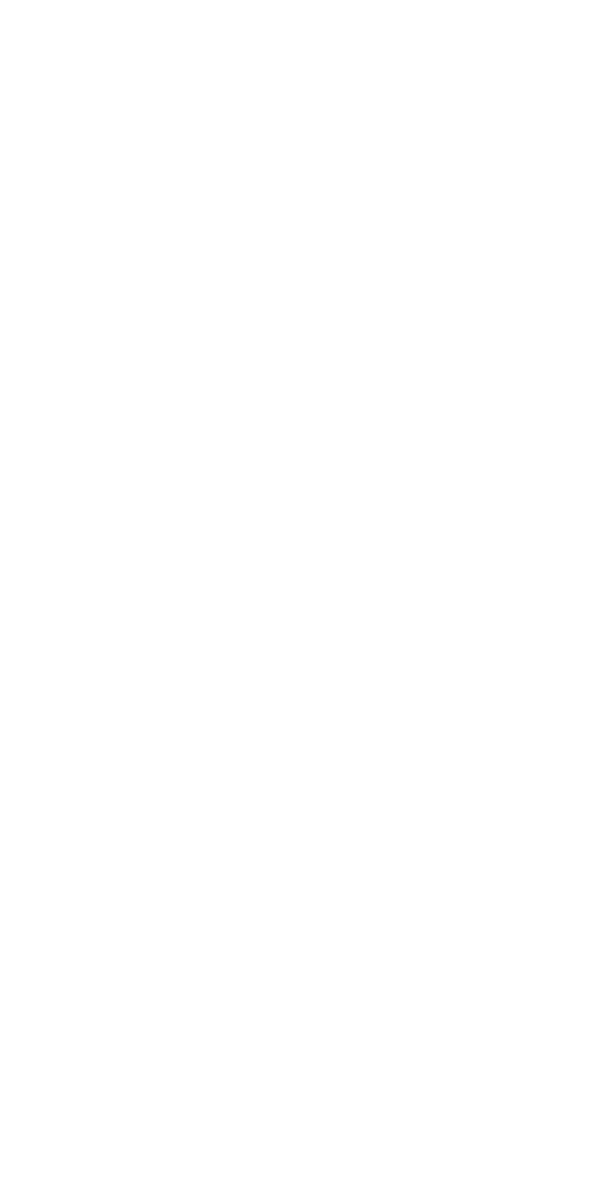

Dasafach


<IPython.core.display.Javascript object>


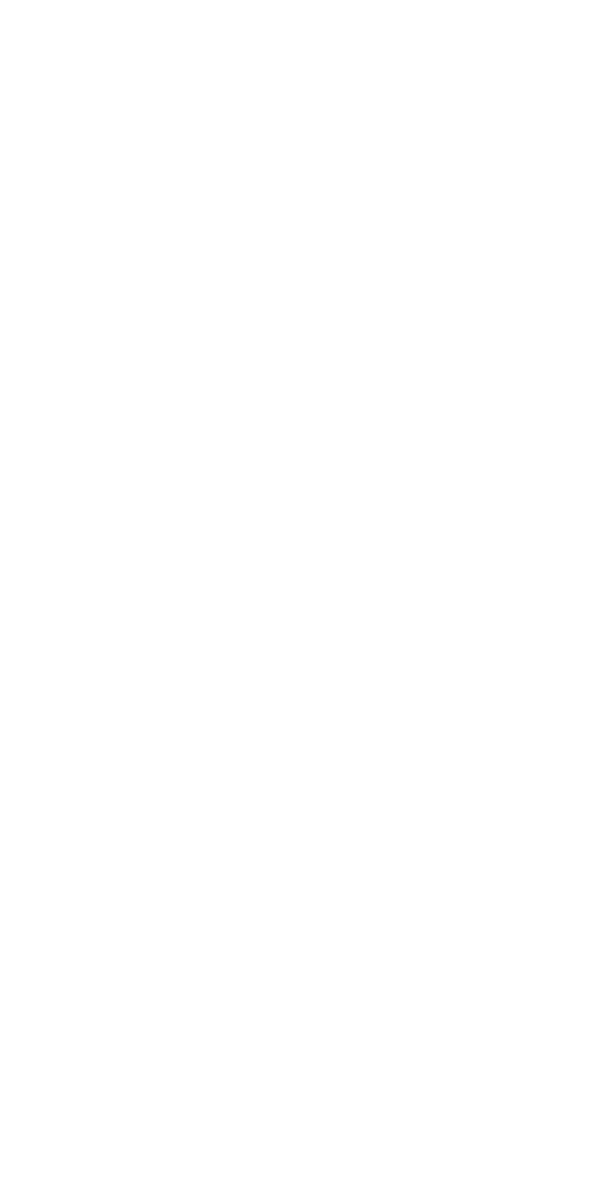

Akcigur


<IPython.core.display.Javascript object>


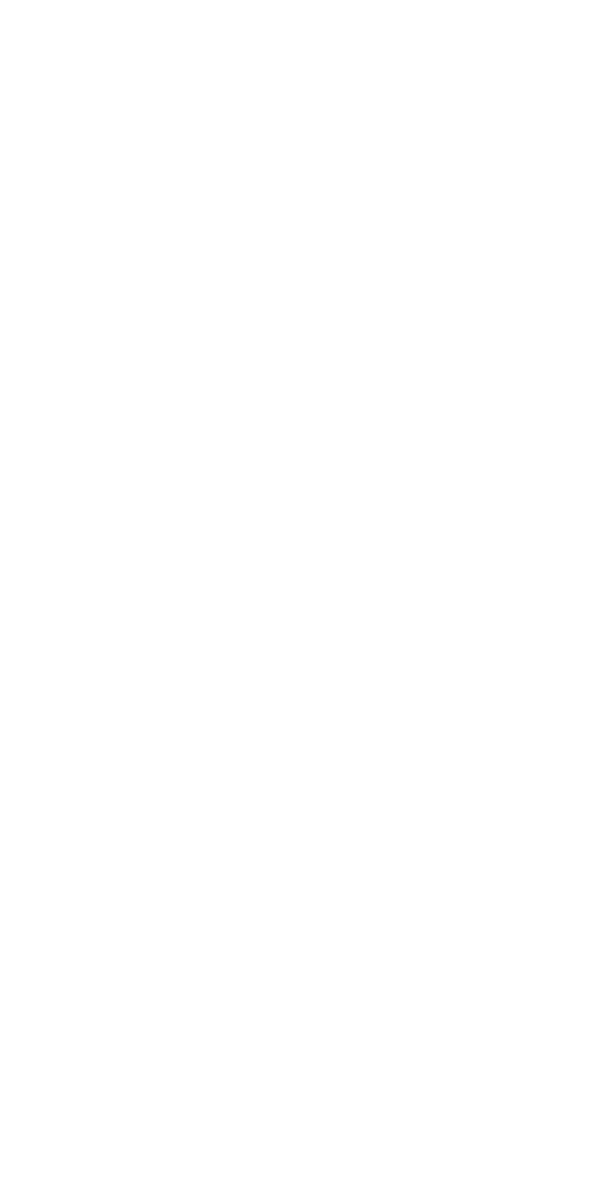

Shibrooflal


<IPython.core.display.Javascript object>


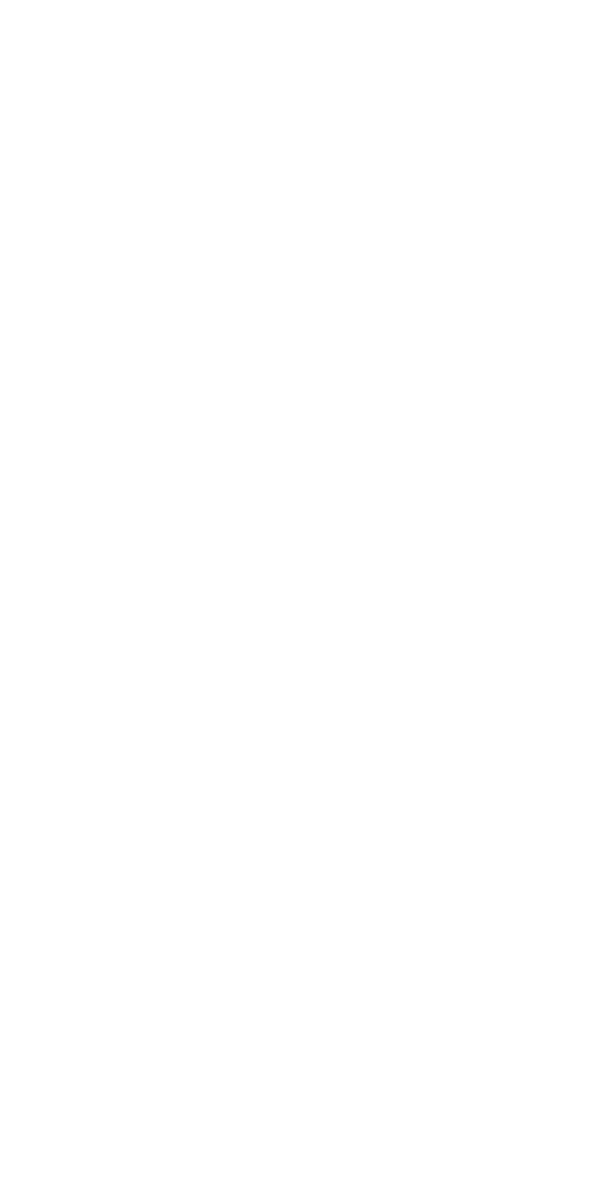

Onoolif


<IPython.core.display.Javascript object>


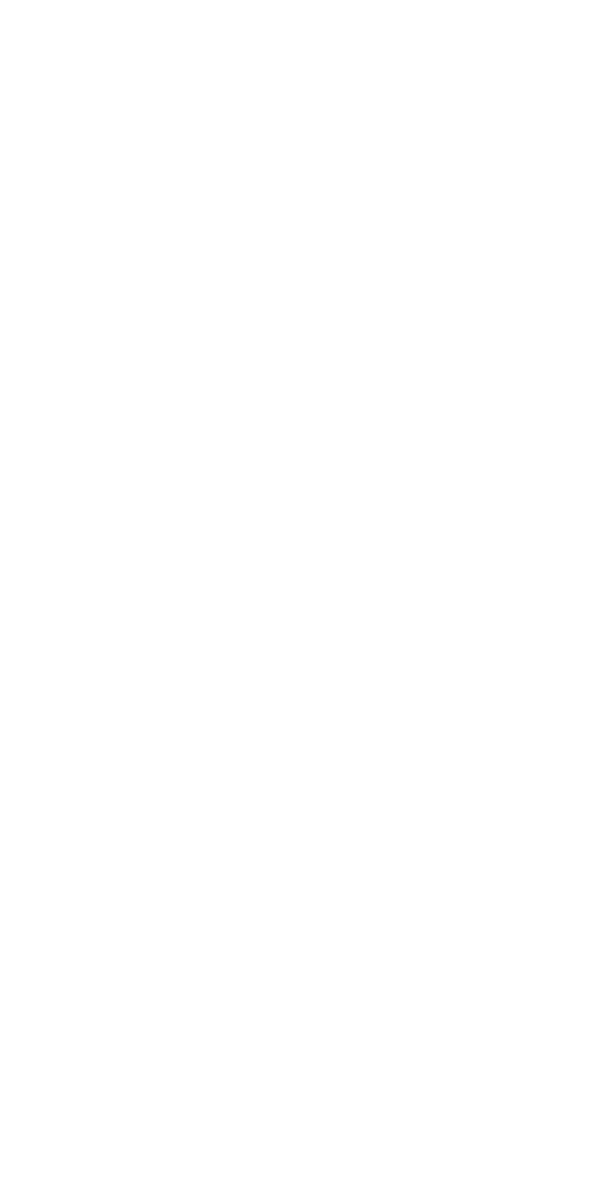

Honejo


<IPython.core.display.Javascript object>


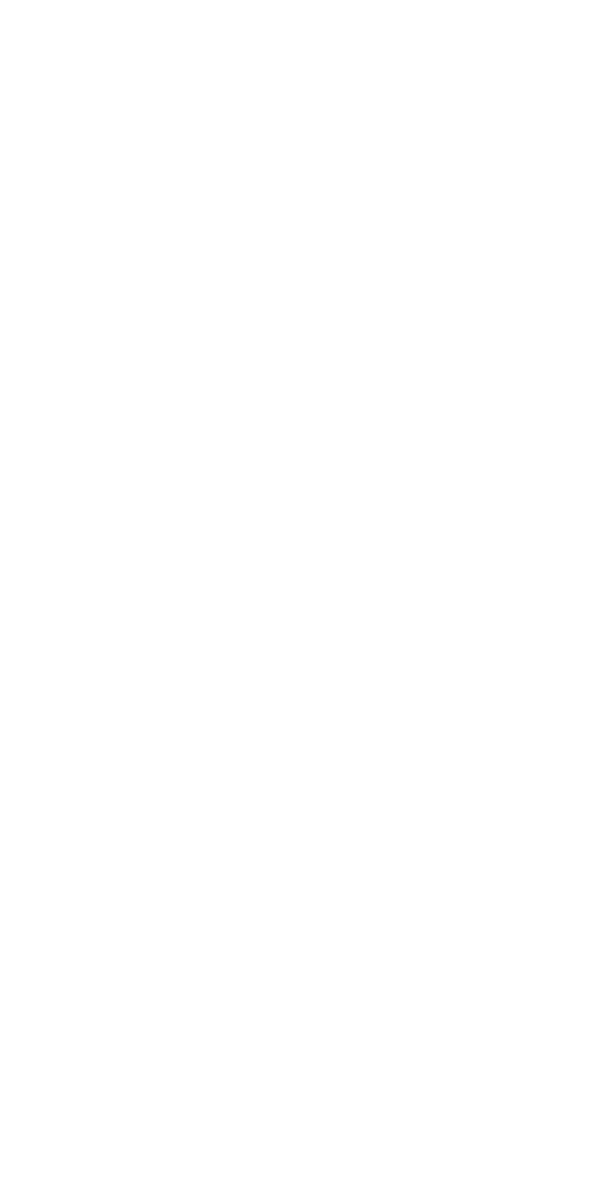

Cicejor


<IPython.core.display.Javascript object>


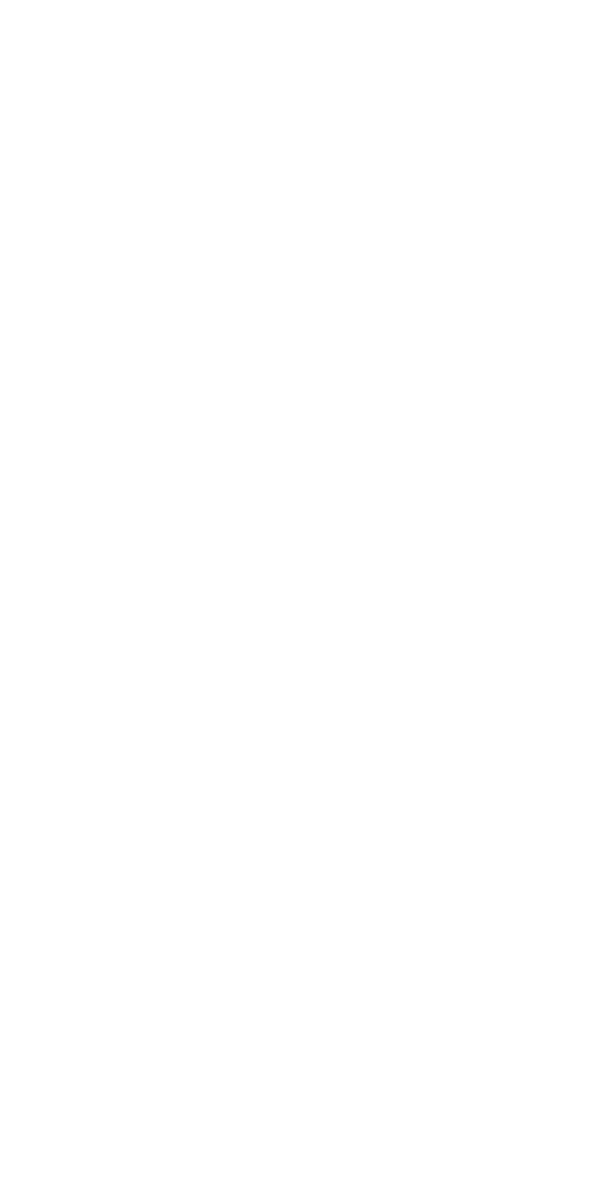

Erimor


<IPython.core.display.Javascript object>


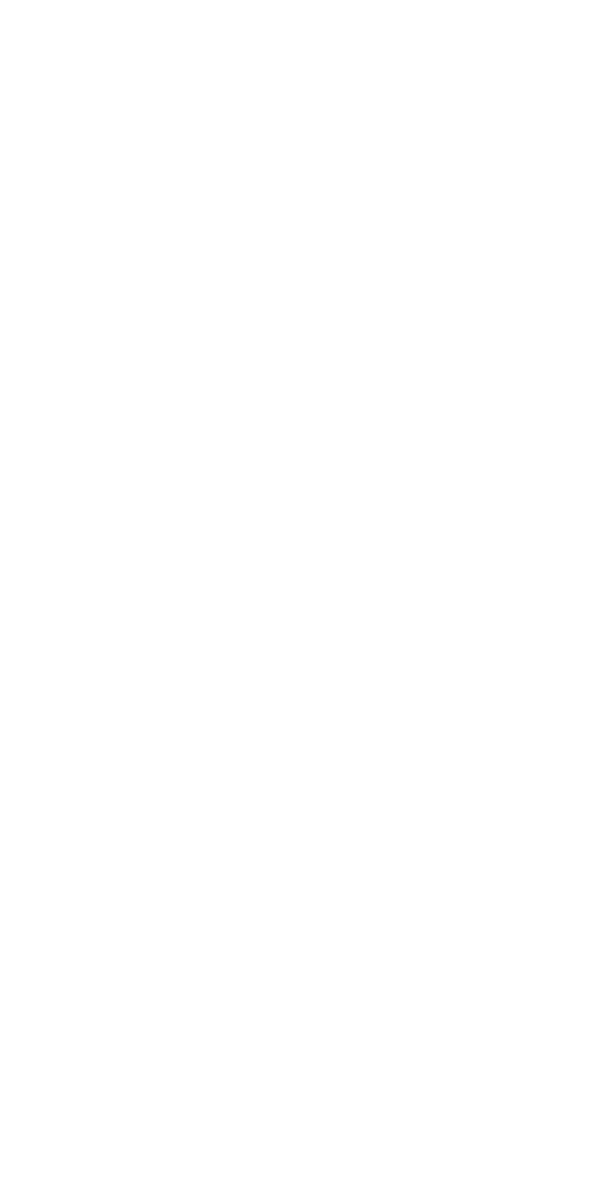

Ipayik


<IPython.core.display.Javascript object>


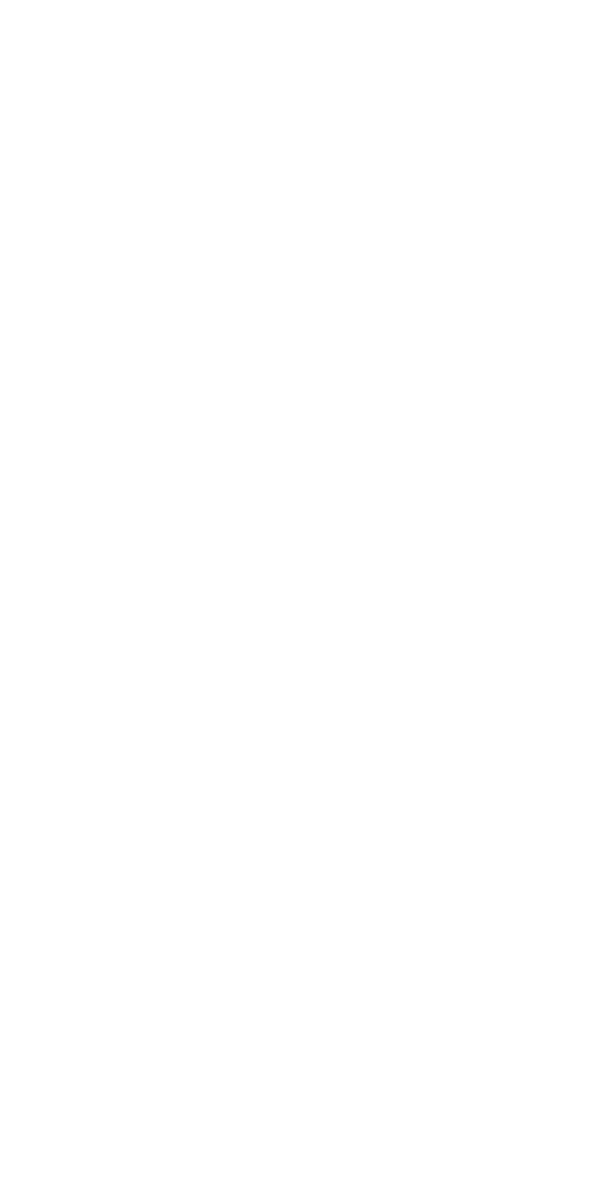

Ciphiscap


<IPython.core.display.Javascript object>


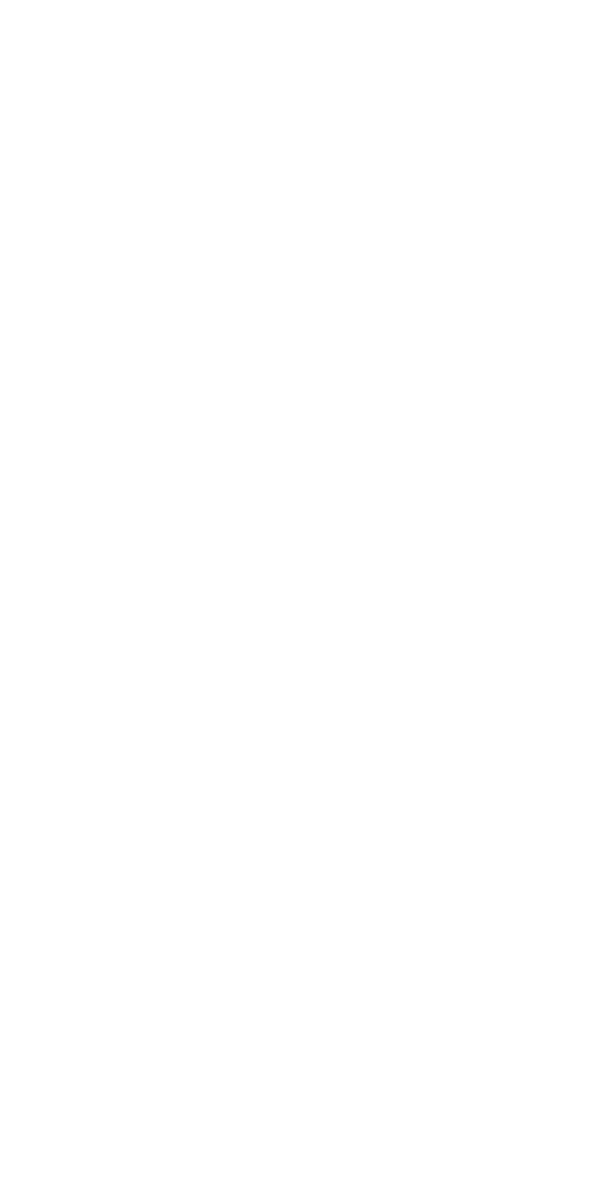

Efteram


<IPython.core.display.Javascript object>


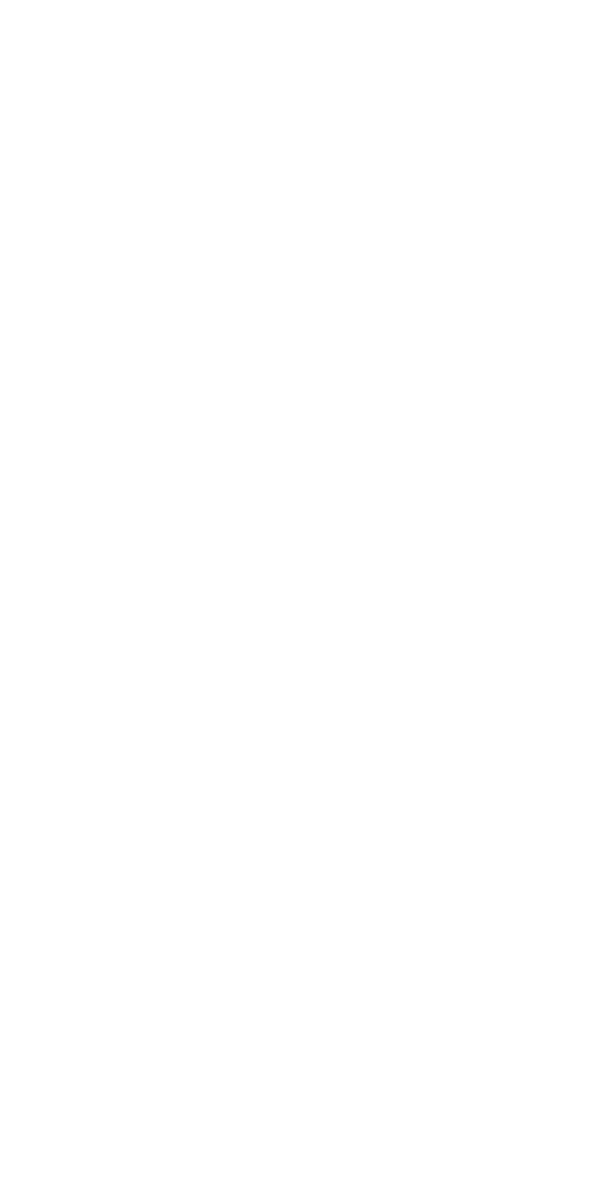

Esuckood


<IPython.core.display.Javascript object>


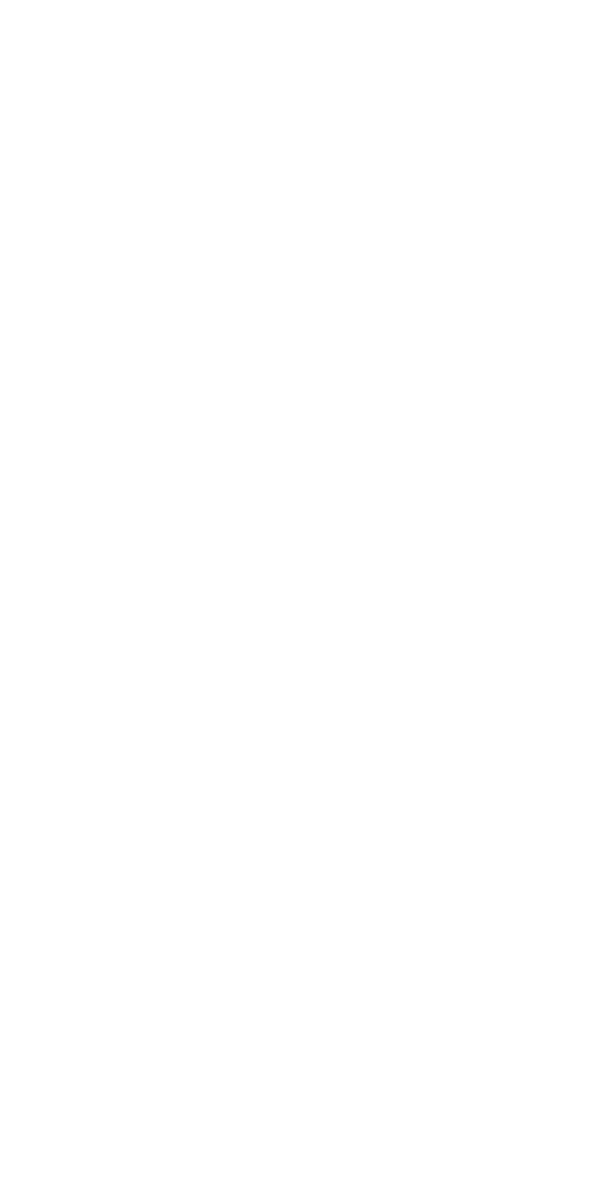

Togibi


<IPython.core.display.Javascript object>


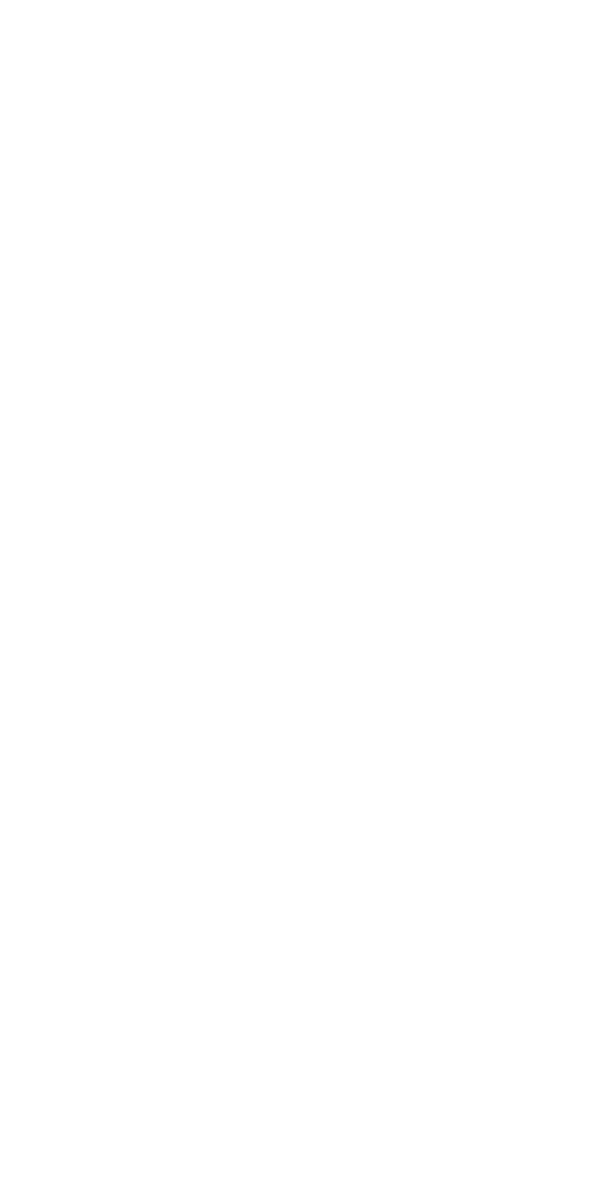

Lekieha


<IPython.core.display.Javascript object>


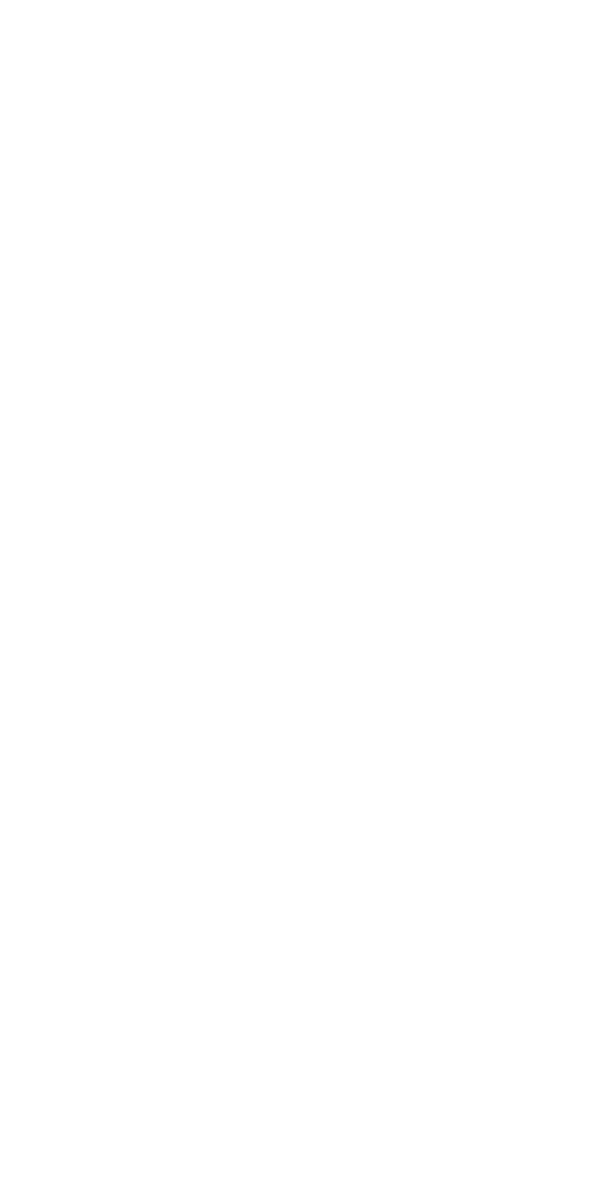

Cukoha


<IPython.core.display.Javascript object>


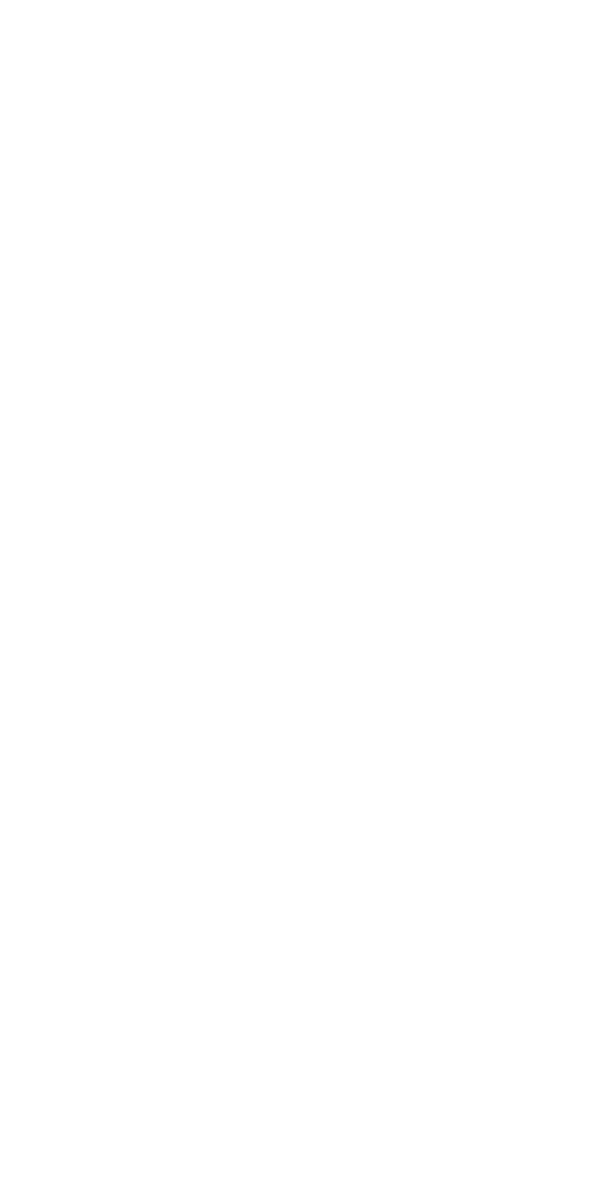

Pisceembok


<IPython.core.display.Javascript object>


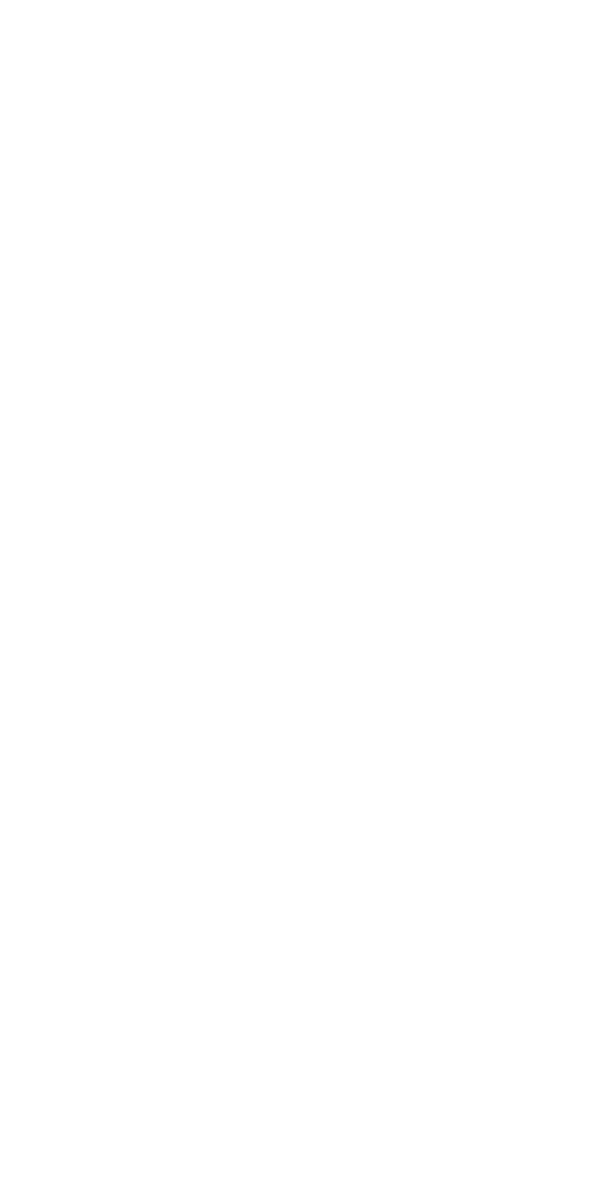

Refholfuest


<IPython.core.display.Javascript object>


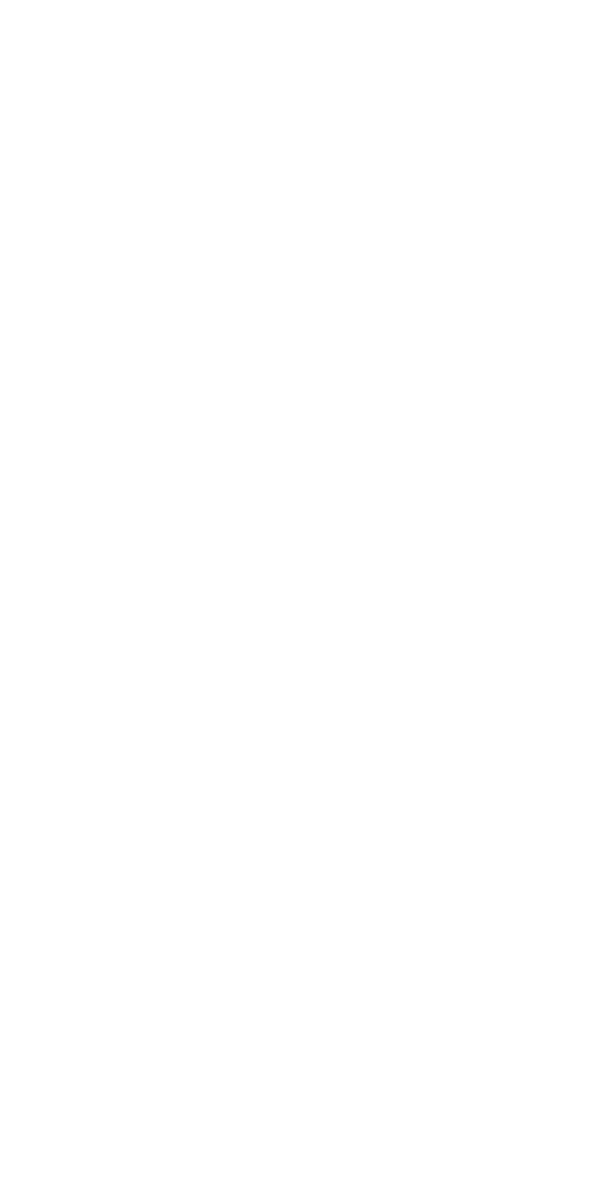

Quaseho


<IPython.core.display.Javascript object>


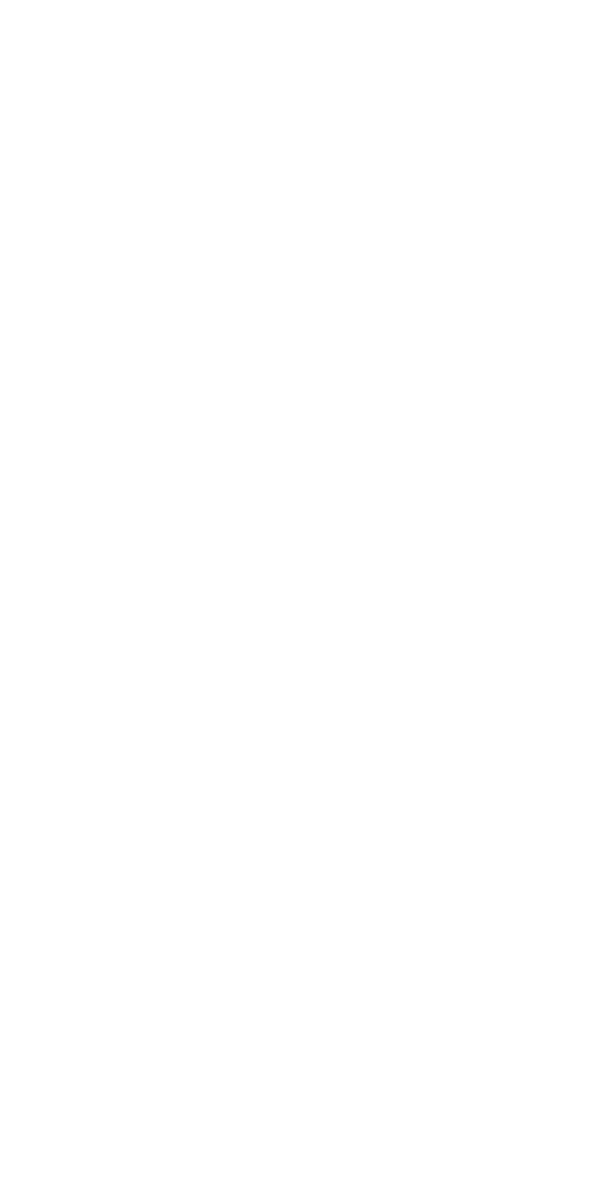

Vekeeyu


<IPython.core.display.Javascript object>


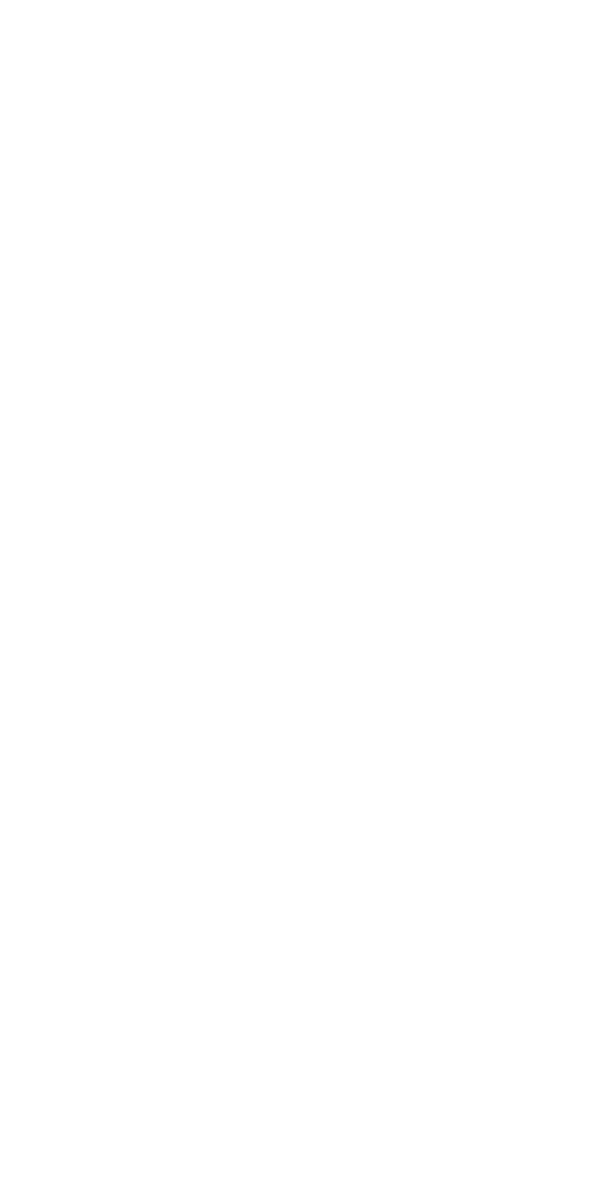

Nutuckith


<IPython.core.display.Javascript object>


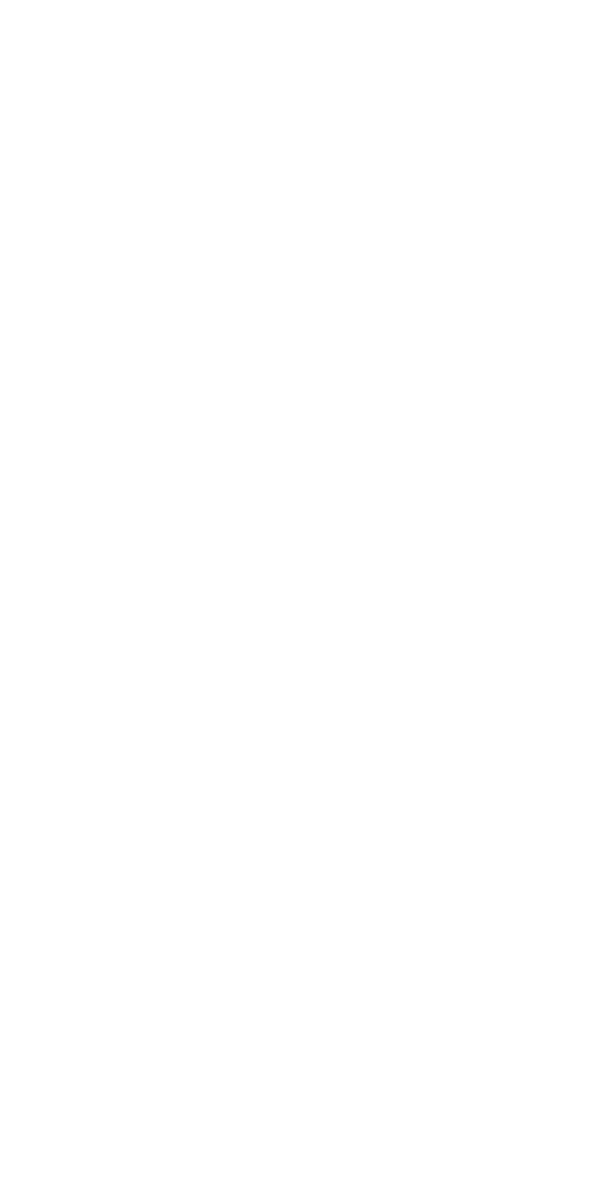

Scadornim


<IPython.core.display.Javascript object>


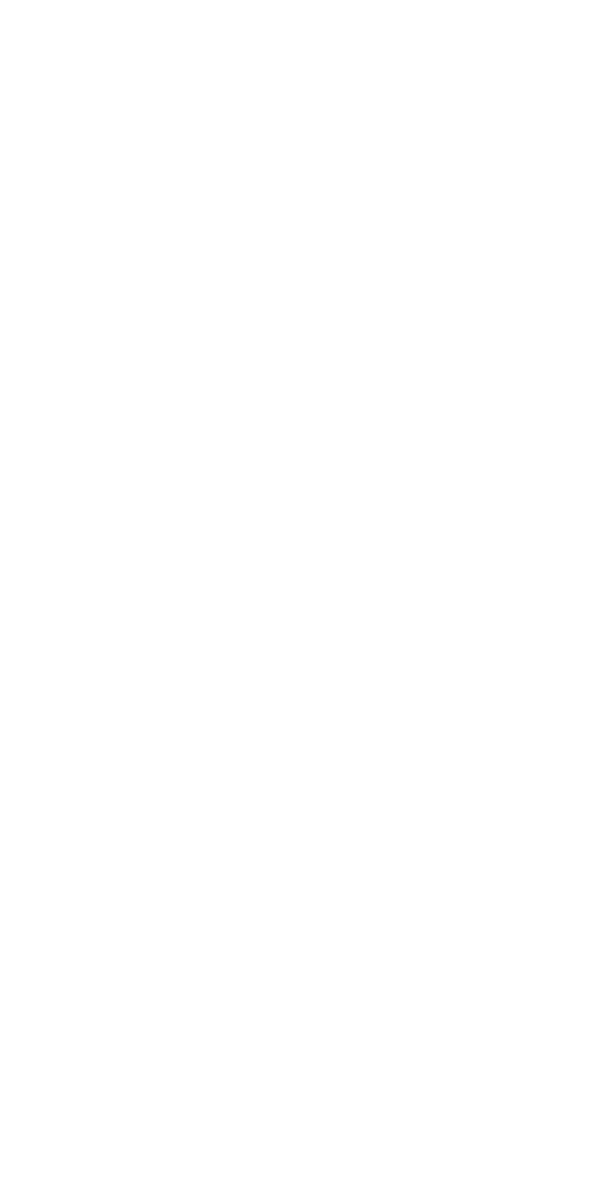

Nopigo


<IPython.core.display.Javascript object>


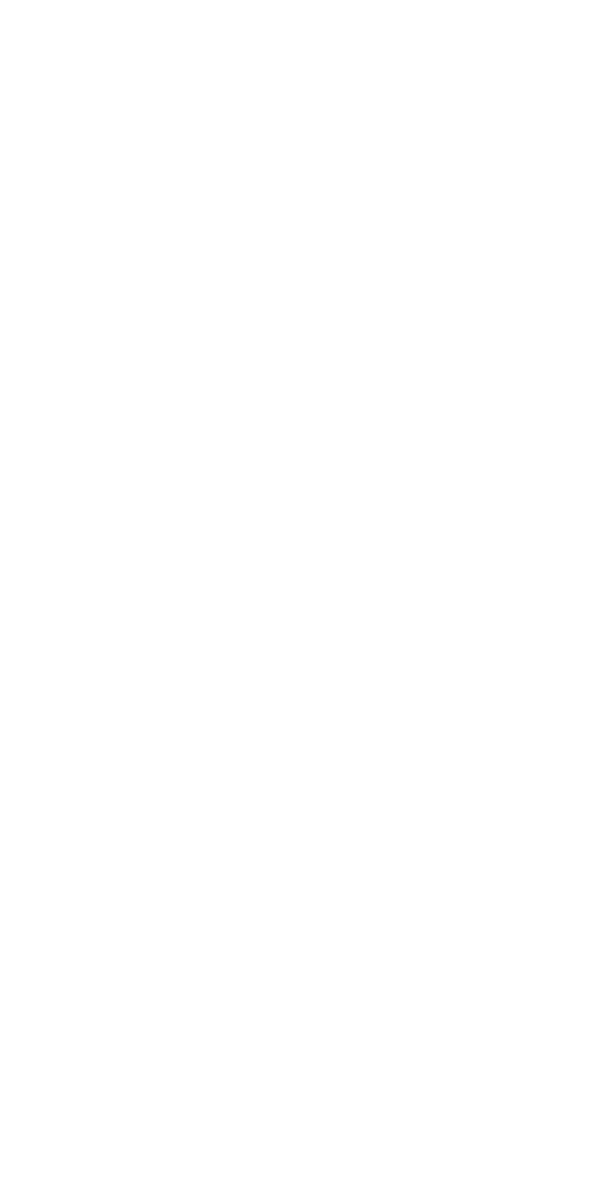

Gukietet


<IPython.core.display.Javascript object>


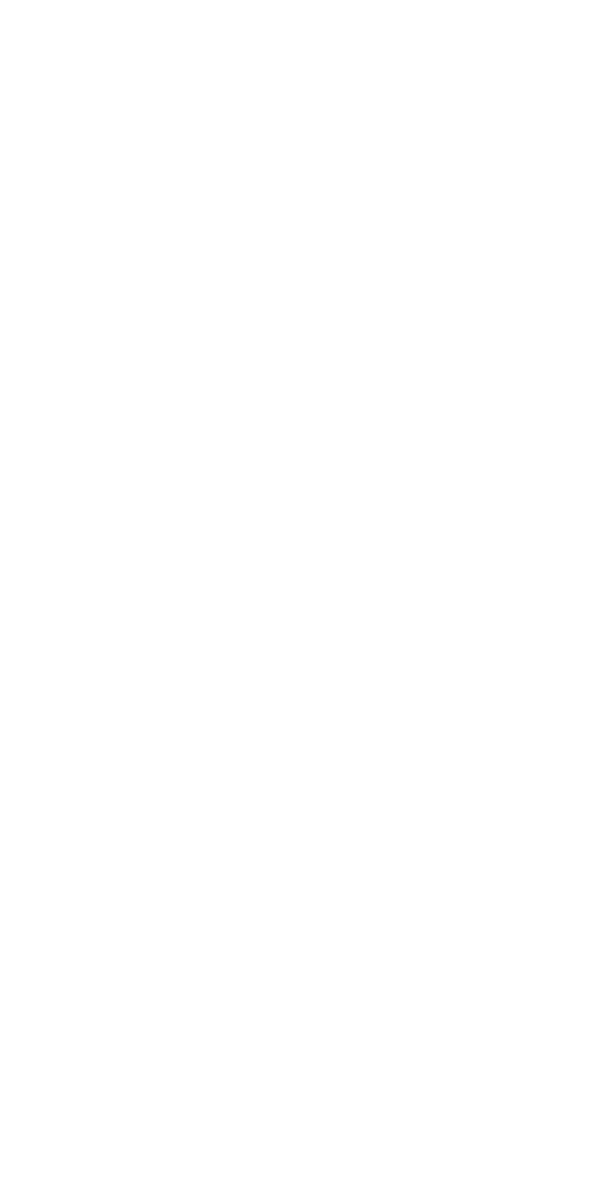

Vabriraf


<IPython.core.display.Javascript object>


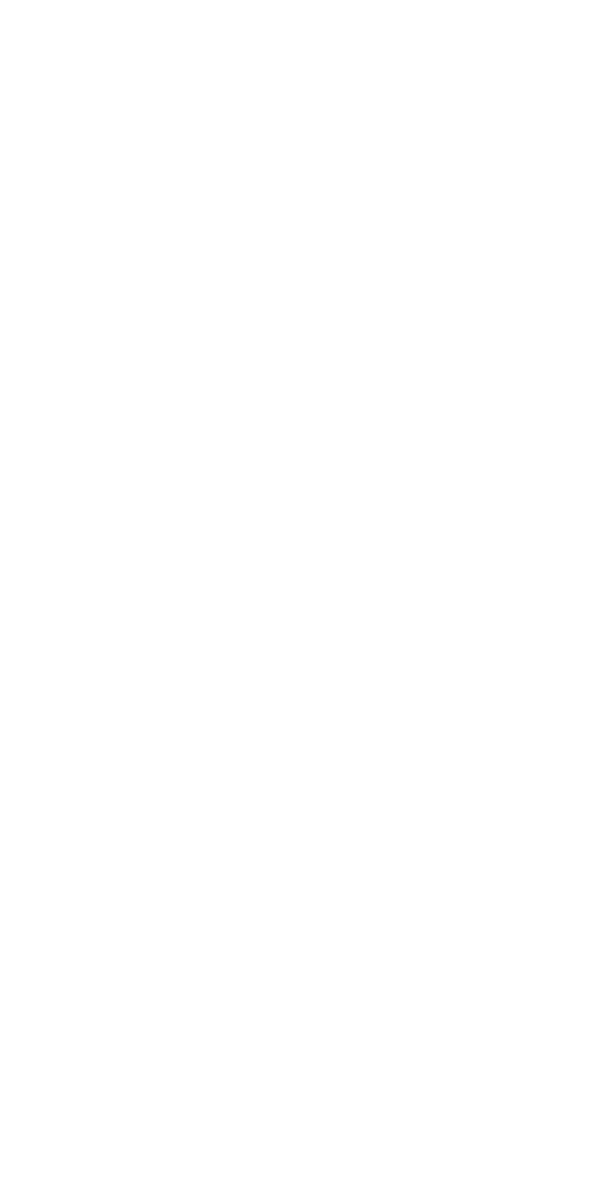

Gisadi


<IPython.core.display.Javascript object>


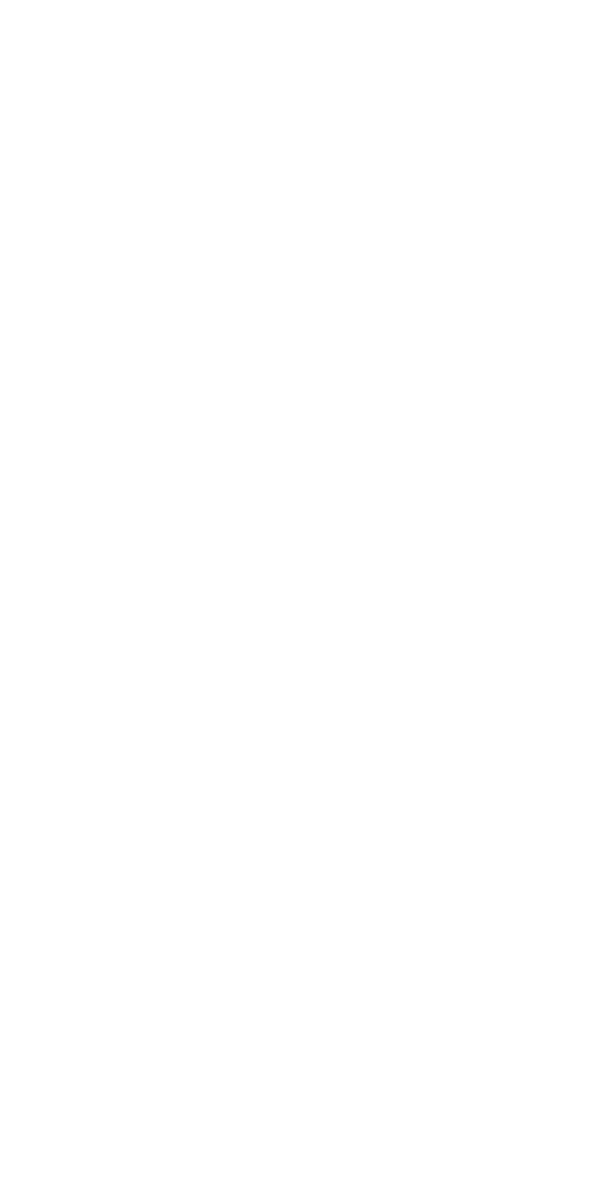

Sajaci


<IPython.core.display.Javascript object>


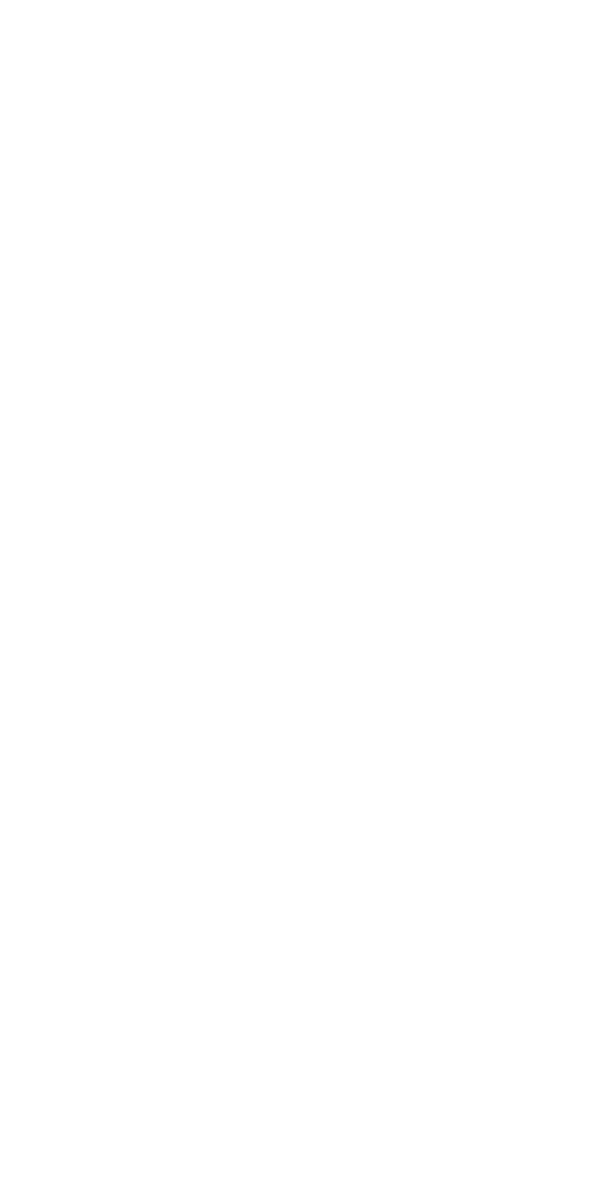

Fuchemi


<IPython.core.display.Javascript object>


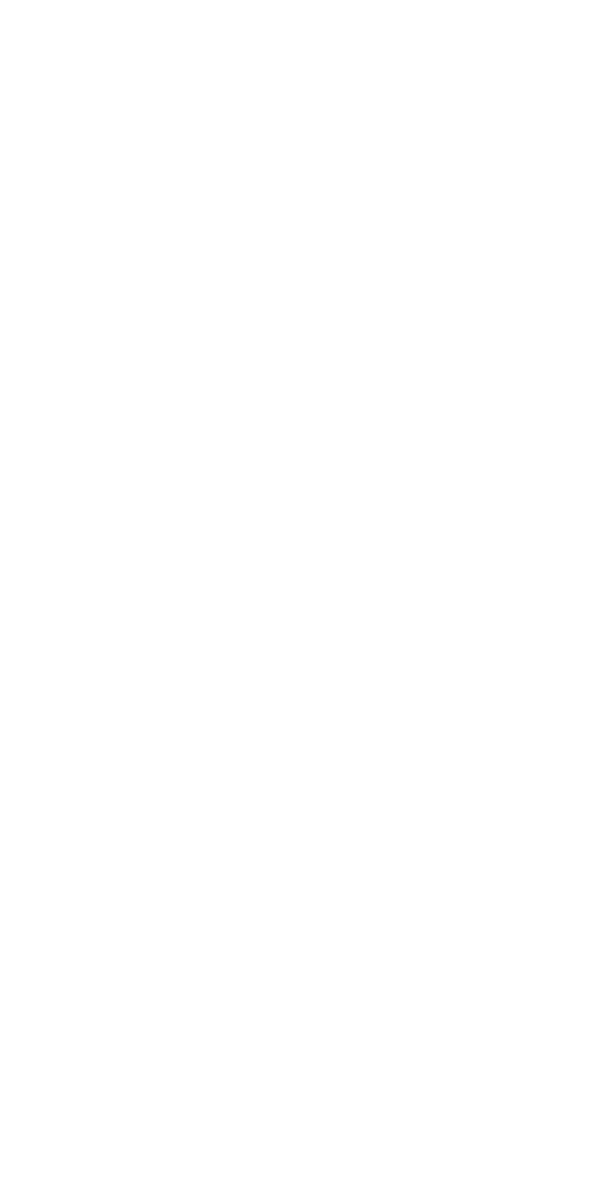

Hetupo


<IPython.core.display.Javascript object>


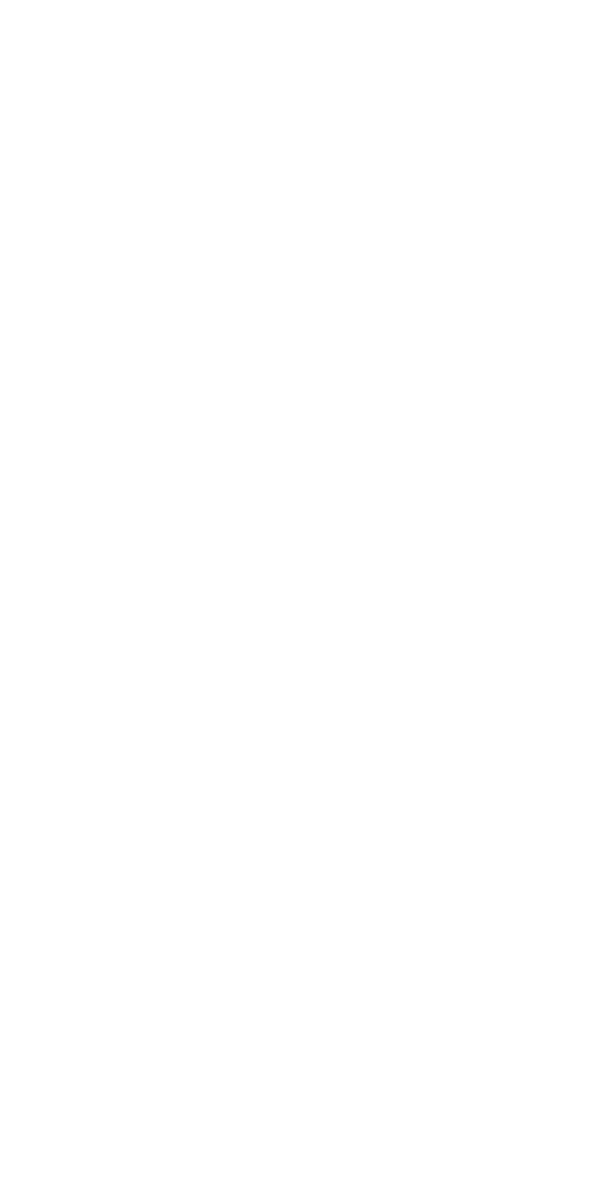

Tutife


<IPython.core.display.Javascript object>


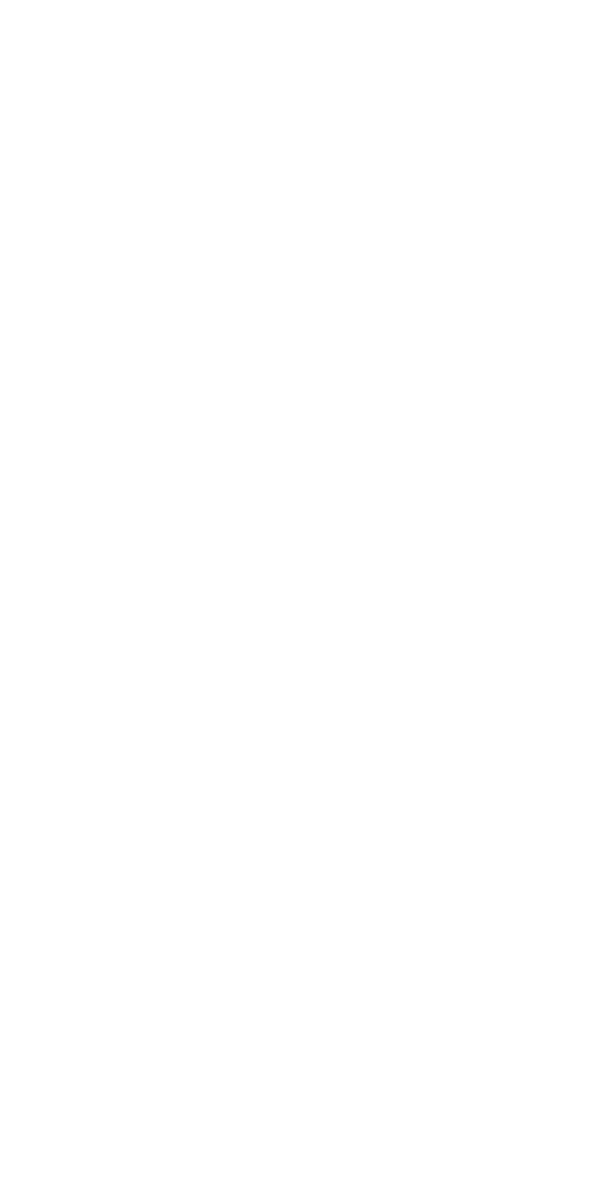

Vilehu


<IPython.core.display.Javascript object>


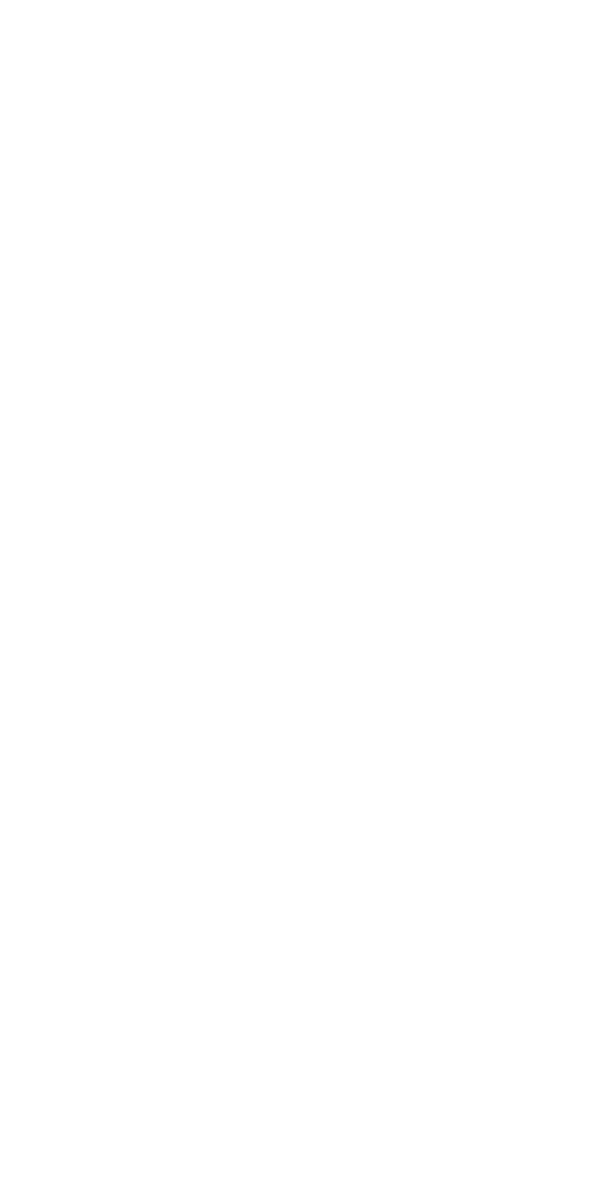

Moogbuley


<IPython.core.display.Javascript object>


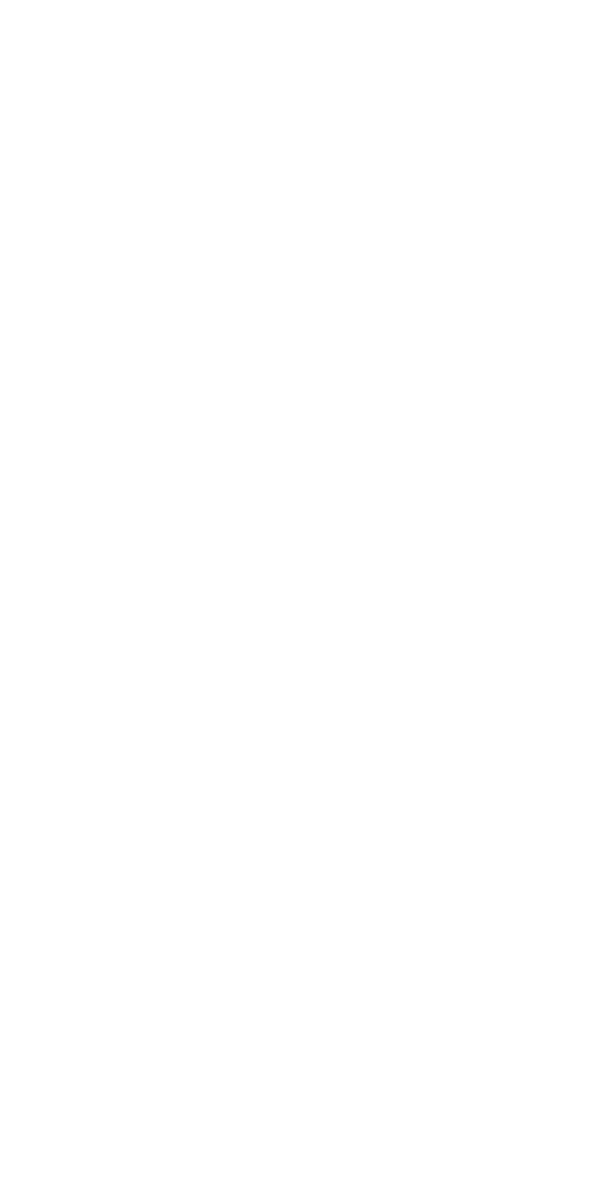

Niritha


<IPython.core.display.Javascript object>


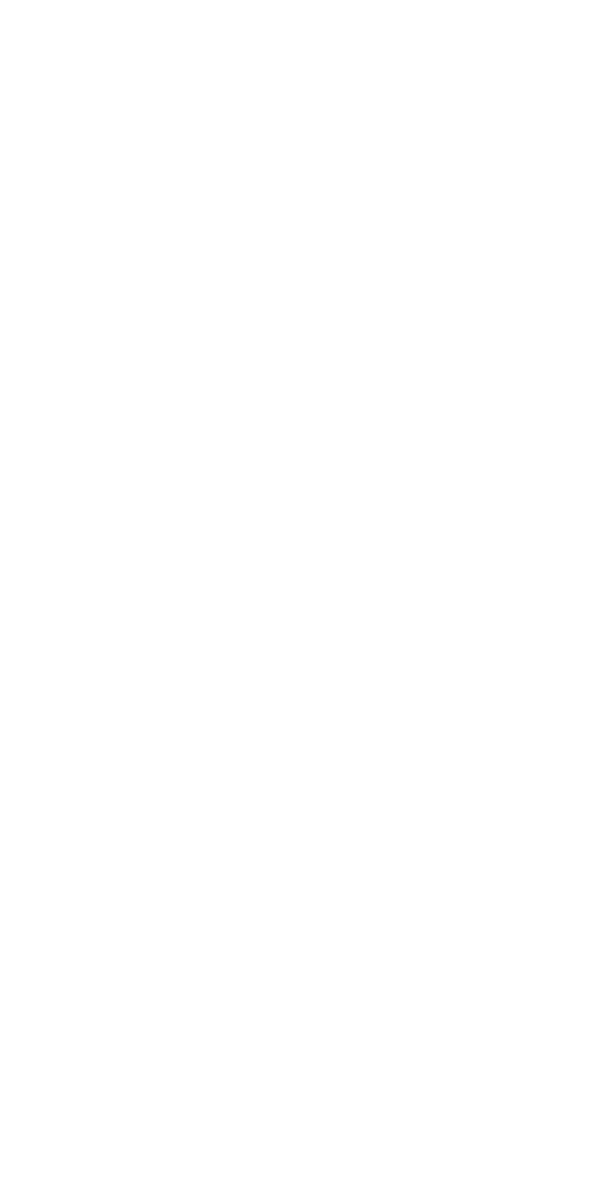

Nosatof


<IPython.core.display.Javascript object>


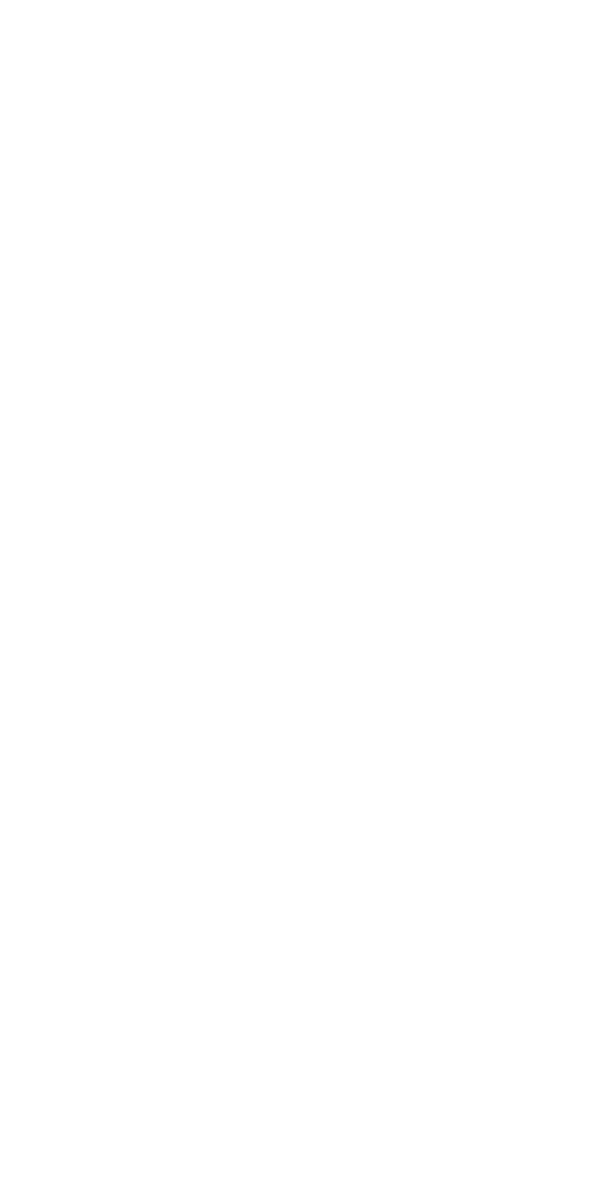

Jolanu


<IPython.core.display.Javascript object>


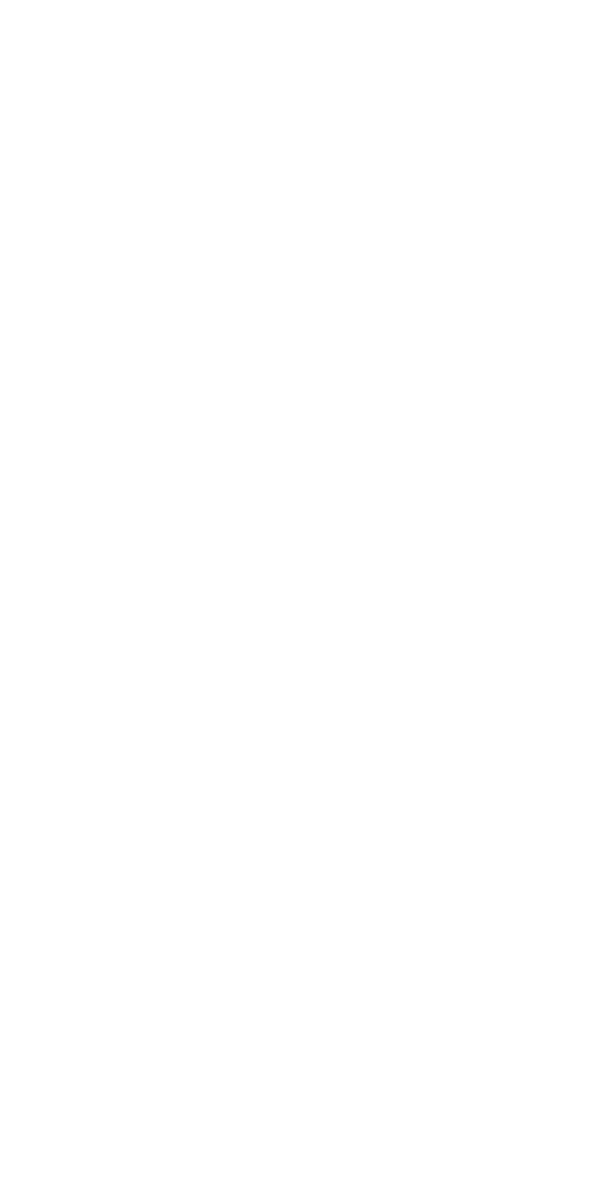

Jegohe


<IPython.core.display.Javascript object>


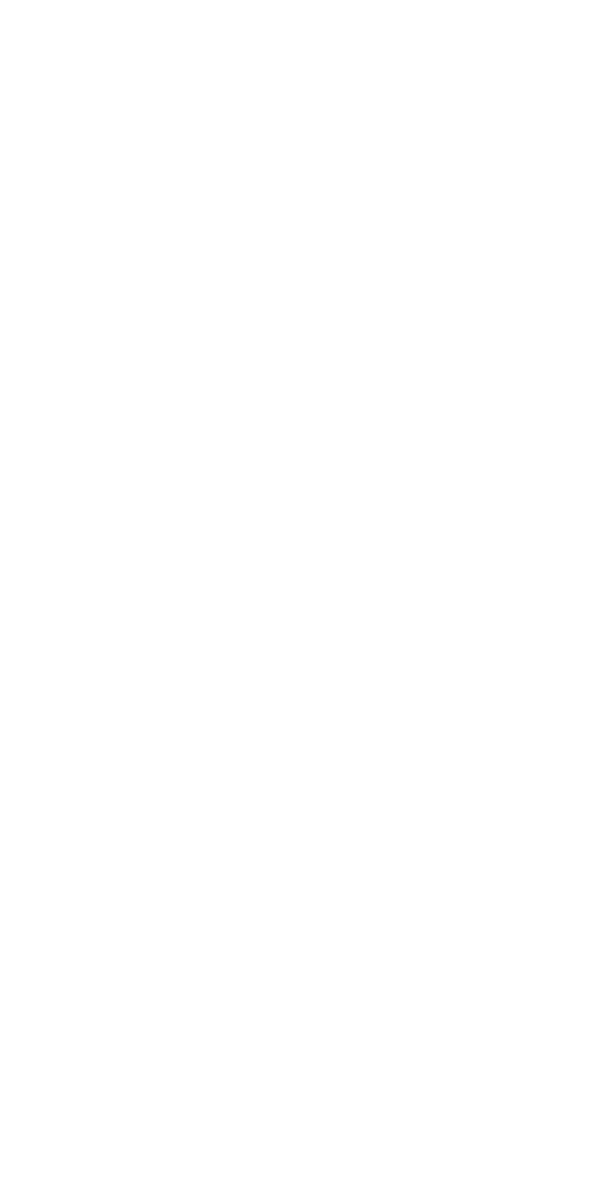

Braloosip


<IPython.core.display.Javascript object>


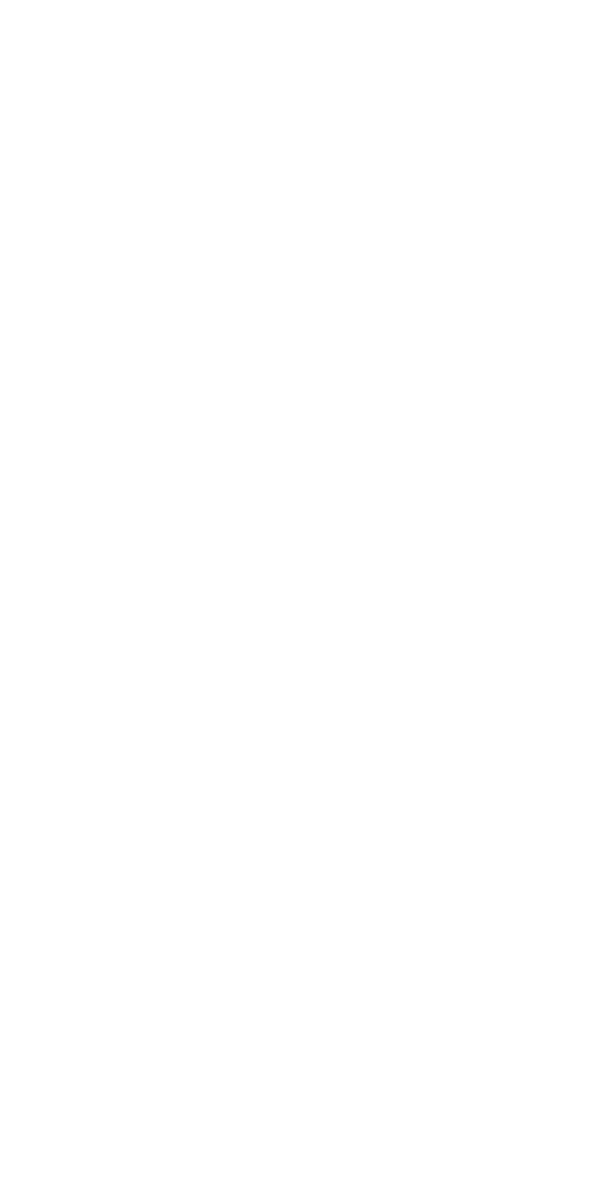

Slapeeme


<IPython.core.display.Javascript object>


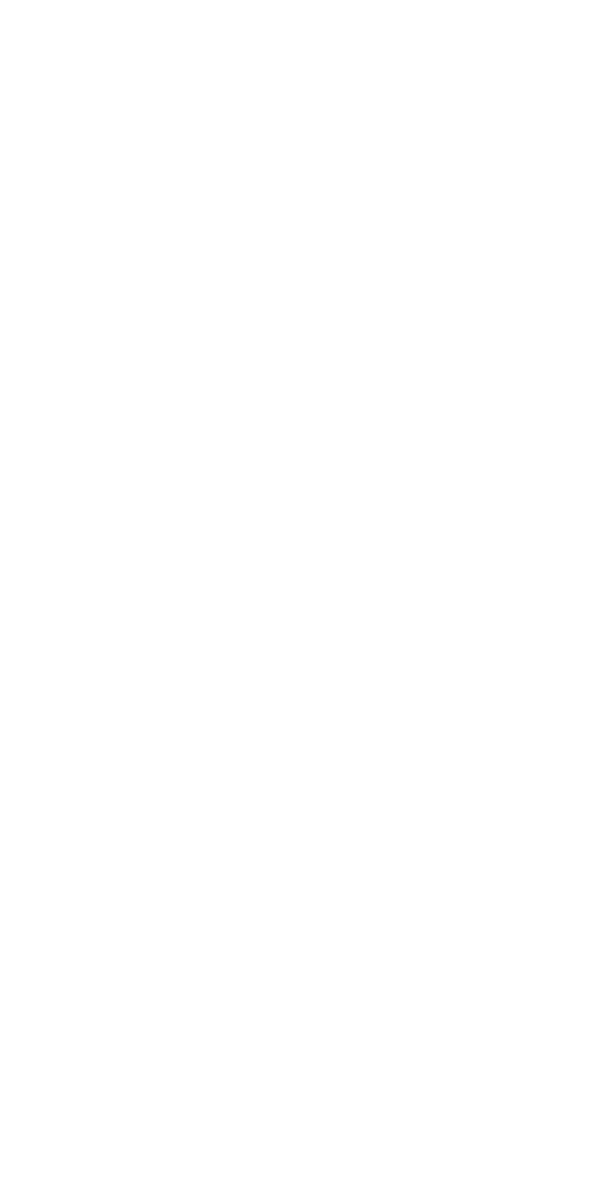

Mashoyal


<IPython.core.display.Javascript object>


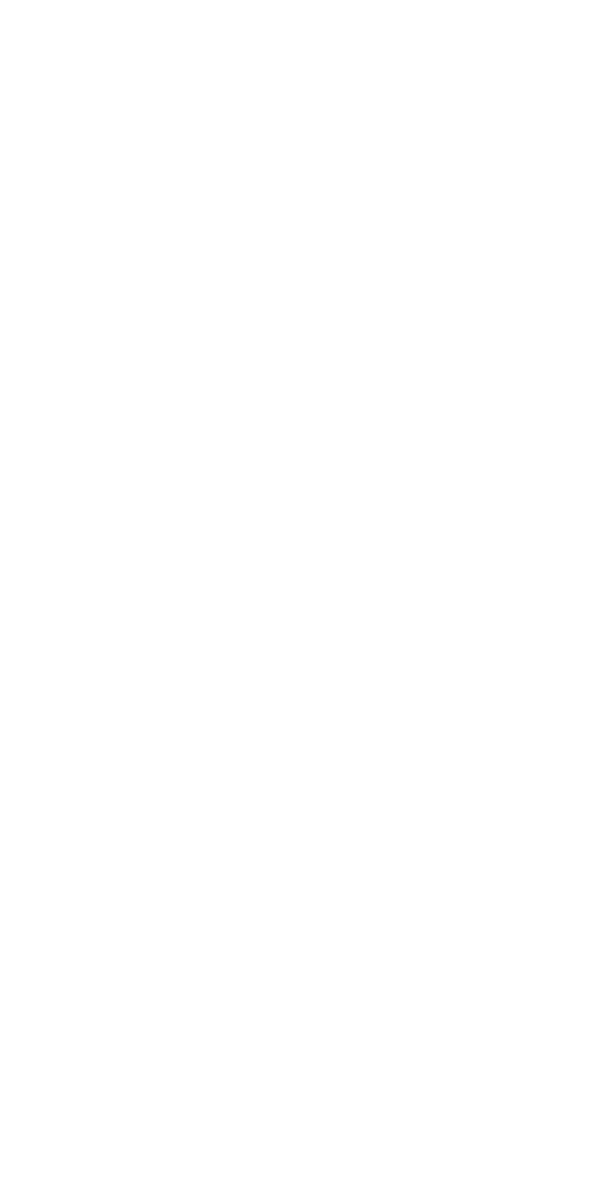

Dufehi


<IPython.core.display.Javascript object>


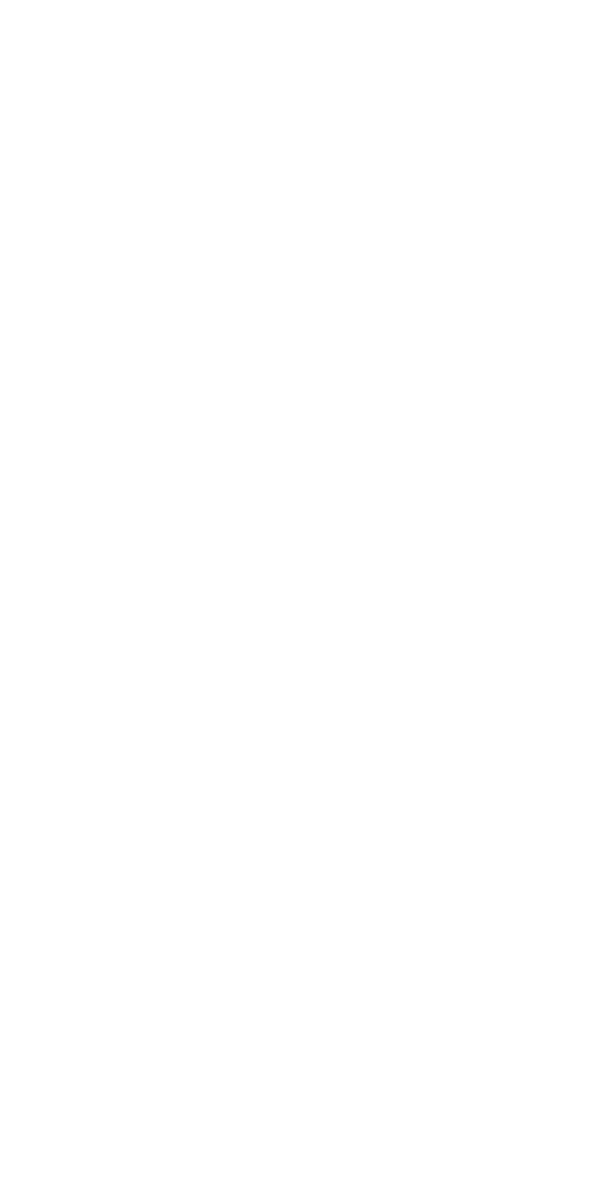

Dajiden


<IPython.core.display.Javascript object>


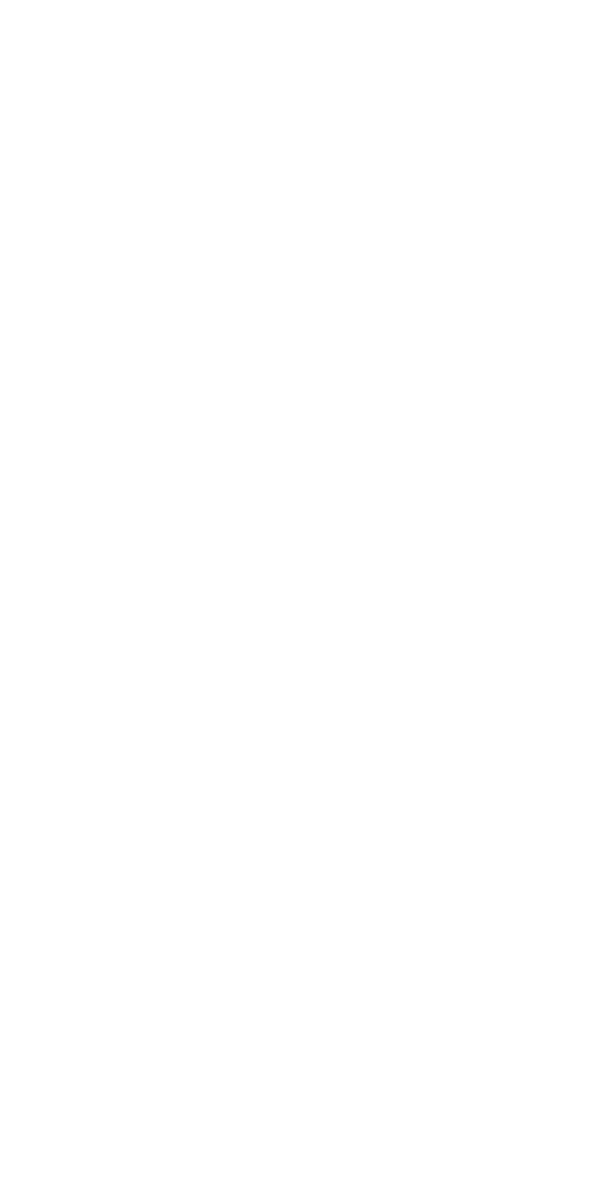

Darabos


<IPython.core.display.Javascript object>


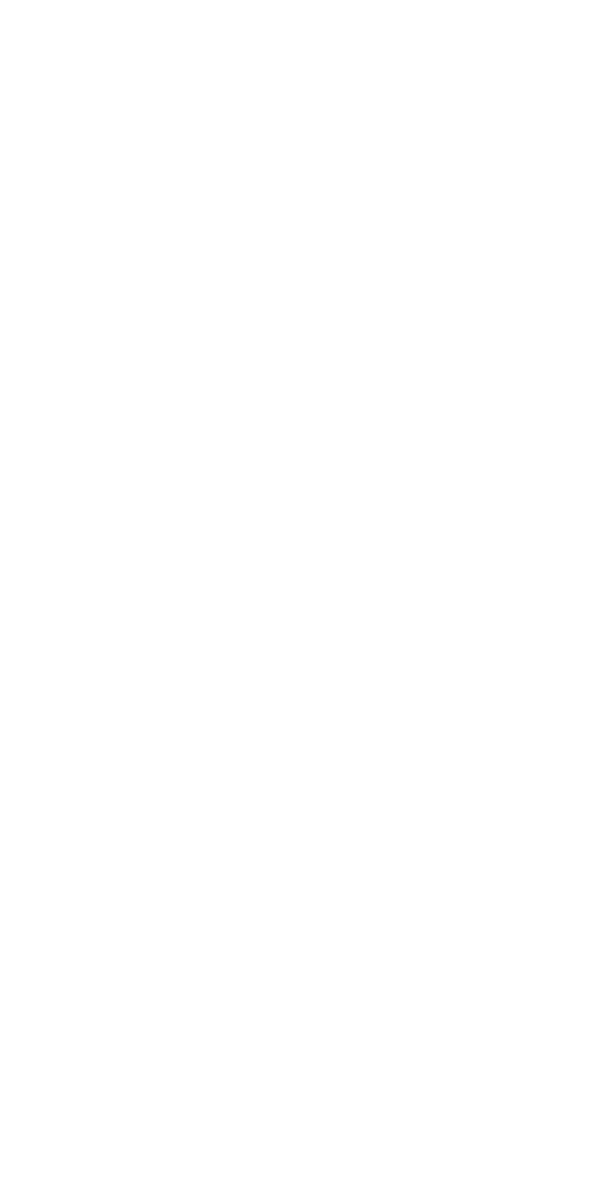

Narefod


<IPython.core.display.Javascript object>


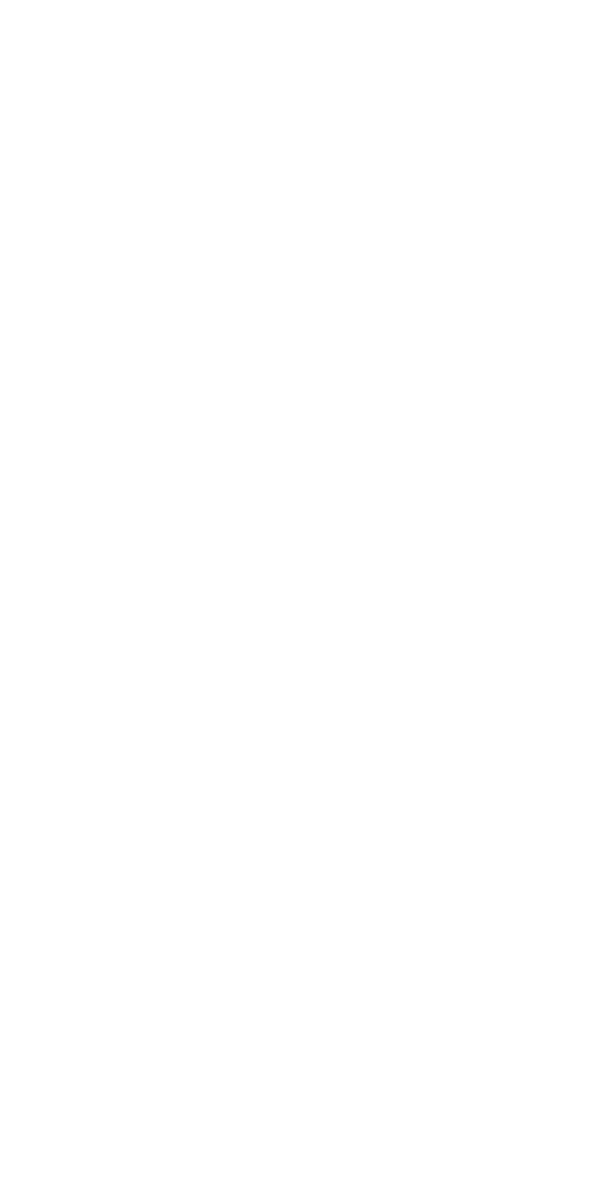

Litepoon


<IPython.core.display.Javascript object>


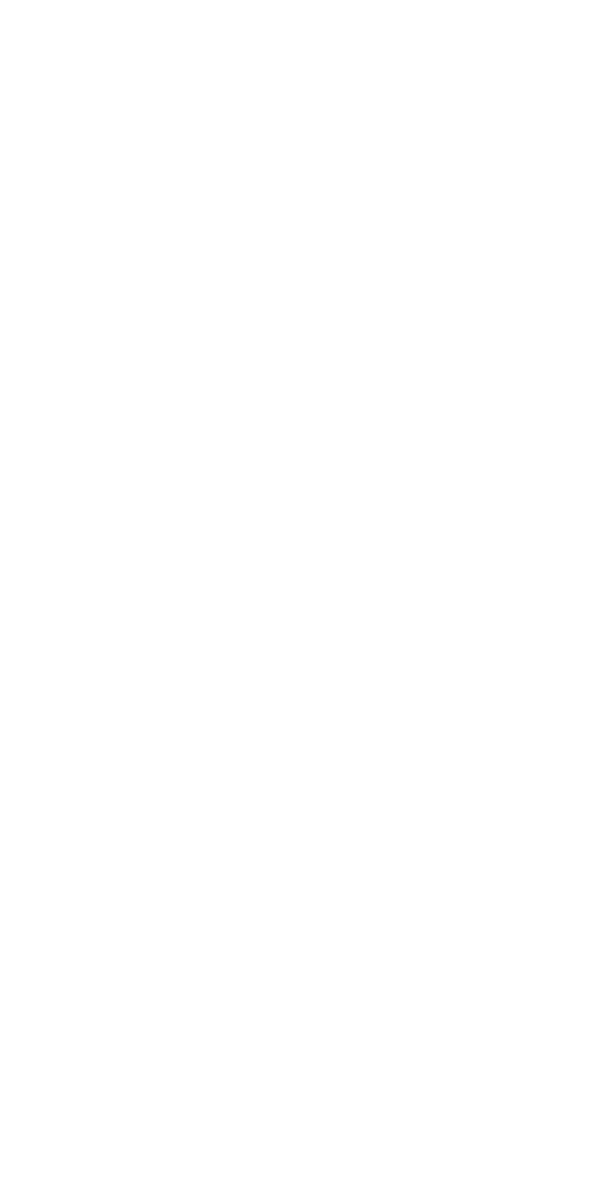

Vahapug


<IPython.core.display.Javascript object>


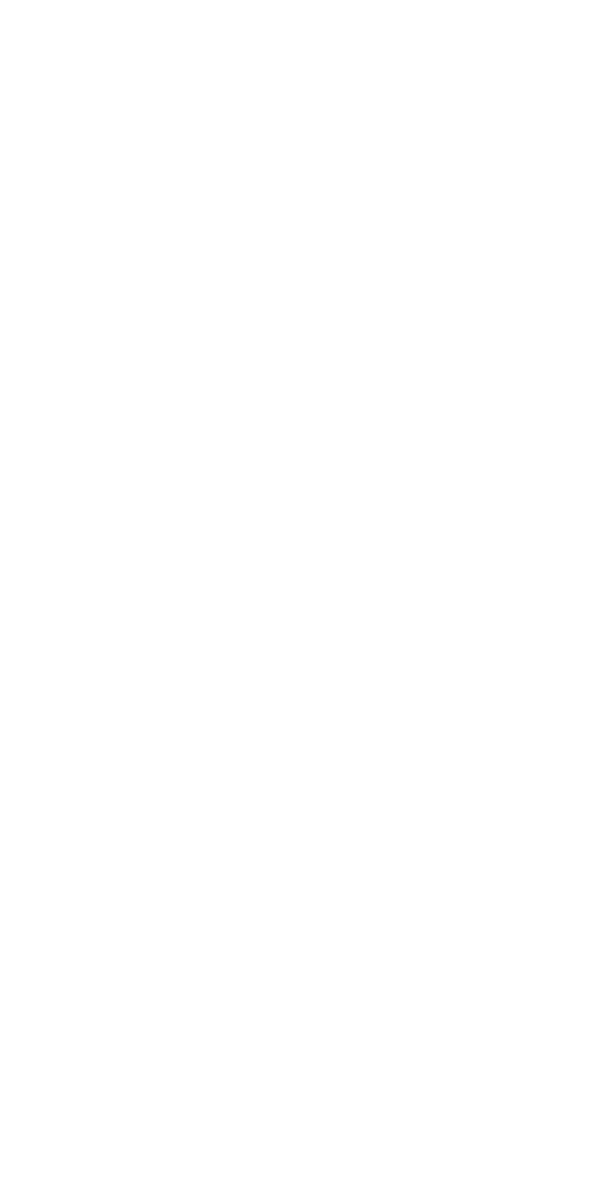

Gupimug


<IPython.core.display.Javascript object>


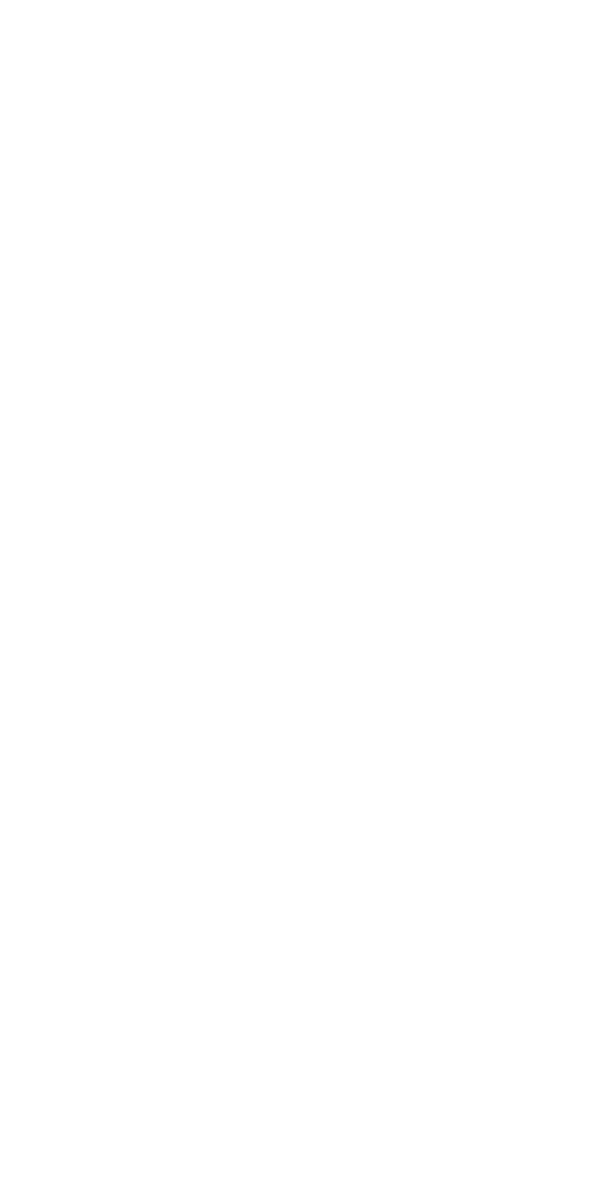

Kalowee


<IPython.core.display.Javascript object>


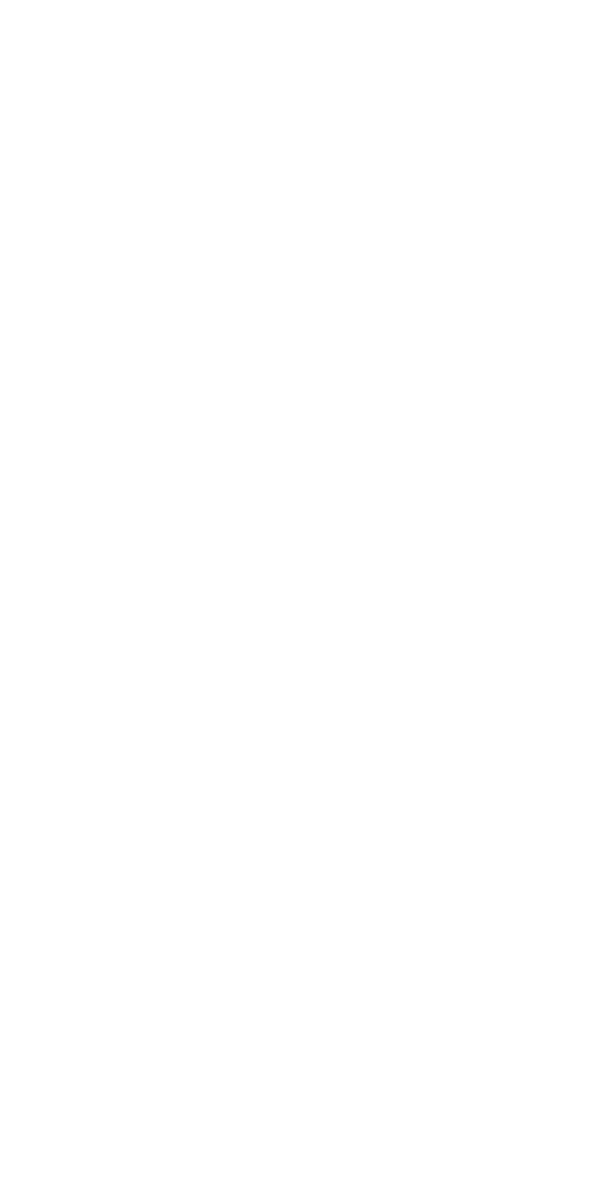

Daqueba


<IPython.core.display.Javascript object>


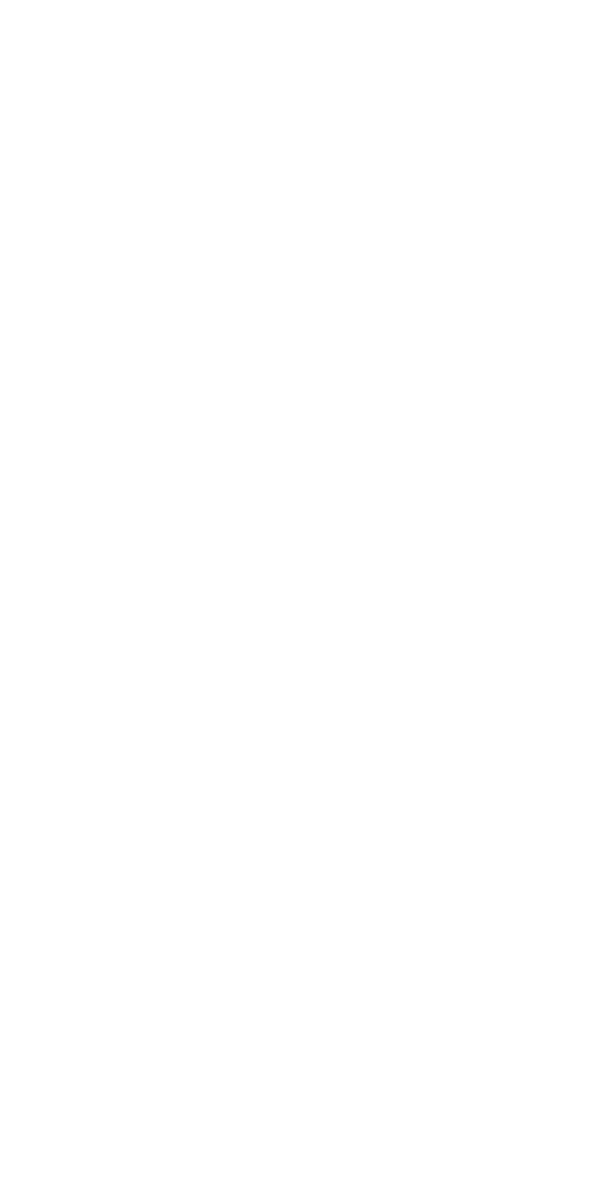

Pekafe


<IPython.core.display.Javascript object>


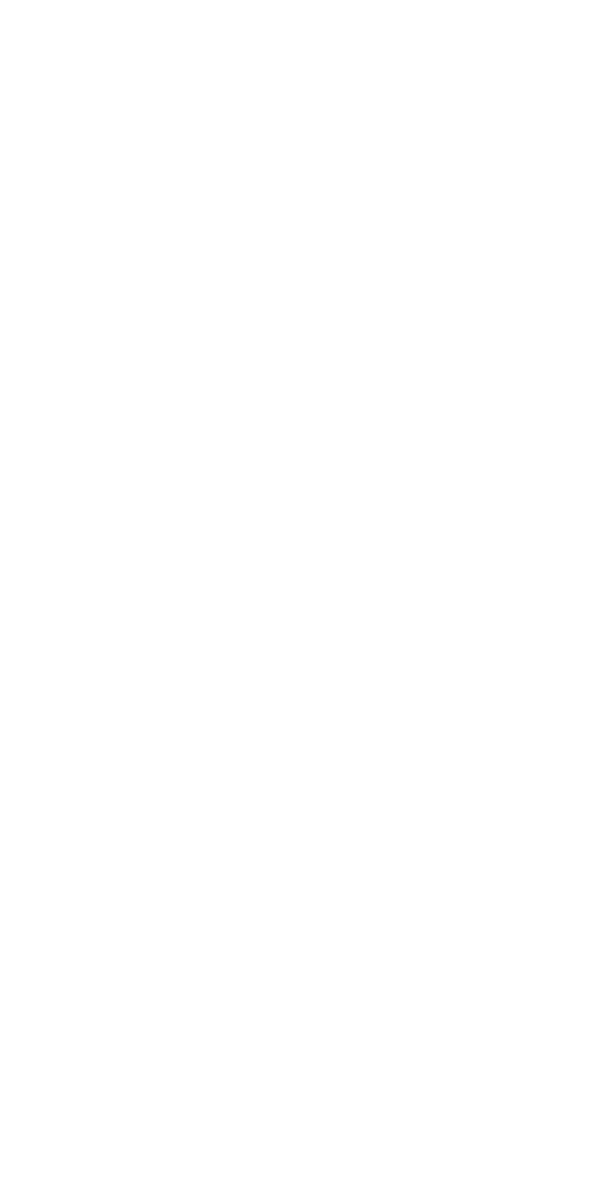

In [11]:
""" SAVE RESULTS TO HDF5 """
try:
    os.remove('/home/ubuntu/Cardiac-ECC/{}_raw_predictions.hdf5'.format(ORGAN, ORGAN))
except:
    pass
results = h5py.File('/home/ubuntu/Cardiac-ECC/{}_raw_predictions.hdf5'.format(ORGAN, ORGAN), 'w')

QC_DIR = '/home/ubuntu/Cardiac-ECC/CNN_QC/'

sidx = 32
T = 20
pidcount = 0
tidx = 0
for idx in np.arange(tidx, len(test_labels), T):
    currpid = allpids[pidcount]
    print(currpid)
    plt.figure(figsize=(6,12))
    regressed = np.array(test_vol_arr[idx,...]).astype(np.float32)
    """ DO NOT COMPRESS TO PERMIT MULTIPROCESSING """
    temparr = np.array(test_vol_arr[idx:idx+T,...]).astype(np.float32)
    """ Need to re-arrange order of axes """
    temparr = np.swapaxes(temparr, 0, 1)
    temparr = np.swapaxes(temparr, 1, 2)
    temparr = np.swapaxes(temparr, 2, 3)
    results.create_dataset(currpid, data=temparr, dtype=np.float32)
    temparr = []
    manfit = np.array(test_labels_arr[idx,...]).astype(np.float32)
    uncorrected = np.array(test_images_arr[idx,...]).astype(np.float32)
    V = 0.05
    # Plot regressed first, then manual
    ax1 = plt.subplot(631)
    ax1.imshow(regressed[:,:,sidx,0], cmap='jet', vmin=-V, vmax=V)
    ax1.axis('off')
    ax1.set_title('CNN Vx')
    
    ax2 = plt.subplot(632)
    ax2.imshow(regressed[:,:,sidx,1], cmap='jet', vmin=-V, vmax=V)
    ax2.axis('off')
    ax2.set_title('CNN Vy')
    
    ax3 = plt.subplot(633)
    ax3.imshow(regressed[:,:,sidx,2], cmap='jet', vmin=-V, vmax=V)
    ax3.axis('off')
    ax3.set_title('CNN Vz')
    
    ax4 = plt.subplot(634)
    ax4.imshow(manfit[:,:,sidx,0], cmap='jet', vmin=-V, vmax=V)
    ax4.axis('off')
    ax4.set_title('Man. Fit Vx')
    
    ax5 = plt.subplot(635)
    ax5.imshow(manfit[:,:,sidx,1], cmap='jet', vmin=-V, vmax=V)
    ax5.axis('off')
    ax5.set_title('Man. Fit Vy')
    
    ax6 = plt.subplot(636)
    ax6.imshow(manfit[:,:,sidx,2], cmap='jet', vmin=-V, vmax=V)
    ax6.axis('off')
    ax6.set_title('Man. Fit Vz')
    
    # Now plot what the components looks like post correction
    # Plot regressed first, then manual
    V = 0.05
    ax7 = plt.subplot(637)
    ax7.imshow(uncorrected[:,:,sidx,1] + regressed[:,:,sidx,0], cmap='bwr', vmin=-V, vmax=V)
    ax7.axis('off')
    ax7.set_title('CNN Corr. Vx')
    
    ax8 = plt.subplot(638)
    ax8.imshow(uncorrected[:,:,sidx,2] + regressed[:,:,sidx,1], cmap='bwr', vmin=-V, vmax=V)
    ax8.axis('off')
    ax8.set_title('CNN Corr. Vy')
    
    ax9 = plt.subplot(639)
    ax9.imshow(uncorrected[:,:,sidx,3] + regressed[:,:,sidx,2], cmap='bwr', vmin=-V, vmax=V)
    ax9.axis('off')
    ax9.set_title('CNN Corr. Vz')
    
    ax10 = plt.subplot(6,3,10)
    ax10.imshow(uncorrected[:,:,sidx,1] + manfit[:,:,sidx,0], cmap='bwr', vmin=-V, vmax=V)
    ax10.axis('off')
    ax10.set_title('Man. Corr. Vx')
    
    ax11 = plt.subplot(6,3,11)
    ax11.imshow(uncorrected[:,:,sidx,2] + manfit[:,:,sidx,1], cmap='bwr', vmin=-V, vmax=V)
    ax11.axis('off')
    ax11.set_title('Man. Corr. Vy')
    
    ax12 = plt.subplot(6,3,12)
    ax12.imshow(uncorrected[:,:,sidx,3] + manfit[:,:,sidx,2], cmap='bwr', vmin=-V, vmax=V)
    ax12.axis('off')
    ax12.set_title('Man. Corr. Vz')
    
    ax13 = plt.subplot(6,3,13)
    ax13.imshow(uncorrected[:,:,sidx,1], cmap='bwr', vmin=-V, vmax=V)
    ax13.axis('off')
    ax13.set_title('Uncorr. Vx')
    
    ax14 = plt.subplot(6,3,14)
    ax14.imshow(uncorrected[:,:,sidx,2], cmap='bwr', vmin=-V, vmax=V)
    ax14.axis('off')
    ax14.set_title('Uncorr. Vy')

    ax15 = plt.subplot(6,3,15)
    ax15.imshow(uncorrected[:,:,sidx,3], cmap='bwr', vmin=-V, vmax=V)
    ax15.axis('off')
    ax15.set_title('Uncorr. Vz')
    
    ax16 = plt.subplot(6,3,16)
    ax16.imshow(uncorrected[:,:,sidx,0], cmap='gray', vmin=0, vmax=1)
    ax16.axis('off')
    ax16.set_title('Mag')
    
    mask = np.ones((uncorrected[:,:,sidx,0]).shape)
    # Written to mimic how thresholding is done upstream
    coords = np.ravel(uncorrected[:,:,sidx,0])
    mask = np.ravel(mask)
    low = np.argwhere(coords <= THRESH)
    mask[low] = -1
    mask = np.reshape(mask, (64,64))

    ax17 = plt.subplot(6,3,17)
    ax17.imshow(mask, cmap='gray', vmin=-1, vmax=1)
    ax17.axis('off')
    ax17.set_title('Mask')
    
    masked = mask * uncorrected[:,:,sidx,0]
    # Written to mimic how thresholding is done upstream
    flatmasked = np.ravel(masked)
    big = np.argwhere(flatmasked < 0)
    flatmasked[big] = -1
    flatmasked = np.reshape(flatmasked, (64,64))
    
    ax18 = plt.subplot(6,3,18)
    ax18.imshow(flatmasked, cmap='bwr', vmin=-1, vmax=1)
    ax18.axis('off')
    ax18.set_title('Used Pixels')
    pidcount += 1
    
    plt.tight_layout()
    plt.savefig(QC_DIR + currpid + '{}pct_thresh_slice{}_time{}_testset.png'.format(int(THRESH*100), sidx, tidx))
    plt.close()
results.close()

In [14]:
data.close()

In [15]:
%reset -f